# FL branch Validation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELLPOSE ENVIRONMENT
Cellpose version : 4.2.1.1
PyTorch version  : 2.11.0+cu128
CUDA available   : True
GPU              : Tesla T4
GPU capability   : (7, 5)
Use bfloat16     : False

DNA1 INPUT
Shape        : (6000, 6000)
dtype        : uint16
Range        : 0 to 65535
Median       : 14529.0
SHA-256      : 1eeea6e04da1143f0ac63eab28432729497a9080fecde3a2e2c3309d14ff7800
Source       : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/TONSIL-1_40X_Field_01_01.tif

Loading the deliberately selected existing mask...

CELLPOSE SEGMENTATION RESULT
Run status             : deliberately reused
Mask shape             : (6000, 6000)
Label dtype            : int32
Segmented cells        : 61,173
Maximum label          : 61,173
Labels contiguous      : True
Foreground coverage    : 52.59%
Median cell area       : 296.0 px
Cell-area 5th–95th pct : 134.0 t

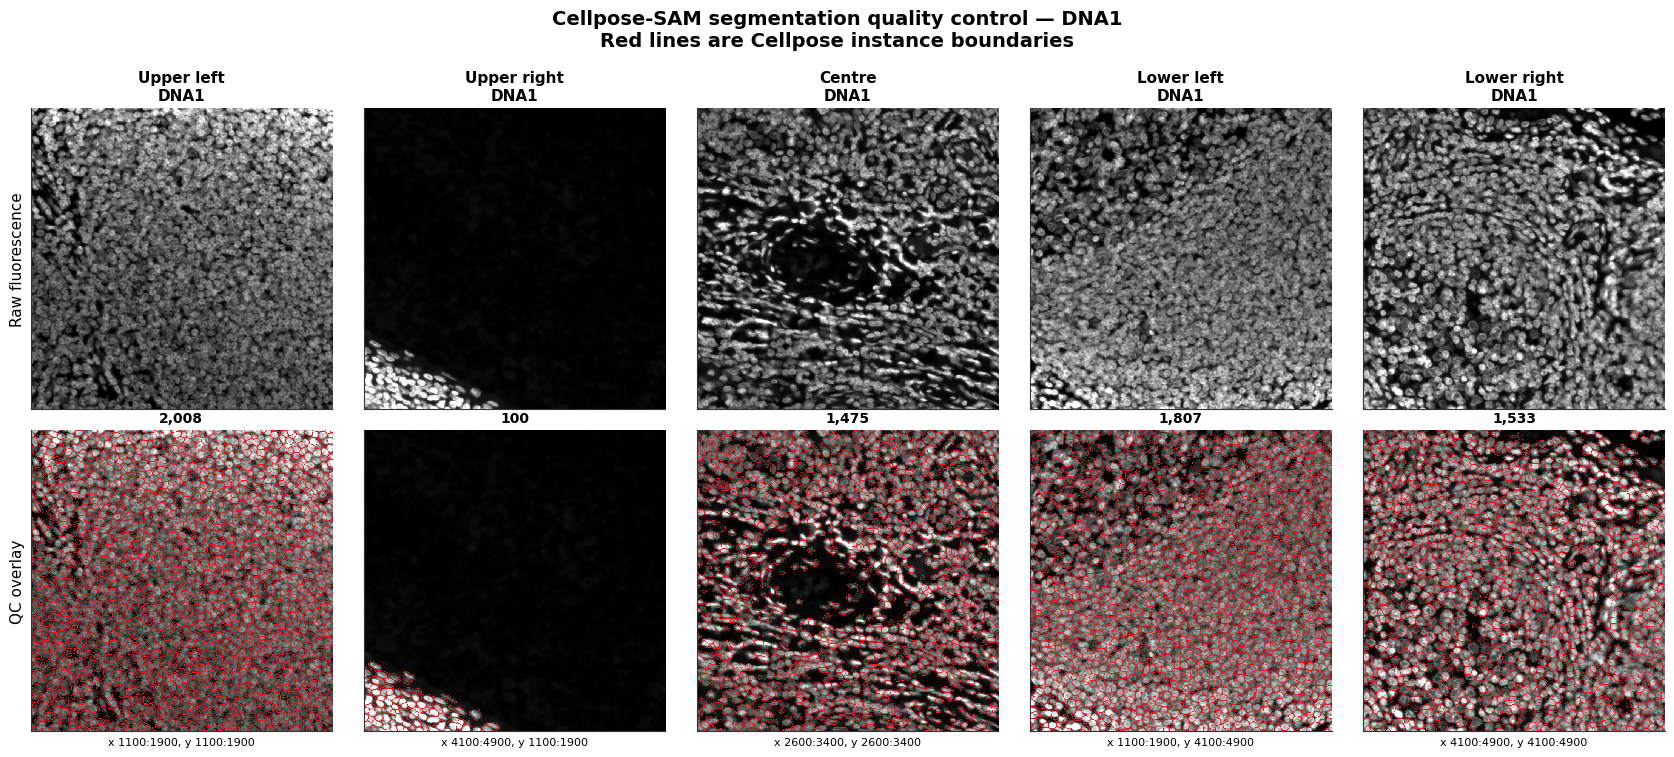


QC PNG saved: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1_QC_five_regions.png
QC PDF saved: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1_QC_five_regions.pdf

CELL 1 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# CELL 1 — Fresh Cellpose-SAM segmentation on DNA1
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

# ------------------------------------------------------------
# 1. Install/check Cellpose
# ------------------------------------------------------------

import sys
import subprocess
import importlib
import importlib.metadata
from packaging.version import Version

try:
    cellpose_version = importlib.metadata.version("cellpose")
except importlib.metadata.PackageNotFoundError:
    cellpose_version = None

if cellpose_version is None or Version(cellpose_version) < Version("4.2"):
    print("Installing Cellpose 4.2+...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        "cellpose>=4.2,<5",
    ])
    importlib.invalidate_caches()

# ------------------------------------------------------------
# 2. Imports and paths
# ------------------------------------------------------------

import gc
import json
import time
import hashlib
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import tifffile
import torch
import matplotlib.pyplot as plt

from cellpose import models
from skimage.segmentation import find_boundaries

ROOT = Path(
    "/content/drive/MyDrive/CyCIF_validation/"
    "TONSIL-1_40X_Field_01_01"
)

IMAGE_PATH = ROOT / "TONSIL-1_40X_Field_01_01.tif"

# New, isolated analysis folder.
RUN_DIR = ROOT / "cellpose_vs_published_v1"
RUN_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1"

MASK_NPY = RUN_DIR / f"{RUN_NAME}_masks.npy"
MASK_TIF = RUN_DIR / f"{RUN_NAME}_masks.tif"
MANIFEST_JSON = RUN_DIR / f"{RUN_NAME}_manifest.json"
QC_PNG = RUN_DIR / f"{RUN_NAME}_QC_five_regions.png"
QC_PDF = RUN_DIR / f"{RUN_NAME}_QC_five_regions.pdf"

# This must remain False for the first independent run.
REUSE_EXISTING_MASK = True

if not IMAGE_PATH.exists():
    raise FileNotFoundError(IMAGE_PATH)

# Refuse silent reuse.
if MASK_NPY.exists() and not REUSE_EXISTING_MASK:
    raise FileExistsError(
        f"A mask already exists:\n{MASK_NPY}\n\n"
        "For a genuinely fresh run, rename/delete the "
        "'cellpose_vs_published_v1' folder.\n"
        "To deliberately reuse the verified mask, change "
        "REUSE_EXISTING_MASK = True."
    )

# ------------------------------------------------------------
# 3. Verify GPU
# ------------------------------------------------------------

cellpose_version = importlib.metadata.version("cellpose")

print("=" * 72)
print("CELLPOSE ENVIRONMENT")
print("=" * 72)
print("Cellpose version :", cellpose_version)
print("PyTorch version  :", torch.__version__)
print("CUDA available   :", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. In Colab select Runtime > "
        "Change runtime type > T4 GPU."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU              :", gpu_name)
print("GPU capability   :", gpu_capability)

# T4 has compute capability 7.5, so use float32 rather than bfloat16.
use_bfloat16 = gpu_capability[0] >= 8

print("Use bfloat16     :", use_bfloat16)

# ------------------------------------------------------------
# 4. Read DNA1 only
# ------------------------------------------------------------

with tifffile.TiffFile(IMAGE_PATH) as tif:
    series = tif.series[0]

    if series.axes != "CYX":
        raise ValueError(
            f"Expected CYX axes; found {series.axes!r}"
        )

    if series.shape != (44, 6000, 6000):
        raise ValueError(
            f"Expected (44,6000,6000); found {series.shape}"
        )

    # Channel index 0 = DNA1.
    dapi = tif.pages[0].asarray()

if dapi.shape != (6000, 6000):
    raise ValueError(f"Unexpected DNA1 shape: {dapi.shape}")

if not np.issubdtype(dapi.dtype, np.integer):
    raise ValueError(f"Unexpected DNA1 dtype: {dapi.dtype}")

# Reproducibility fingerprint for the exact DNA1 pixels.
dapi_contiguous = np.ascontiguousarray(dapi)
dapi_hash = hashlib.sha256(
    memoryview(dapi_contiguous).cast("B")
).hexdigest()

print("\n" + "=" * 72)
print("DNA1 INPUT")
print("=" * 72)
print("Shape        :", dapi.shape)
print("dtype        :", dapi.dtype)
print("Range        :", int(dapi.min()), "to", int(dapi.max()))
print("Median       :", float(np.median(dapi)))
print("SHA-256      :", dapi_hash)
print("Source       :", IMAGE_PATH)

# ------------------------------------------------------------
# 5. Fixed Cellpose parameters
# ------------------------------------------------------------

CELLPOSE_PARAMETERS = {
    "model": "cpsam_v2",
    "input_channel": "DNA1",
    "channel_index_zero_based": 0,
    "channel_axis": None,
    "do_3D": True,
    "diameter": None,
    "normalize": True,
    "batch_size": 8,
    "flow_threshold": 0.4,
    "cellprob_threshold": 0.0,
    "min_size": 15,
    "tile_overlap": 0.1,
    "augment": False,
    "use_bfloat16": use_bfloat16,
}

# ------------------------------------------------------------
# 6. Run or deliberately reload Cellpose
# ------------------------------------------------------------

if REUSE_EXISTING_MASK:
    if not MANIFEST_JSON.exists():
        raise FileNotFoundError(
            "Existing mask has no provenance manifest. "
            "Do not reuse it."
        )

    print("\nLoading the deliberately selected existing mask...")
    masks = np.load(MASK_NPY).astype(np.int32, copy=False)
    segmentation_seconds = None
    run_status = "deliberately reused"

else:
    print("\nLoading cpsam_v2...")
    model = models.CellposeModel(
        gpu=True,
        pretrained_model="cpsam_v2",
        use_bfloat16=use_bfloat16,
    )

    print("Running Cellpose on the complete 6000 x 6000 DNA1 image...")
    start = time.time()

    # A 2-D grayscale image is a supported Cellpose input.
    # Cellpose performs the internal channel conversion.
    result = model.eval(
        dapi,
        channel_axis=None,
        do_3D=False,
        diameter=None,
        normalize=True,
        batch_size=8,
        flow_threshold=0.4,
        cellprob_threshold=0.0,
        min_size=15,
        tile_overlap=0.1,
        augment=False,
    )

    segmentation_seconds = time.time() - start
    masks = np.asarray(result[0], dtype=np.int32)
    run_status = "freshly computed"

    del result, model
    torch.cuda.empty_cache()
    gc.collect()

# ------------------------------------------------------------
# 7. Validate the returned label image
# ------------------------------------------------------------

if masks.shape != dapi.shape:
    raise ValueError(
        f"Cellpose mask shape {masks.shape} does not match "
        f"DNA1 shape {dapi.shape}"
    )

if masks.min() < 0:
    raise ValueError("Cellpose returned negative labels.")

counts = np.bincount(masks.reshape(-1))
cellpose_ids = np.flatnonzero(counts[1:]) + 1
cell_areas = counts[cellpose_ids]

n_cells = len(cellpose_ids)
coverage = 100.0 * np.mean(masks > 0)

if n_cells == 0:
    raise RuntimeError("Cellpose returned zero cells.")

labels_contiguous = np.array_equal(
    cellpose_ids,
    np.arange(1, int(cellpose_ids.max()) + 1),
)

border_ids = np.unique(np.concatenate([
    masks[0, :],
    masks[-1, :],
    masks[:, 0],
    masks[:, -1],
]))
border_ids = border_ids[border_ids > 0]

print("\n" + "=" * 72)
print("CELLPOSE SEGMENTATION RESULT")
print("=" * 72)
print("Run status             :", run_status)
print("Mask shape             :", masks.shape)
print("Label dtype            :", masks.dtype)
print("Segmented cells        :", f"{n_cells:,}")
print("Maximum label          :", f"{int(masks.max()):,}")
print("Labels contiguous      :", labels_contiguous)
print("Foreground coverage    :", f"{coverage:.2f}%")
print("Median cell area       :", f"{np.median(cell_areas):.1f} px")
print("Cell-area 5th–95th pct :", (
    f"{np.percentile(cell_areas, 5):.1f} to "
    f"{np.percentile(cell_areas, 95):.1f} px"
))
print("Cells touching border  :", f"{len(border_ids):,}")

if segmentation_seconds is not None:
    print(
        "Segmentation time      :",
        f"{segmentation_seconds / 60:.2f} min",
    )

# ------------------------------------------------------------
# 8. Save the exact mask and provenance
# ------------------------------------------------------------

if not REUSE_EXISTING_MASK:
    np.save(MASK_NPY, masks)

    tifffile.imwrite(
        MASK_TIF,
        masks.astype(np.uint32),
        photometric="minisblack",
        metadata={"axes": "YX"},
        compression=None,
    )

    manifest = {
        "run_name": RUN_NAME,
        "run_status": run_status,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "source_image": str(IMAGE_PATH),
        "dapi_sha256": dapi_hash,
        "dapi_shape": list(dapi.shape),
        "dapi_dtype": str(dapi.dtype),
        "cellpose_version": cellpose_version,
        "pytorch_version": torch.__version__,
        "gpu": gpu_name,
        "gpu_capability": list(gpu_capability),
        "parameters": CELLPOSE_PARAMETERS,
        "n_cells": int(n_cells),
        "foreground_coverage_pct": float(coverage),
        "median_cell_area_px": float(np.median(cell_areas)),
        "segmentation_seconds": (
            float(segmentation_seconds)
            if segmentation_seconds is not None
            else None
        ),
    }

    with open(MANIFEST_JSON, "w") as handle:
        json.dump(manifest, handle, indent=2)

print("\nSaved mask NPY :", MASK_NPY)
print("Saved mask TIFF:", MASK_TIF)
print("Run manifest   :", MANIFEST_JSON)

# ------------------------------------------------------------
# 9. Five-region, non-cherry-picked visual QC
# ------------------------------------------------------------

def contrast_stretch(image):
    positive = image[image > 0]

    if positive.size == 0:
        return np.zeros(image.shape, dtype=np.float32)

    low, high = np.percentile(positive, [1.0, 99.7])

    return np.clip(
        (image.astype(np.float32) - low) /
        (high - low + 1e-8),
        0,
        1,
    )

height, width = dapi.shape
crop_size = 800

# Centre and four fixed quadrants.
crop_centres = [
    ("Upper left", 0.25, 0.25),
    ("Upper right", 0.25, 0.75),
    ("Centre", 0.50, 0.50),
    ("Lower left", 0.75, 0.25),
    ("Lower right", 0.75, 0.75),
]

fig, axes = plt.subplots(
    2,
    len(crop_centres),
    figsize=(17, 7.3),
    facecolor="white",
)

for column, (name, y_fraction, x_fraction) in enumerate(crop_centres):
    yc = int(height * y_fraction)
    xc = int(width * x_fraction)

    y0 = max(0, min(height - crop_size, yc - crop_size // 2))
    x0 = max(0, min(width - crop_size, xc - crop_size // 2))
    y1 = y0 + crop_size
    x1 = x0 + crop_size

    dapi_crop = dapi[y0:y1, x0:x1]
    mask_crop = masks[y0:y1, x0:x1]

    gray = contrast_stretch(dapi_crop)
    boundaries = find_boundaries(mask_crop, mode="outer")

    overlay = np.repeat(gray[..., None], 3, axis=-1)
    overlay[boundaries] = [1.0, 0.08, 0.08]

    local_ids = np.unique(mask_crop)
    local_count = int(np.sum(local_ids > 0))

    axes[0, column].imshow(
        gray,
        cmap="gray",
        interpolation="nearest",
    )
    axes[0, column].set_title(
        f"{name}\nDNA1",
        fontsize=11,
        fontweight="bold",
    )

    axes[1, column].imshow(
        overlay,
        interpolation="nearest",
    )
    axes[1, column].set_title(
        f"\n{local_count:,}",
        fontsize=10,
    )

    for row in range(2):
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])

    axes[1, column].set_xlabel(
        f"x {x0}:{x1}, y {y0}:{y1}",
        fontsize=8,
    )

axes[0, 0].set_ylabel("Raw fluorescence", fontsize=11)
axes[1, 0].set_ylabel("QC overlay", fontsize=11)

fig.suptitle(
    "Cellpose-SAM segmentation quality control — DNA1\n"
    "Red lines are Cellpose instance boundaries",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    QC_PNG,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)
fig.savefig(
    QC_PDF,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(fig)

print("\nQC PNG saved:", QC_PNG)
print("QC PDF saved:", QC_PDF)
print("\nCELL 1 COMPLETED SUCCESSFULLY")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 2 — INPUT VALIDATION
Image TIFF        : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/TONSIL-1_40X_Field_01_01.tif
Cellpose mask     : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1_masks.npy
CELL 1 manifest   : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1_manifest.json
Mask shape        : (6000, 6000)
Mask dtype        : int32
Cellpose objects  : 61,173
Mask SHA-256      : 93ac5f987ea43dc19574e4b140fa885a1e89d4fb7de6eb8db750630f4f14672c

Computing Cellpose morphology and centroids...

TIFF shape        : (44, 6000, 6000)
TIFF axes         : CYX
TIFF pages        : 44
Marker source col : marker_name
First marker      : DNA1
Last marker       : LAMIN_B

QUANTIFYING 44 CHAN

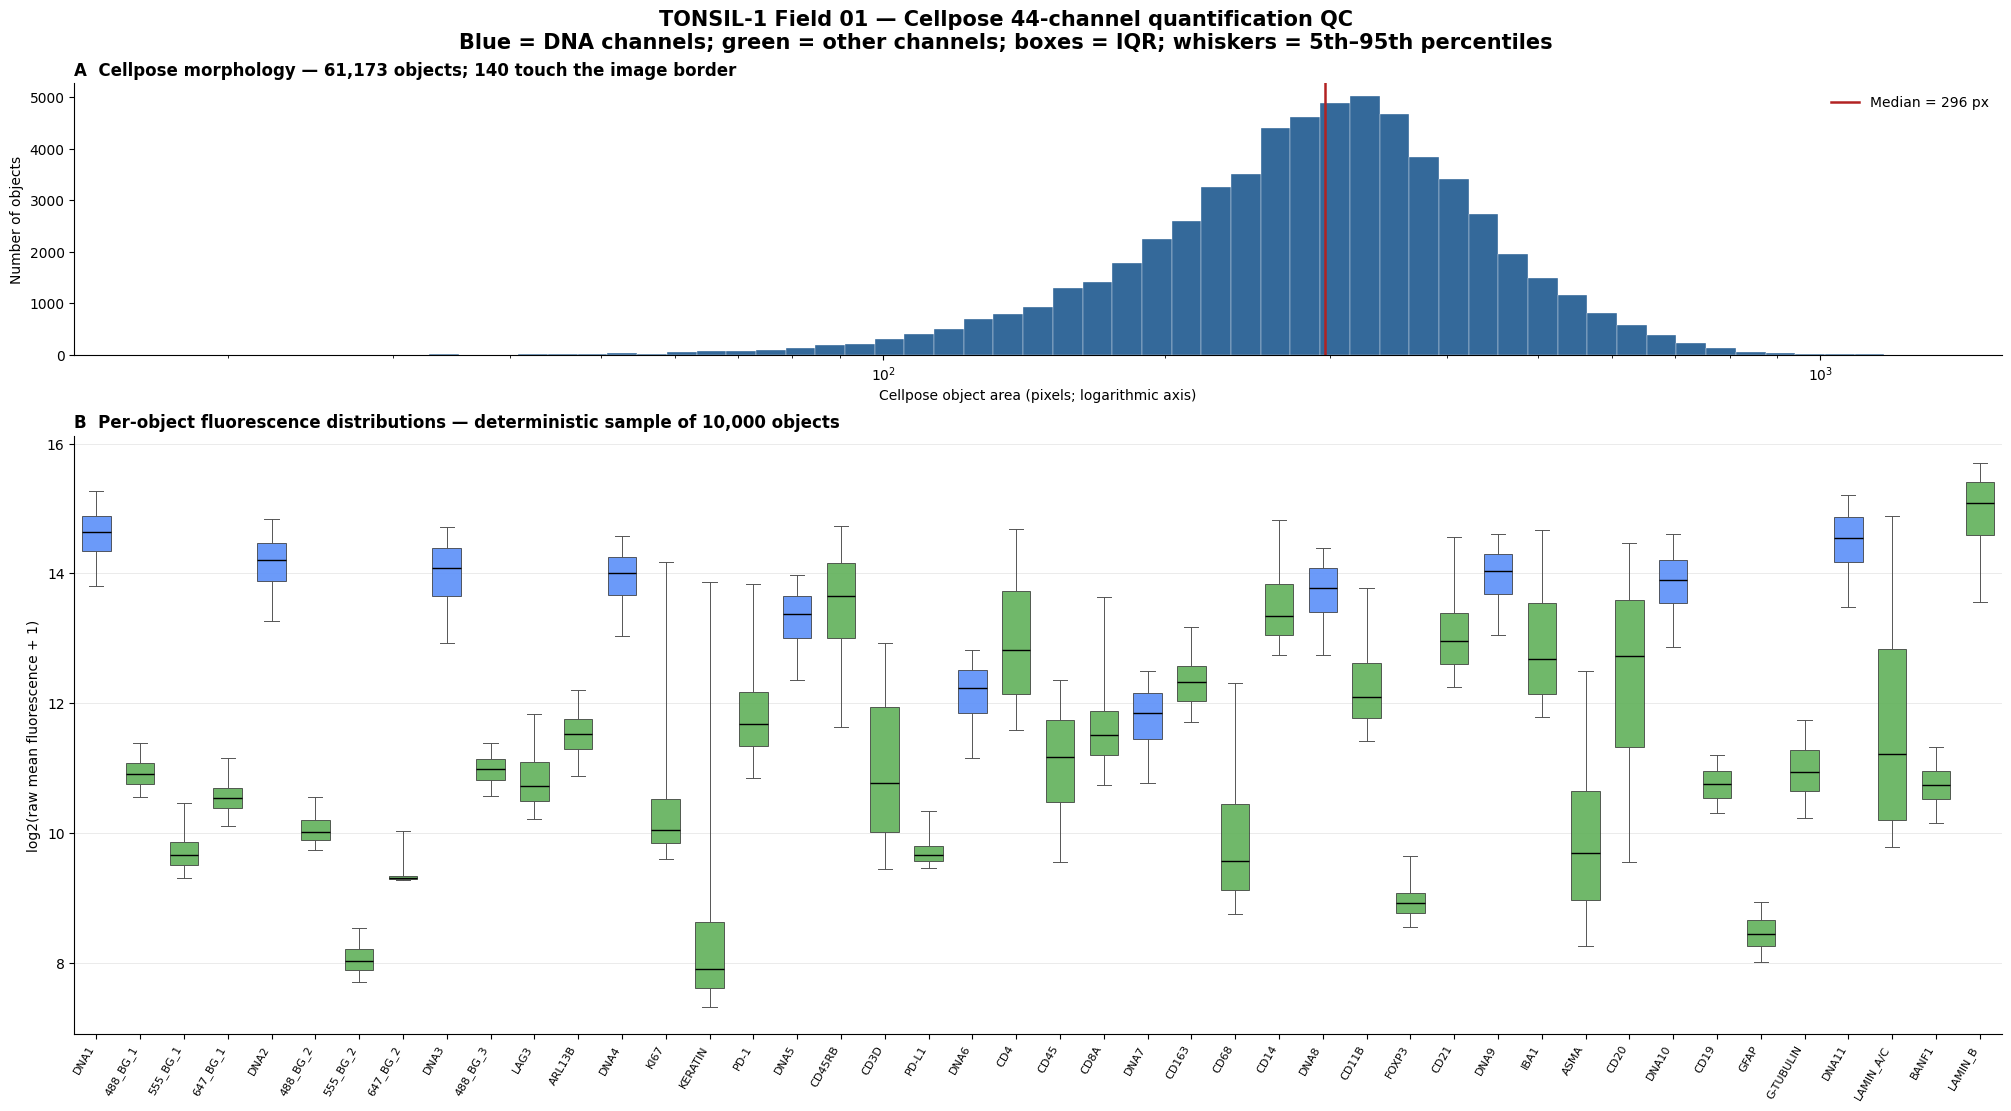


CELL 2 COMPLETED SUCCESSFULLY
Rows saved             : 61,173
Morphology columns     : 5
Raw intensity columns  : 44
Border-touching objects: 140
Elapsed time           : 4.83 min

Raw feature table : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/TONSIL-1_40X_Field_01_01_cellpose_44ch_raw_features.csv
Channel map       : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cellpose_44ch_channel_map.csv
Channel summary   : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cellpose_44ch_channel_summary.csv
Manifest          : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cellpose_44ch_quantification_manifest.json
QC PNG            : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cellpose_44ch_quantification_QC.png
QC PDF            : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_

In [ ]:
# ============================================================
# CELL 2 — Quantify all 44 channels in the saved Cellpose mask
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import hashlib
import json
import re
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile


# ------------------------------------------------------------
# Paths: these point only to the fresh output from CELL 1.
# ------------------------------------------------------------
ROOT = Path(
    "/content/drive/MyDrive/CyCIF_validation/"
    "TONSIL-1_40X_Field_01_01"
)
RUN_DIR = ROOT / "cellpose_vs_published_v1"

IMAGE_PATH = ROOT / "TONSIL-1_40X_Field_01_01.tif"
MARKERS_PATH = ROOT / "markers.csv"

MASK_NPY = (
    RUN_DIR /
    "TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1_masks.npy"
)
CELL1_MANIFEST = (
    RUN_DIR /
    "TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1_manifest.json"
)

FEATURES_CSV = (
    RUN_DIR /
    "TONSIL-1_40X_Field_01_01_cellpose_44ch_raw_features.csv"
)
CHANNEL_MAP_CSV = RUN_DIR / "cellpose_44ch_channel_map.csv"
CHANNEL_SUMMARY_CSV = RUN_DIR / "cellpose_44ch_channel_summary.csv"
CELL2_MANIFEST = RUN_DIR / "cellpose_44ch_quantification_manifest.json"
QC_PNG = RUN_DIR / "cellpose_44ch_quantification_QC.png"
QC_PDF = RUN_DIR / "cellpose_44ch_quantification_QC.pdf"

RUN_DIR.mkdir(parents=True, exist_ok=True)

for required in [IMAGE_PATH, MARKERS_PATH, MASK_NPY, CELL1_MANIFEST]:
    if not required.exists():
        raise FileNotFoundError(required)


def sha256_file(path, block_bytes=16 * 1024 * 1024):
    """Return a streaming SHA-256 hash without loading the file twice."""
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            block = handle.read(block_bytes)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def load_marker_order(path, expected_count):
    """Extract an ordered marker-name column from markers.csv."""
    preferred = {
        "marker", "markers", "marker_name", "channel_name",
        "antibody", "protein", "name",
    }

    attempts = [pd.read_csv(path), pd.read_csv(path, header=None)]

    for table in attempts:
        table = table.dropna(axis=0, how="all").dropna(axis=1, how="all")
        columns = list(table.columns)
        columns.sort(
            key=lambda col: str(col).strip().lower() not in preferred
        )

        for col in columns:
            values = table[col].dropna().astype(str).str.strip()
            values = values[values.ne("")].reset_index(drop=True)

            # Headerless reading may include the real header as row zero.
            if len(values) == expected_count + 1:
                first = values.iloc[0].lower()
                if first in preferred or "marker" in first:
                    values = values.iloc[1:].reset_index(drop=True)

            if len(values) != expected_count:
                continue

            alphabetic_fraction = values.str.contains(
                r"[A-Za-z]", regex=True
            ).mean()
            unique_fraction = values.nunique() / expected_count

            if alphabetic_fraction >= 0.75 and unique_fraction >= 0.75:
                return values.tolist(), str(col)

    raise ValueError(
        f"Could not identify {expected_count} ordered marker names in {path}. "
        "Paste the printed markers.csv preview here and stop this cell."
    )


def safe_marker_name(marker):
    """Make a stable, analysis-friendly fragment for a CSV column name."""
    text = re.sub(r"[^A-Za-z0-9]+", "_", str(marker)).strip("_")
    return text or "unnamed"


print("=" * 72)
print("CELL 2 — INPUT VALIDATION")
print("=" * 72)

with open(CELL1_MANIFEST, "r", encoding="utf-8") as handle:
    cell1_manifest = json.load(handle)

mask = np.load(MASK_NPY)
if mask.ndim != 2:
    raise ValueError(f"Expected a 2-D instance mask; got {mask.shape}")
if not np.issubdtype(mask.dtype, np.integer):
    raise TypeError(f"Expected integer labels; got {mask.dtype}")
if not mask.flags.c_contiguous:
    mask = np.ascontiguousarray(mask)

height, width = mask.shape
n_cells = int(mask.max())
flat_mask = mask.reshape(-1)
pixel_counts = np.bincount(flat_mask, minlength=n_cells + 1)
areas = pixel_counts[1:].astype(np.int64, copy=False)

if n_cells != 61_173:
    raise ValueError(
        f"Expected the CELL 1 mask with 61,173 labels; got {n_cells:,}. "
        "Do not continue with a different mask."
    )
if np.any(areas == 0):
    raise ValueError("Mask labels are not contiguous; one or more IDs are empty.")

mask_sha256 = sha256_file(MASK_NPY)

print("Image TIFF        :", IMAGE_PATH)
print("Cellpose mask     :", MASK_NPY)
print("CELL 1 manifest   :", CELL1_MANIFEST)
print("Mask shape        :", mask.shape)
print("Mask dtype        :", mask.dtype)
print("Cellpose objects  :", f"{n_cells:,}")
print("Mask SHA-256      :", mask_sha256)


# ------------------------------------------------------------
# Morphology: IDs, areas, centroids, and border-touching flag.
# Centroids are computed in blocks to avoid allocating two full
# 6000 x 6000 coordinate arrays.
# ------------------------------------------------------------
print("\nComputing Cellpose morphology and centroids...")

sum_y = np.zeros(n_cells + 1, dtype=np.float64)
sum_x = np.zeros(n_cells + 1, dtype=np.float64)
x_coordinates = np.arange(width, dtype=np.float64)
row_block = 128

for y_start in range(0, height, row_block):
    y_stop = min(y_start + row_block, height)
    label_block = mask[y_start:y_stop, :].reshape(-1)

    y_weights = np.repeat(
        np.arange(y_start, y_stop, dtype=np.float64), width
    )
    x_weights = np.tile(x_coordinates, y_stop - y_start)

    sum_y += np.bincount(
        label_block, weights=y_weights, minlength=n_cells + 1
    )
    sum_x += np.bincount(
        label_block, weights=x_weights, minlength=n_cells + 1
    )

centroid_y = sum_y[1:] / areas
centroid_x = sum_x[1:] / areas

border_ids = np.unique(
    np.concatenate([
        mask[0, :], mask[-1, :], mask[:, 0], mask[:, -1]
    ])
)
border_ids = border_ids[border_ids > 0]
touches_border = np.zeros(n_cells + 1, dtype=bool)
touches_border[border_ids] = True

features = pd.DataFrame({
    "CellposeID": np.arange(1, n_cells + 1, dtype=np.int32),
    "Area_px": areas,
    "CentroidX_px": centroid_x,
    "CentroidY_px": centroid_y,
    "TouchesBorder": touches_border[1:],
})

del sum_x, sum_y, x_coordinates, y_weights, x_weights, label_block
gc.collect()


# ------------------------------------------------------------
# Read metadata and quantify one TIFF page at a time.
# The raw mean is sum(pixel intensity inside object) / Area_px.
# No log transform, normalization, threshold, or CSV fitting occurs.
# ------------------------------------------------------------
with tifffile.TiffFile(IMAGE_PATH) as tif:
    image_shape = tuple(tif.series[0].shape)
    image_axes = tif.series[0].axes
    page_count = len(tif.pages)

print("\nTIFF shape        :", image_shape)
print("TIFF axes         :", image_axes)
print("TIFF pages        :", page_count)

if image_axes != "CYX" or image_shape != (44, height, width):
    raise ValueError(
        f"Expected (44,{height},{width}) CYX TIFF; "
        f"got {image_shape}, axes={image_axes}"
    )
if page_count != 44:
    raise ValueError(f"Expected 44 TIFF pages; got {page_count}")

markers, marker_column_source = load_marker_order(MARKERS_PATH, page_count)
if len(set(markers)) != len(markers):
    duplicates = pd.Series(markers)[pd.Series(markers).duplicated()].tolist()
    raise ValueError(f"Duplicate marker names found: {duplicates}")

print("Marker source col :", marker_column_source)
print("First marker      :", markers[0])
print("Last marker       :", markers[-1])

channel_map_rows = []
channel_summary_rows = []
feature_columns = []
quantification_start = time.time()

print("\n" + "=" * 72)
print("QUANTIFYING 44 CHANNELS INSIDE THE CELLPOSE MASK")
print("=" * 72)

with tifffile.TiffFile(IMAGE_PATH) as tif:
    for page_index, marker in enumerate(markers):
        channel_start = time.time()
        channel = tif.pages[page_index].asarray()

        if channel.shape != mask.shape:
            raise ValueError(
                f"Page {page_index} ({marker}) has shape {channel.shape}; "
                f"expected {mask.shape}"
            )

        # np.bincount accumulates weighted sums as float64.
        sums = np.bincount(
            flat_mask,
            weights=channel.reshape(-1),
            minlength=n_cells + 1,
        )
        raw_means = sums[1:] / areas

        if not np.all(np.isfinite(raw_means)):
            raise FloatingPointError(
                f"Non-finite cell means in page {page_index}: {marker}"
            )

        feature_column = (
            f"C{page_index + 1:02d}_{safe_marker_name(marker)}_MeanRaw"
        )
        features[feature_column] = raw_means
        feature_columns.append(feature_column)

        q05, q25, q50, q75, q95 = np.percentile(
            raw_means, [5, 25, 50, 75, 95]
        )

        channel_map_rows.append({
            "ChannelNumber_1based": page_index + 1,
            "TIFFPage_0based": page_index,
            "Marker": marker,
            "CellposeFeatureColumn": feature_column,
            "Measurement": "raw arithmetic mean inside Cellpose mask",
        })

        channel_summary_rows.append({
            "ChannelNumber_1based": page_index + 1,
            "TIFFPage_0based": page_index,
            "Marker": marker,
            "ImageDtype": str(channel.dtype),
            "ImageMin": float(channel.min()),
            "ImageMax": float(channel.max()),
            "CellMean_P05": float(q05),
            "CellMean_P25": float(q25),
            "CellMean_Median": float(q50),
            "CellMean_P75": float(q75),
            "CellMean_P95": float(q95),
            "ForegroundWeightedMean": float(sums[1:].sum() / areas.sum()),
        })

        elapsed = time.time() - channel_start
        print(
            f"[{page_index + 1:02d}/44] "
            f"{marker:<12} median={q50:10.3f}  "
            f"P05-P95={q05:10.3f}-{q95:10.3f}  "
            f"{elapsed:5.1f} s"
        )

        del channel, sums, raw_means
        gc.collect()


channel_map = pd.DataFrame(channel_map_rows)
channel_summary = pd.DataFrame(channel_summary_rows)

# Preserve all objects. Border-touching objects are flagged, not deleted.
features.to_csv(FEATURES_CSV, index=False, float_format="%.10g")
channel_map.to_csv(CHANNEL_MAP_CSV, index=False)
channel_summary.to_csv(
    CHANNEL_SUMMARY_CSV, index=False, float_format="%.10g"
)


# ------------------------------------------------------------
# Independent reload checks: confirm the saved CSV is complete.
# ------------------------------------------------------------
saved_check = pd.read_csv(FEATURES_CSV)

expected_columns = 5 + page_count
if saved_check.shape != (n_cells, expected_columns):
    raise ValueError(
        f"Saved feature table has shape {saved_check.shape}; "
        f"expected {(n_cells, expected_columns)}"
    )
if not np.array_equal(
    saved_check["CellposeID"].to_numpy(),
    np.arange(1, n_cells + 1),
):
    raise ValueError("Saved CellposeID sequence is incorrect.")
if saved_check[feature_columns].isna().any().any():
    raise ValueError("Saved feature table contains missing intensity values.")


# ------------------------------------------------------------
# QC figure. log2(mean + 1) is used ONLY for display here.
# The exported feature table retains untransformed raw means.
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

rng = np.random.default_rng(20260902)
sample_size = min(10_000, n_cells)
sample_rows = np.sort(rng.choice(n_cells, size=sample_size, replace=False))

qc_values = np.log2(
    features.loc[sample_rows, feature_columns].to_numpy(dtype=np.float64) + 1.0
)

fig = plt.figure(figsize=(20, 11), constrained_layout=True)
grid = fig.add_gridspec(2, 1, height_ratios=[1.0, 2.2])

ax_area = fig.add_subplot(grid[0, 0])
positive_areas = areas[areas > 0]
area_bins = np.geomspace(positive_areas.min(), positive_areas.max(), 60)
ax_area.hist(
    positive_areas,
    bins=area_bins,
    color="#34699A",
    edgecolor="white",
    linewidth=0.25,
)
ax_area.set_xscale("log")
ax_area.axvline(
    np.median(positive_areas),
    color="#B22222",
    linewidth=1.8,
    label=f"Median = {np.median(positive_areas):,.0f} px",
)
ax_area.set_xlabel("Cellpose object area (pixels; logarithmic axis)")
ax_area.set_ylabel("Number of objects")
ax_area.set_title(
    f"A  Cellpose morphology — {n_cells:,} objects; "
    f"{len(border_ids):,} touch the image border",
    loc="left",
    fontweight="bold",
)
ax_area.legend(frameon=False)

ax_box = fig.add_subplot(grid[1, 0])
box = ax_box.boxplot(
    [qc_values[:, i] for i in range(page_count)],
    positions=np.arange(1, page_count + 1),
    widths=0.65,
    whis=(5, 95),
    showfliers=False,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.0},
    whiskerprops={"color": "#555555", "linewidth": 0.7},
    capprops={"color": "#555555", "linewidth": 0.7},
)

for patch, marker in zip(box["boxes"], markers):
    is_dna = marker.upper().startswith("DNA")
    patch.set_facecolor("#5B8FF9" if is_dna else "#61B15A")
    patch.set_edgecolor("#333333")
    patch.set_linewidth(0.6)
    patch.set_alpha(0.9)

ax_box.set_xticks(np.arange(1, page_count + 1))
ax_box.set_xticklabels(markers, rotation=60, ha="right", fontsize=8)
ax_box.set_ylabel("log2(raw mean fluorescence + 1)")
ax_box.set_title(
    f"B  Per-object fluorescence distributions — deterministic sample "
    f"of {sample_size:,} objects",
    loc="left",
    fontweight="bold",
)
ax_box.grid(axis="y", color="#DDDDDD", linewidth=0.6, alpha=0.7)

fig.suptitle(
    "TONSIL-1 Field 01 — Cellpose 44-channel quantification QC\n"
    "Blue = DNA channels; green = other channels; boxes = IQR; "
    "whiskers = 5th–95th percentiles",
    fontsize=15,
    fontweight="bold",
)

fig.savefig(QC_PNG, dpi=240, bbox_inches="tight", facecolor="white")
fig.savefig(QC_PDF, bbox_inches="tight", facecolor="white")
plt.show()


elapsed_minutes = (time.time() - quantification_start) / 60

cell2_manifest = {
    "stage": "CELL 2 — Cellpose-mask raw fluorescence quantification",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_image": str(IMAGE_PATH),
    "source_markers": str(MARKERS_PATH),
    "source_cell1_manifest": str(CELL1_MANIFEST),
    "source_mask_npy": str(MASK_NPY),
    "source_mask_sha256": mask_sha256,
    "image_shape": list(image_shape),
    "image_axes": image_axes,
    "cellpose_object_count": n_cells,
    "border_touching_object_count": int(len(border_ids)),
    "measurement": "raw arithmetic mean of TIFF pixels per Cellpose label",
    "transform_applied_to_saved_features": "none",
    "qc_plot_transform_only": "log2(raw mean + 1)",
    "coordinate_convention": {
        "CentroidX_px": "zero-based image column coordinate",
        "CentroidY_px": "zero-based image row coordinate",
    },
    "feature_table": str(FEATURES_CSV),
    "channel_map": str(CHANNEL_MAP_CSV),
    "channel_summary": str(CHANNEL_SUMMARY_CSV),
    "qc_png": str(QC_PNG),
    "qc_pdf": str(QC_PDF),
    "elapsed_minutes": elapsed_minutes,
}

with open(CELL2_MANIFEST, "w", encoding="utf-8") as handle:
    json.dump(cell2_manifest, handle, indent=2)


print("\n" + "=" * 72)
print("CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 72)
print("Rows saved             :", f"{len(features):,}")
print("Morphology columns     :", 5)
print("Raw intensity columns  :", len(feature_columns))
print("Border-touching objects:", f"{len(border_ids):,}")
print("Elapsed time           :", f"{elapsed_minutes:.2f} min")
print("\nRaw feature table :", FEATURES_CSV)
print("Channel map       :", CHANNEL_MAP_CSV)
print("Channel summary   :", CHANNEL_SUMMARY_CSV)
print("Manifest          :", CELL2_MANIFEST)
print("QC PNG            :", QC_PNG)
print("QC PDF            :", QC_PDF)
print("\nIMPORTANT: published CSV has not been read or fitted in this cell.")
print("Send the completion summary and QC image before CELL 3.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 3 — VERIFY CELL 2 INPUTS
Cellpose rows       : 61,173
Cellpose channels   : 44
Cellpose table      : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/TONSIL-1_40X_Field_01_01_cellpose_44ch_raw_features.csv
Published CSV       : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/TONSIL-1_40X_Field_01_01.csv

PUBLISHED CSV INSPECTION
Total CSV columns          : 944
Mapped intensity columns   : 44
Valid published cell rows  : 65,535
Invalid core rows removed  : 0
Stored X range            : 1.348 to 5926.904
Stored Y range            : 1.450 to 5999.227
Published median area     : 120.0 px
First mapping              : DNA1 -> Cell_TONSIL1_40X_Field_01_01DAPI1
Last mapping               : LAMIN_B -> Cell_TONSIL1_40X_Field_01_01LAMINB

COORDINATE-CONVENTION DIAGNOSTICS
X,Y as stored              mutual=5

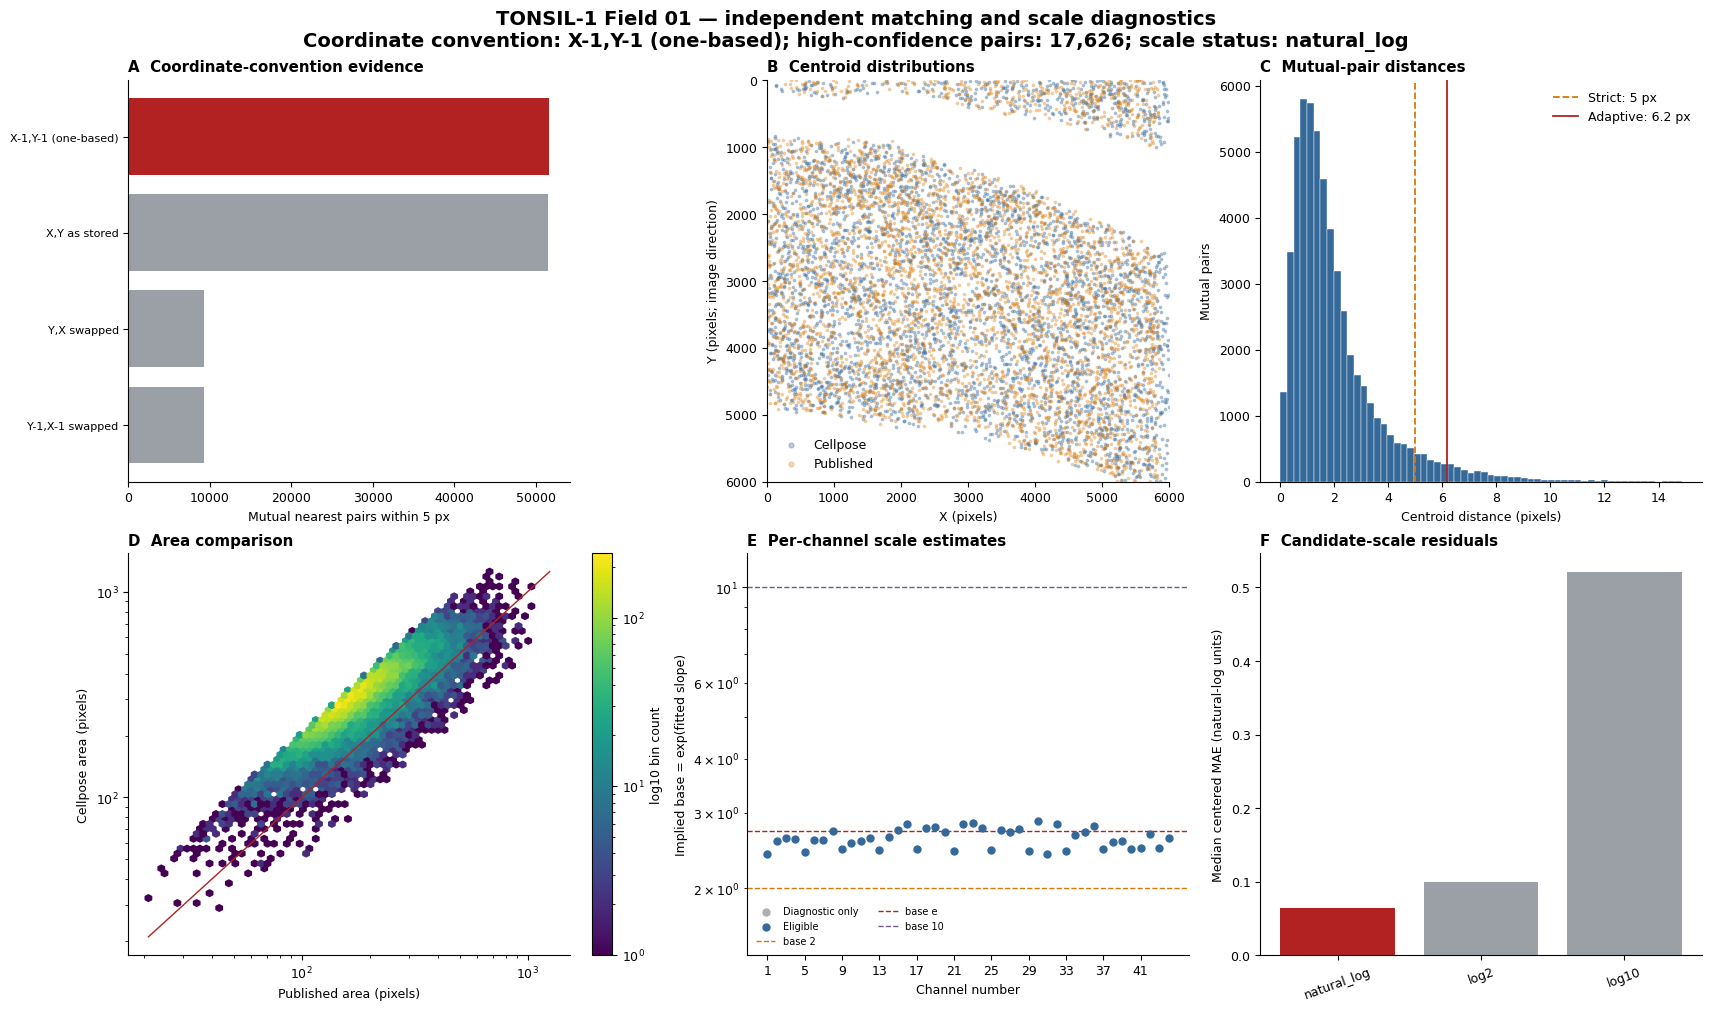


CELL 3 COMPLETED SUCCESSFULLY
Coordinate convention     : X-1,Y-1 (one-based)
Published cells           : 65,535
Cellpose cells            : 61,173
Mutual pairs              : 55,242
High-confidence pairs     : 17,626
Eligible scale channels   : 44/44
Published scale status    : natural_log
Elapsed time              : 0.22 min

Spatial matches      : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell3_spatial_matches.csv
Scale by channel     : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell3_scale_diagnostics_by_channel.csv
Scale candidates     : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell3_scale_candidate_summary.csv
Manifest             : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell3_matching_scale_manifest.json
QC PNG               : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_0

In [ ]:
# ============================================================
# CELL 3 — Inspect published CSV, match cells, infer log scale
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import hashlib
import json
import re
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import spearmanr


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ROOT = Path(
    "/content/drive/MyDrive/CyCIF_validation/"
    "TONSIL-1_40X_Field_01_01"
)
RUN_DIR = ROOT / "cellpose_vs_published_v1"

PUBLISHED_CSV = ROOT / "TONSIL-1_40X_Field_01_01.csv"
CELLPOSE_FEATURES = (
    RUN_DIR / "TONSIL-1_40X_Field_01_01_cellpose_44ch_raw_features.csv"
)
CHANNEL_MAP_CSV = RUN_DIR / "cellpose_44ch_channel_map.csv"
CELL2_MANIFEST = RUN_DIR / "cellpose_44ch_quantification_manifest.json"

SCHEMA_OUT = RUN_DIR / "cell3_published_csv_schema.csv"
COORDINATE_OUT = RUN_DIR / "cell3_coordinate_diagnostics.csv"
MATCHES_OUT = RUN_DIR / "cell3_spatial_matches.csv"
SCALE_CHANNEL_OUT = RUN_DIR / "cell3_scale_diagnostics_by_channel.csv"
SCALE_CANDIDATE_OUT = RUN_DIR / "cell3_scale_candidate_summary.csv"
MANIFEST_OUT = RUN_DIR / "cell3_matching_scale_manifest.json"
QC_PNG = RUN_DIR / "cell3_matching_and_scale_QC.png"
QC_PDF = RUN_DIR / "cell3_matching_and_scale_QC.pdf"

for required in [
    PUBLISHED_CSV,
    CELLPOSE_FEATURES,
    CHANNEL_MAP_CSV,
    CELL2_MANIFEST,
]:
    if not required.exists():
        raise FileNotFoundError(
            f"Missing required CELL 2 input: {required}\n"
            "Run CELL 2 successfully before CELL 3."
        )


def sha256_file(path, block_bytes=16 * 1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            block = handle.read(block_bytes)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def normalized_name(value):
    return re.sub(r"[^A-Za-z0-9]+", "", str(value)).upper()


def expected_published_suffix(marker):
    """Translate markers.csv names to the published CSV suffix convention."""
    marker_text = str(marker).strip()
    marker_upper = marker_text.upper()

    # markers.csv uses DNA1...DNA11, whereas the feature CSV uses DAPI1...DAPI11.
    dna_match = re.fullmatch(r"DNA(\d+)", marker_upper)
    if dna_match:
        return f"DAPI{dna_match.group(1)}"

    # Example: 488_BG_1 -> A488background1.
    background_match = re.fullmatch(r"(\d+)_BG_(\d+)", marker_upper)
    if background_match:
        wavelength, cycle = background_match.groups()
        return normalized_name(f"A{wavelength}background{cycle}")

    # This also handles PD-1 -> PD1, PD-L1 -> PDL1,
    # G-TUBULIN -> GTUBULIN, and LAMIN_A/C -> LAMINAC.
    return normalized_name(marker_text)


def tree_query(tree, coordinates):
    try:
        return tree.query(coordinates, k=1, workers=-1)
    except TypeError:
        return tree.query(coordinates, k=1)


start = time.time()

print("=" * 76)
print("CELL 3 — VERIFY CELL 2 INPUTS")
print("=" * 76)

with open(CELL2_MANIFEST, "r", encoding="utf-8") as handle:
    cell2_manifest = json.load(handle)

cellpose = pd.read_csv(CELLPOSE_FEATURES, low_memory=False)
channel_map = pd.read_csv(CHANNEL_MAP_CSV)

required_cp_columns = {
    "CellposeID", "Area_px", "CentroidX_px",
    "CentroidY_px", "TouchesBorder",
}
if not required_cp_columns.issubset(cellpose.columns):
    missing = sorted(required_cp_columns.difference(cellpose.columns))
    raise ValueError(f"CELL 2 feature table is missing columns: {missing}")

required_map_columns = {
    "ChannelNumber_1based", "Marker", "CellposeFeatureColumn"
}
if not required_map_columns.issubset(channel_map.columns):
    missing = sorted(required_map_columns.difference(channel_map.columns))
    raise ValueError(f"Channel map is missing columns: {missing}")

channel_map = channel_map.sort_values("ChannelNumber_1based").reset_index(drop=True)

if len(channel_map) != 44:
    raise ValueError(f"Expected 44 channel-map rows; found {len(channel_map)}")
if len(cellpose) != int(cell2_manifest["cellpose_object_count"]):
    raise ValueError(
        "CELL 2 row count does not agree with its manifest: "
        f"{len(cellpose):,} versus "
        f"{int(cell2_manifest['cellpose_object_count']):,}"
    )
if cellpose["CellposeID"].duplicated().any():
    raise ValueError("CellposeID is not unique.")

feature_columns = channel_map["CellposeFeatureColumn"].astype(str).tolist()
missing_features = [c for c in feature_columns if c not in cellpose.columns]
if missing_features:
    raise ValueError(f"Missing CELL 2 intensity columns: {missing_features}")

for column in ["CellposeID", "Area_px", "CentroidX_px", "CentroidY_px"]:
    cellpose[column] = pd.to_numeric(cellpose[column], errors="coerce")

if not np.isfinite(
    cellpose[["CellposeID", "Area_px", "CentroidX_px", "CentroidY_px"]]
    .to_numpy(dtype=np.float64)
).all():
    raise ValueError("CELL 2 morphology contains non-finite values.")

print("Cellpose rows       :", f"{len(cellpose):,}")
print("Cellpose channels   :", len(feature_columns))
print("Cellpose table      :", CELLPOSE_FEATURES)
print("Published CSV       :", PUBLISHED_CSV)


# ------------------------------------------------------------
# Inspect the original published CSV without altering it.
# ------------------------------------------------------------
published_header = pd.read_csv(PUBLISHED_CSV, nrows=0).columns.tolist()
published_intensity_columns = [
    column for column in published_header if str(column).startswith("Cell_")
]

required_published_core = ["CellId", "Area", "X_position", "Y_position"]
missing_core = [c for c in required_published_core if c not in published_header]
if missing_core:
    raise ValueError(f"Published CSV is missing core columns: {missing_core}")
if len(published_intensity_columns) != 44:
    raise ValueError(
        "Expected exactly 44 published columns beginning with 'Cell_'; "
        f"found {len(published_intensity_columns)}."
    )

# Match by the documented marker suffixes while allowing the field-name prefix.
# We then independently verify that the resulting mapping has the same order as
# the 44 Cell_ columns in the original CSV header.
mapped_published_columns = []
expected_suffixes = []
for marker in channel_map["Marker"].astype(str):
    expected_suffix = expected_published_suffix(marker)
    matches = [
        column
        for column in published_intensity_columns
        if normalized_name(column).endswith(expected_suffix)
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one published column for marker '{marker}' "
            f"using suffix '{expected_suffix}', but found {matches}."
        )

    expected_suffixes.append(expected_suffix)
    mapped_published_columns.append(matches[0])

if len(set(mapped_published_columns)) != 44:
    raise ValueError("Published marker mapping is not one-to-one.")

if mapped_published_columns != published_intensity_columns:
    mismatch_rows = [
        index + 1
        for index, (mapped, stored) in enumerate(
            zip(mapped_published_columns, published_intensity_columns)
        )
        if mapped != stored
    ]
    raise ValueError(
        "Marker suffix matching succeeded, but its order disagrees with the "
        f"published Cell_ header at channels {mismatch_rows}. Stop for review."
    )

channel_map = channel_map.copy()
channel_map["ExpectedPublishedSuffix"] = expected_suffixes
channel_map["PublishedFeatureColumn"] = mapped_published_columns

usecols = required_published_core + mapped_published_columns
published = pd.read_csv(PUBLISHED_CSV, usecols=usecols, low_memory=False)

for column in usecols:
    published[column] = pd.to_numeric(published[column], errors="coerce")

valid_core = (
    np.isfinite(published["CellId"])
    & np.isfinite(published["Area"])
    & np.isfinite(published["X_position"])
    & np.isfinite(published["Y_position"])
    & (published["Area"] > 0)
)
invalid_core_rows = int((~valid_core).sum())
published = published.loc[valid_core].reset_index(drop=True)
published["CellId"] = published["CellId"].astype(np.int64)

if published["CellId"].duplicated().any():
    raise ValueError("Published CellId is not unique after core-row filtering.")

schema_rows = []
for index, column in enumerate(published_header):
    if column in required_published_core:
        role = "matching_core"
    elif column in mapped_published_columns:
        role = "selected_cell_intensity"
    elif str(column).startswith("Cell_"):
        role = "unmapped_cell_intensity"
    else:
        role = "not_used_in_cell3"
    schema_rows.append({
        "ColumnIndex_0based": index,
        "ColumnName": column,
        "Cell3Role": role,
    })
pd.DataFrame(schema_rows).to_csv(SCHEMA_OUT, index=False)

print("\n" + "=" * 76)
print("PUBLISHED CSV INSPECTION")
print("=" * 76)
print("Total CSV columns          :", len(published_header))
print("Mapped intensity columns   :", len(mapped_published_columns))
print("Valid published cell rows  :", f"{len(published):,}")
print("Invalid core rows removed  :", f"{invalid_core_rows:,}")
print(
    "Stored X range            :",
    f"{published['X_position'].min():.3f} to "
    f"{published['X_position'].max():.3f}",
)
print(
    "Stored Y range            :",
    f"{published['Y_position'].min():.3f} to "
    f"{published['Y_position'].max():.3f}",
)
print(
    "Published median area     :",
    f"{published['Area'].median():.1f} px",
)
print("First mapping              :", channel_map.loc[0, "Marker"], "->", mapped_published_columns[0])
print("Last mapping               :", channel_map.loc[43, "Marker"], "->", mapped_published_columns[-1])


# ------------------------------------------------------------
# Determine coordinate convention objectively.
# Candidate selection uses mutual nearest neighbours within 5 px.
# ------------------------------------------------------------
cellpose_xy = cellpose[["CentroidX_px", "CentroidY_px"]].to_numpy(np.float64)
published_x = published["X_position"].to_numpy(np.float64)
published_y = published["Y_position"].to_numpy(np.float64)

coordinate_candidates = {
    "X,Y as stored": np.column_stack([published_x, published_y]),
    "X-1,Y-1 (one-based)": np.column_stack([published_x - 1, published_y - 1]),
    "Y,X swapped": np.column_stack([published_y, published_x]),
    "Y-1,X-1 swapped": np.column_stack([published_y - 1, published_x - 1]),
}

STRICT_COORDINATE_DISTANCE_PX = 5.0
coordinate_rows = []
candidate_arrays = {}

print("\n" + "=" * 76)
print("COORDINATE-CONVENTION DIAGNOSTICS")
print("=" * 76)

for name, published_xy_candidate in coordinate_candidates.items():
    pub_tree = cKDTree(published_xy_candidate)
    cp_tree = cKDTree(cellpose_xy)

    cp_distance, cp_to_pub = tree_query(pub_tree, cellpose_xy)
    pub_distance, pub_to_cp = tree_query(cp_tree, published_xy_candidate)

    cp_rows = np.arange(len(cellpose), dtype=np.int64)
    mutual = pub_to_cp[cp_to_pub] == cp_rows
    mutual_distances = cp_distance[mutual]
    strict = mutual & (cp_distance <= STRICT_COORDINATE_DISTANCE_PX)

    row = {
        "CoordinateConvention": name,
        "MutualNearestPairs": int(mutual.sum()),
        "MutualWithin5px": int(strict.sum()),
        "FractionOfCellposeWithin5px": float(strict.mean()),
        "MedianMutualDistance_px": float(np.median(mutual_distances)),
        "P95MutualDistance_px": float(np.percentile(mutual_distances, 95)),
    }
    coordinate_rows.append(row)
    candidate_arrays[name] = {
        "published_xy": published_xy_candidate,
        "cp_distance": cp_distance,
        "cp_to_pub": cp_to_pub,
        "pub_distance": pub_distance,
        "pub_to_cp": pub_to_cp,
        "mutual": mutual,
    }

    print(
        f"{name:<25}  mutual={mutual.sum():>6,}  "
        f"mutual<=5px={strict.sum():>6,}  "
        f"median={np.median(mutual_distances):6.3f}px"
    )

coordinate_diagnostics = pd.DataFrame(coordinate_rows)
coordinate_diagnostics.to_csv(COORDINATE_OUT, index=False)

best_coordinate_name = max(
    coordinate_rows,
    key=lambda row: (
        row["MutualWithin5px"],
        -row["MedianMutualDistance_px"],
    ),
)["CoordinateConvention"]

best = candidate_arrays[best_coordinate_name]
published_xy = best["published_xy"]
cp_distance = best["cp_distance"]
cp_to_pub = best["cp_to_pub"]
mutual = best["mutual"]

best_strict_count = int(
    (mutual & (cp_distance <= STRICT_COORDINATE_DISTANCE_PX)).sum()
)
minimum_population = min(len(cellpose), len(published))

print("\nSelected convention:", best_coordinate_name)
print(
    "Strict mutual coverage:",
    f"{100 * best_strict_count / minimum_population:.2f}% "
    f"of the smaller population",
)

if best_strict_count / minimum_population < 0.05:
    raise RuntimeError(
        "No coordinate convention produced at least 5% strict mutual "
        "matches. Stop and send the coordinate diagnostic output."
    )


# ------------------------------------------------------------
# One-to-one spatial matching.
# All mutual pairs are saved. Filters are flags; nothing is hidden.
# ------------------------------------------------------------
published_area = published["Area"].to_numpy(np.float64)
cellpose_area = cellpose["Area_px"].to_numpy(np.float64)

median_equivalent_diameter = 2.0 * np.sqrt(
    np.median(published_area) / np.pi
)
adaptive_distance_limit = float(
    np.clip(0.5 * median_equivalent_diameter, 5.0, 12.0)
)

nearest_published_area = published_area[cp_to_pub]
area_ratio = cellpose_area / nearest_published_area

distance_pass = cp_distance <= adaptive_distance_limit
area_pass = (area_ratio >= 0.50) & (area_ratio <= 2.00)
high_confidence = mutual & distance_pass & area_pass

strict_scale_subset = (
    mutual
    & (cp_distance <= 5.0)
    & (area_ratio >= (2.0 / 3.0))
    & (area_ratio <= 1.50)
)

if strict_scale_subset.sum() >= 1_000:
    scale_subset = strict_scale_subset
    scale_subset_definition = (
        "mutual nearest; distance <=5 px; area ratio 2/3 to 1.5"
    )
elif high_confidence.sum() >= 1_000:
    scale_subset = high_confidence
    scale_subset_definition = (
        f"fallback: mutual nearest; distance <={adaptive_distance_limit:.3f} px; "
        "area ratio 0.5 to 2.0"
    )
else:
    raise RuntimeError(
        f"Only {high_confidence.sum():,} high-confidence pairs were found. "
        "Stop and send the matching output."
    )

mutual_cp_rows = np.flatnonzero(mutual)
mutual_pub_rows = cp_to_pub[mutual_cp_rows]

matches = pd.DataFrame({
    "CellposeID": cellpose["CellposeID"].to_numpy(np.int64)[mutual_cp_rows],
    "PublishedCellId": published["CellId"].to_numpy(np.int64)[mutual_pub_rows],
    "CellposeX_px": cellpose_xy[mutual_cp_rows, 0],
    "CellposeY_px": cellpose_xy[mutual_cp_rows, 1],
    "PublishedX_transformed_px": published_xy[mutual_pub_rows, 0],
    "PublishedY_transformed_px": published_xy[mutual_pub_rows, 1],
    "CentroidDistance_px": cp_distance[mutual_cp_rows],
    "CellposeArea_px": cellpose_area[mutual_cp_rows],
    "PublishedArea_px": published_area[mutual_pub_rows],
    "CellposeToPublishedAreaRatio": area_ratio[mutual_cp_rows],
    "PassAdaptiveDistance": distance_pass[mutual_cp_rows],
    "PassAreaRatio_0p5_to_2": area_pass[mutual_cp_rows],
    "HighConfidence": high_confidence[mutual_cp_rows],
    "ScaleInferenceSubset": scale_subset[mutual_cp_rows],
    "CellposeTouchesBorder": cellpose["TouchesBorder"].to_numpy()[mutual_cp_rows],
})
matches.to_csv(MATCHES_OUT, index=False, float_format="%.10g")

print("\n" + "=" * 76)
print("ONE-TO-ONE SPATIAL MATCHING")
print("=" * 76)
print("Adaptive distance limit       :", f"{adaptive_distance_limit:.3f} px")
print("All mutual-nearest pairs      :", f"{mutual.sum():,}")
print("High-confidence pairs         :", f"{high_confidence.sum():,}")
print(
    "Matched Cellpose fraction     :",
    f"{100 * high_confidence.sum() / len(cellpose):.2f}%",
)
print(
    "Matched published fraction    :",
    f"{100 * high_confidence.sum() / len(published):.2f}%",
)
print("Scale-inference pairs         :", f"{scale_subset.sum():,}")
print("Scale subset rule             :", scale_subset_definition)
print(
    "Median centroid distance      :",
    f"{np.median(cp_distance[high_confidence]):.3f} px",
)
print(
    "Median Cellpose/reference area:",
    f"{np.median(area_ratio[high_confidence]):.3f}",
)


# ------------------------------------------------------------
# Infer the published logarithm base.
#
# If published = log_b(raw mean), then:
#     ln(Cellpose raw mean) ~= intercept + ln(b) * published
#
# A scale is accepted only when:
#   1. the median fitted slope is close to ln(base), and
#   2. the same base minimizes centered residual error.
# ------------------------------------------------------------
candidate_bases = {
    "log2": 2.0,
    "natural_log": float(np.e),
    "log10": 10.0,
}

scale_cp_rows = np.flatnonzero(scale_subset)
scale_pub_rows = cp_to_pub[scale_cp_rows]

scale_rows = []

print("\n" + "=" * 76)
print("PUBLISHED INTENSITY-SCALE DIAGNOSTICS")
print("=" * 76)

for _, mapping in channel_map.iterrows():
    channel_number = int(mapping["ChannelNumber_1based"])
    marker = str(mapping["Marker"])
    cp_column = str(mapping["CellposeFeatureColumn"])
    pub_column = str(mapping["PublishedFeatureColumn"])

    cp_raw_all = pd.to_numeric(cellpose[cp_column], errors="coerce").to_numpy(np.float64)
    pub_all = published[pub_column].to_numpy(np.float64)

    cp_raw = cp_raw_all[scale_cp_rows]
    pub_value = pub_all[scale_pub_rows]

    finite = np.isfinite(cp_raw) & (cp_raw > 0) & np.isfinite(pub_value)
    cp_raw = cp_raw[finite]
    pub_value = pub_value[finite]
    ln_cp = np.log(cp_raw)

    row = {
        "ChannelNumber_1based": channel_number,
        "Marker": marker,
        "CellposeFeatureColumn": cp_column,
        "PublishedFeatureColumn": pub_column,
        "FiniteMatchedPairs": int(len(pub_value)),
    }

    if len(pub_value) >= 100 and np.std(pub_value) > 0 and np.std(ln_cp) > 0:
        pearson_r = float(np.corrcoef(pub_value, ln_cp)[0, 1])
        spearman_r = float(spearmanr(pub_value, ln_cp).statistic)

        p_low, p_high = np.percentile(pub_value, [1, 99])
        y_low, y_high = np.percentile(ln_cp, [1, 99])
        trimmed = (
            (pub_value >= p_low) & (pub_value <= p_high)
            & (ln_cp >= y_low) & (ln_cp <= y_high)
        )

        slope, intercept = np.polyfit(
            pub_value[trimmed], ln_cp[trimmed], 1
        )
        fitted_base = float(np.exp(slope)) if -20 < slope < 20 else np.nan
        dynamic_range = float(
            np.percentile(pub_value, 95) - np.percentile(pub_value, 5)
        )
    else:
        pearson_r = np.nan
        spearman_r = np.nan
        slope = np.nan
        intercept = np.nan
        fitted_base = np.nan
        dynamic_range = np.nan

    eligible = bool(
        len(pub_value) >= 500
        and np.isfinite(spearman_r)
        and spearman_r >= 0.50
        and np.isfinite(dynamic_range)
        and dynamic_range >= 0.25
        and np.isfinite(slope)
        and 0.30 <= slope <= 3.50
    )

    row.update({
        "PearsonR_vs_lnCellpose": pearson_r,
        "SpearmanR_vs_lnCellpose": spearman_r,
        "PublishedP05toP95Range": dynamic_range,
        "FittedSlope_lnRaw_per_PublishedUnit": float(slope),
        "FittedIntercept": float(intercept),
        "ImpliedLogBase_expSlope": fitted_base,
        "EligibleForScaleConsensus": eligible,
    })

    for base_name, base_value in candidate_bases.items():
        if len(pub_value):
            residual = ln_cp - pub_value * np.log(base_value)
            centered = residual - np.median(residual)
            centered_mae = float(np.mean(np.abs(centered)))
            centered_p95 = float(np.percentile(np.abs(centered), 95))
        else:
            centered_mae = np.nan
            centered_p95 = np.nan
        row[f"{base_name}_CenteredMAE_lnUnits"] = centered_mae
        row[f"{base_name}_CenteredP95Abs_lnUnits"] = centered_p95

    scale_rows.append(row)

    status = "eligible" if eligible else "diagnostic only"
    print(
        f"[{channel_number:02d}/44] {marker:<12} "
        f"rho={spearman_r:7.3f}  slope={slope:7.3f}  "
        f"base={fitted_base:7.3f}  {status}"
    )

scale_by_channel = pd.DataFrame(scale_rows)
eligible_scale = scale_by_channel[
    scale_by_channel["EligibleForScaleConsensus"]
].copy()

candidate_summary_rows = []
finite_published_pool = np.concatenate([
    published[column].to_numpy(np.float64)[
        np.isfinite(published[column].to_numpy(np.float64))
    ]
    for column in mapped_published_columns
])

UINT16_MAX = np.iinfo(np.uint16).max

for base_name, base_value in candidate_bases.items():
    metric_column = f"{base_name}_CenteredMAE_lnUnits"
    theoretical_max = np.log(UINT16_MAX) / np.log(base_value)
    range_violation = float(
        np.mean(finite_published_pool > theoretical_max + 1e-8)
    )

    candidate_summary_rows.append({
        "CandidateScale": base_name,
        "Base": base_value,
        "ExpectedSlope_lnBase": float(np.log(base_value)),
        "EligibleChannelCount": int(len(eligible_scale)),
        "MedianCenteredMAE_lnUnits": (
            float(eligible_scale[metric_column].median())
            if len(eligible_scale) else np.nan
        ),
        "PublishedValuesAboveUint16LogMaximum_fraction": range_violation,
        "TheoreticalMaximumForUint16Mean": theoretical_max,
    })

candidate_summary = pd.DataFrame(candidate_summary_rows)

if len(eligible_scale):
    median_slope = float(
        eligible_scale["FittedSlope_lnRaw_per_PublishedUnit"].median()
    )
    slope_q25, slope_q75 = np.percentile(
        eligible_scale["FittedSlope_lnRaw_per_PublishedUnit"], [25, 75]
    )

    selected_from_slope = min(
        candidate_bases,
        key=lambda name: abs(median_slope - np.log(candidate_bases[name])),
    )
    selected_from_residual = candidate_summary.loc[
        candidate_summary["MedianCenteredMAE_lnUnits"].idxmin(),
        "CandidateScale",
    ]

    target_slope = np.log(candidate_bases[selected_from_slope])
    relative_slope_error = float(
        abs(median_slope - target_slope) / abs(target_slope)
    )
else:
    median_slope = np.nan
    slope_q25 = np.nan
    slope_q75 = np.nan
    selected_from_slope = "UNDETERMINED"
    selected_from_residual = "UNDETERMINED"
    relative_slope_error = np.nan

scale_is_resolved = bool(
    len(eligible_scale) >= 3
    and selected_from_slope == selected_from_residual
    and relative_slope_error <= 0.15
)

selected_scale = selected_from_slope if scale_is_resolved else "UNDETERMINED"

scale_by_channel.to_csv(
    SCALE_CHANNEL_OUT, index=False, float_format="%.10g"
)
candidate_summary.to_csv(
    SCALE_CANDIDATE_OUT, index=False, float_format="%.10g"
)

print("\nSCALE CONSENSUS")
print("---------------")
print("Eligible channels       :", f"{len(eligible_scale)}/44")
print("Median fitted slope     :", f"{median_slope:.6f}")
print("Slope interquartile     :", f"{slope_q25:.6f} to {slope_q75:.6f}")
print("Choice from slope       :", selected_from_slope)
print("Choice from residuals   :", selected_from_residual)
print("Relative slope error    :", f"{relative_slope_error:.3%}")
print("FINAL SCALE STATUS      :", selected_scale)

print("\nCandidate summary:")
print(candidate_summary.round(6).to_string(index=False))


# ------------------------------------------------------------
# Publication-quality neutral QC figure.
# No panel title assumes that Cellpose agrees with the reference.
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)

# A: coordinate-candidate evidence
ax = axes[0, 0]
coord_plot = coordinate_diagnostics.sort_values("MutualWithin5px")
colors = [
    "#B22222" if name == best_coordinate_name else "#9AA0A6"
    for name in coord_plot["CoordinateConvention"]
]
ax.barh(
    coord_plot["CoordinateConvention"],
    coord_plot["MutualWithin5px"],
    color=colors,
)
ax.set_xlabel("Mutual nearest pairs within 5 px")
ax.set_title("A  Coordinate-convention evidence", loc="left", fontweight="bold")
ax.tick_params(axis="y", labelsize=8)

# B: spatial overlay after selected transform
ax = axes[0, 1]
rng = np.random.default_rng(20260903)
cp_sample = rng.choice(len(cellpose_xy), size=min(4_000, len(cellpose_xy)), replace=False)
pub_sample = rng.choice(len(published_xy), size=min(4_000, len(published_xy)), replace=False)
ax.scatter(
    cellpose_xy[cp_sample, 0], cellpose_xy[cp_sample, 1],
    s=3, alpha=0.32, color="#34699A", label="Cellpose",
)
ax.scatter(
    published_xy[pub_sample, 0], published_xy[pub_sample, 1],
    s=3, alpha=0.28, color="#D97706", label="Published",
)
ax.set_xlim(0, 6000)
ax.set_ylim(6000, 0)
ax.set_aspect("equal")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels; image direction)")
ax.set_title("B  Centroid distributions", loc="left", fontweight="bold")
ax.legend(frameon=False, markerscale=2)

# C: distance distribution for all mutual pairs
ax = axes[0, 2]
mutual_distances = cp_distance[mutual]
hist_max = max(15.0, float(np.percentile(mutual_distances, 99)))
ax.hist(
    mutual_distances[mutual_distances <= hist_max],
    bins=60, color="#34699A", edgecolor="white", linewidth=0.3,
)
ax.axvline(5.0, color="#D97706", linestyle="--", linewidth=1.3, label="Strict: 5 px")
ax.axvline(
    adaptive_distance_limit, color="#B22222", linewidth=1.3,
    label=f"Adaptive: {adaptive_distance_limit:.1f} px",
)
ax.set_xlabel("Centroid distance (pixels)")
ax.set_ylabel("Mutual pairs")
ax.set_title("C  Mutual-pair distances", loc="left", fontweight="bold")
ax.legend(frameon=False)

# D: morphology agreement among high-confidence matches
ax = axes[1, 0]
x_area = published_area[cp_to_pub[high_confidence]]
y_area = cellpose_area[high_confidence]
hb = ax.hexbin(
    x_area, y_area, gridsize=60, mincnt=1, bins="log",
    xscale="log", yscale="log", cmap="viridis",
)
area_min = min(x_area.min(), y_area.min())
area_max = max(x_area.max(), y_area.max())
ax.plot([area_min, area_max], [area_min, area_max], color="#B22222", linewidth=1.0)
ax.set_xlabel("Published area (pixels)")
ax.set_ylabel("Cellpose area (pixels)")
ax.set_title("D  Area comparison", loc="left", fontweight="bold")
fig.colorbar(hb, ax=ax, label="log10 bin count")

# E: fitted base per channel
ax = axes[1, 1]
finite_base = np.isfinite(scale_by_channel["ImpliedLogBase_expSlope"])
for eligible_value, color, label in [
    (False, "#B0B0B0", "Diagnostic only"),
    (True, "#34699A", "Eligible"),
]:
    subset = scale_by_channel[
        finite_base
        & (scale_by_channel["EligibleForScaleConsensus"] == eligible_value)
    ]
    ax.scatter(
        subset["ChannelNumber_1based"],
        subset["ImpliedLogBase_expSlope"],
        s=25, color=color, label=label, zorder=3,
    )
for name, base_value, color in [
    ("2", 2.0, "#D97706"),
    ("e", np.e, "#B22222"),
    ("10", 10.0, "#6B5B95"),
]:
    ax.axhline(base_value, color=color, linestyle="--", linewidth=1.0, label=f"base {name}")
ax.set_yscale("log")
ax.set_ylim(1.4, 12.0)
ax.set_xticks(np.arange(1, 45, 4))
ax.set_xlabel("Channel number")
ax.set_ylabel("Implied base = exp(fitted slope)")
ax.set_title("E  Per-channel scale estimates", loc="left", fontweight="bold")
ax.legend(frameon=False, fontsize=7, ncol=2)

# F: independent residual diagnostic
ax = axes[1, 2]
candidate_plot = candidate_summary.sort_values("MedianCenteredMAE_lnUnits")
bar_colors = [
    "#B22222" if value == selected_from_residual else "#9AA0A6"
    for value in candidate_plot["CandidateScale"]
]
ax.bar(
    candidate_plot["CandidateScale"],
    candidate_plot["MedianCenteredMAE_lnUnits"],
    color=bar_colors,
)
ax.set_ylabel("Median centered MAE (natural-log units)")
ax.set_title("F  Candidate-scale residuals", loc="left", fontweight="bold")
ax.tick_params(axis="x", rotation=20)

fig.suptitle(
    "TONSIL-1 Field 01 — independent matching and scale diagnostics\n"
    f"Coordinate convention: {best_coordinate_name}; "
    f"high-confidence pairs: {high_confidence.sum():,}; "
    f"scale status: {selected_scale}",
    fontsize=14,
    fontweight="bold",
)

fig.savefig(QC_PNG, dpi=240, bbox_inches="tight", facecolor="white")
fig.savefig(QC_PDF, bbox_inches="tight", facecolor="white")
plt.show()


# ------------------------------------------------------------
# Manifest and final checks
# ------------------------------------------------------------
manifest = {
    "stage": "CELL 3 — published CSV inspection, spatial matching, scale inference",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "cellpose_features": str(CELLPOSE_FEATURES),
    "cellpose_features_sha256": sha256_file(CELLPOSE_FEATURES),
    "published_csv": str(PUBLISHED_CSV),
    "published_csv_sha256": sha256_file(PUBLISHED_CSV),
    "channel_map": str(CHANNEL_MAP_CSV),
    "cellpose_cell_count": int(len(cellpose)),
    "published_cell_count": int(len(published)),
    "coordinate_convention": best_coordinate_name,
    "matching_method": "mutual nearest centroids; no reconstructed reference mask",
    "adaptive_distance_limit_px": adaptive_distance_limit,
    "area_ratio_limit": [0.5, 2.0],
    "mutual_pair_count": int(mutual.sum()),
    "high_confidence_pair_count": int(high_confidence.sum()),
    "scale_subset_definition": scale_subset_definition,
    "scale_subset_pair_count": int(scale_subset.sum()),
    "eligible_scale_channel_count": int(len(eligible_scale)),
    "median_fitted_log_slope": median_slope,
    "selected_from_slope": selected_from_slope,
    "selected_from_centered_residuals": selected_from_residual,
    "selected_published_scale": selected_scale,
    "scale_resolved": scale_is_resolved,
    "outputs": {
        "schema": str(SCHEMA_OUT),
        "coordinate_diagnostics": str(COORDINATE_OUT),
        "spatial_matches": str(MATCHES_OUT),
        "scale_by_channel": str(SCALE_CHANNEL_OUT),
        "scale_candidate_summary": str(SCALE_CANDIDATE_OUT),
        "qc_png": str(QC_PNG),
        "qc_pdf": str(QC_PDF),
    },
}

with open(MANIFEST_OUT, "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

elapsed_minutes = (time.time() - start) / 60

print("\n" + "=" * 76)
print("CELL 3 COMPLETED SUCCESSFULLY")
print("=" * 76)
print("Coordinate convention     :", best_coordinate_name)
print("Published cells           :", f"{len(published):,}")
print("Cellpose cells            :", f"{len(cellpose):,}")
print("Mutual pairs              :", f"{mutual.sum():,}")
print("High-confidence pairs     :", f"{high_confidence.sum():,}")
print("Eligible scale channels   :", f"{len(eligible_scale)}/44")
print("Published scale status    :", selected_scale)
print("Elapsed time              :", f"{elapsed_minutes:.2f} min")
print("\nSpatial matches      :", MATCHES_OUT)
print("Scale by channel     :", SCALE_CHANNEL_OUT)
print("Scale candidates     :", SCALE_CANDIDATE_OUT)
print("Manifest             :", MANIFEST_OUT)
print("QC PNG               :", QC_PNG)
print("QC PDF               :", QC_PDF)
print("\nSend this completion block, the candidate summary, and the QC image.")
print("Do not proceed to fluorescence concordance until these are reviewed.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 4 — VERIFY CELL 3
CELL 3 coordinate convention : X-1,Y-1 (one-based)
CELL 3 published scale       : natural_log
Published logarithm base     : 2.71828183
Published-to-log2 multiplier : 1.44269504

High-confidence pairs        : 17,626
Border pairs excluded        : 12
Primary analysis pairs       : 17,614
Median centroid distance    : 1.416 px
Median area ratio CP/pub    : 1.643

44-CHANNEL FLUORESCENCE CONCORDANCE
[01/44] DNA1         n=17,614  rho=  0.963  CCC=  0.934  bias= -0.124  MAE=  0.159
[02/44] 488_BG_1     n=17,614  rho=  0.976  CCC=  0.969  bias= +0.012  MAE=  0.043
[03/44] 555_BG_1     n=17,614  rho=  0.961  CCC=  0.954  bias= +0.071  MAE=  0.094
[04/44] 647_BG_1     n=17,614  rho=  0.975  CCC=  0.974  bias= -0.006  MAE=  0.051
[05/44] DNA2         n=17,614  rho=  0.967  CCC=  0.939  bias= -0.135  MAE=  0.165
[06/44] 488_BG_2     n=17,614  r

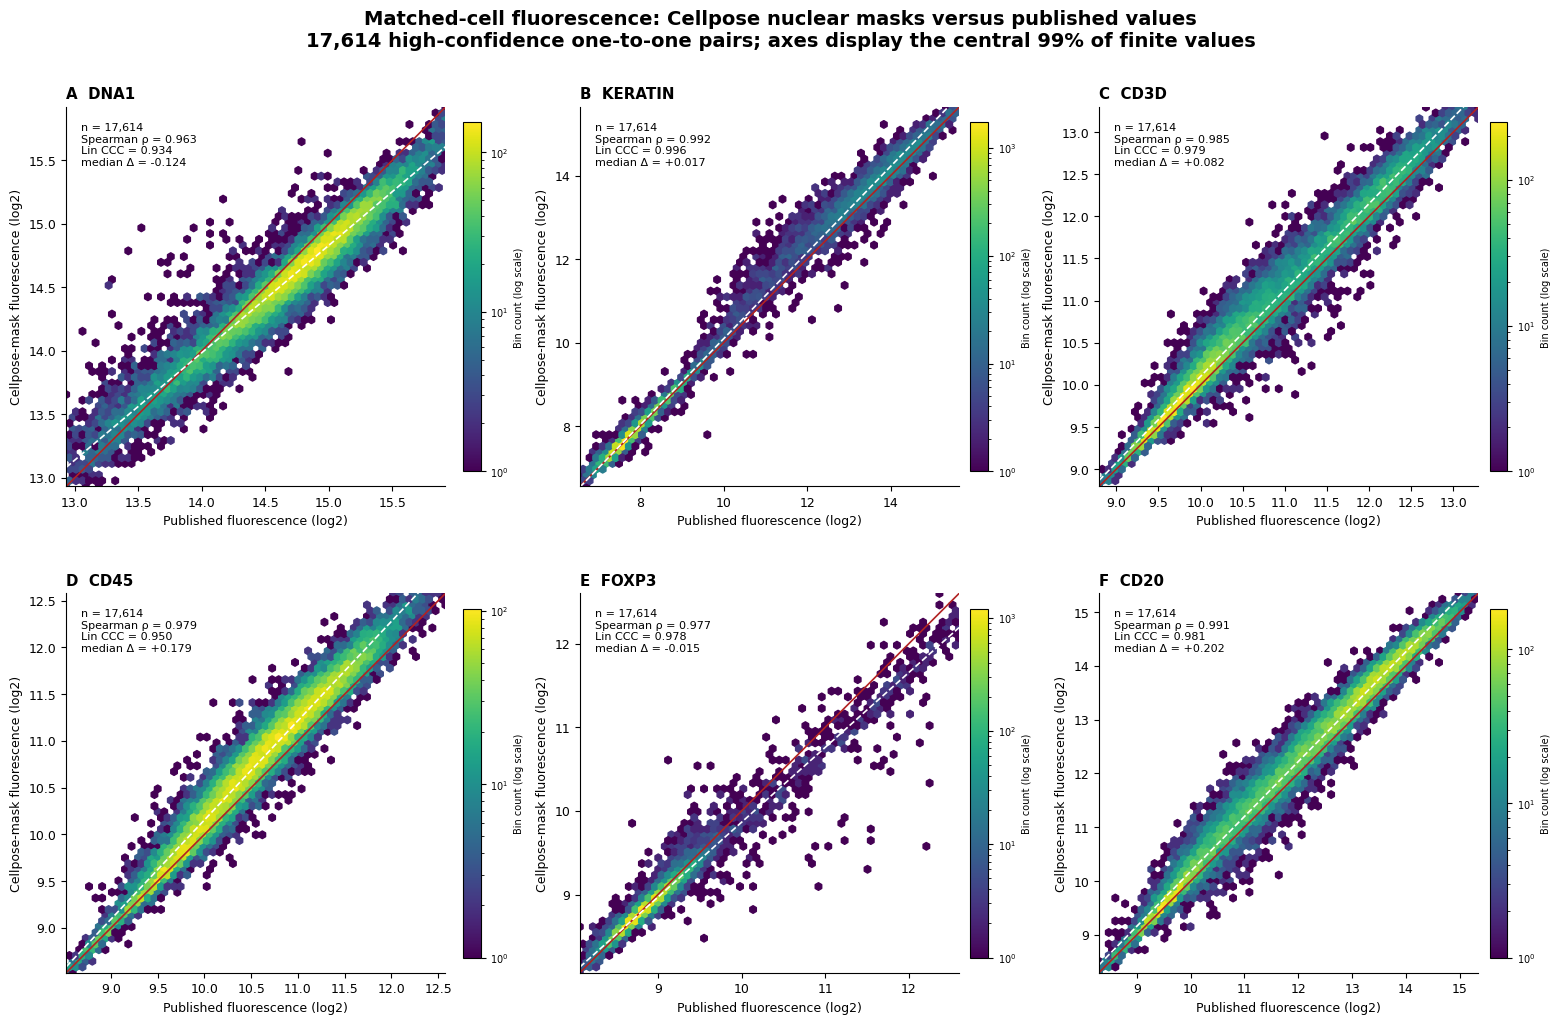

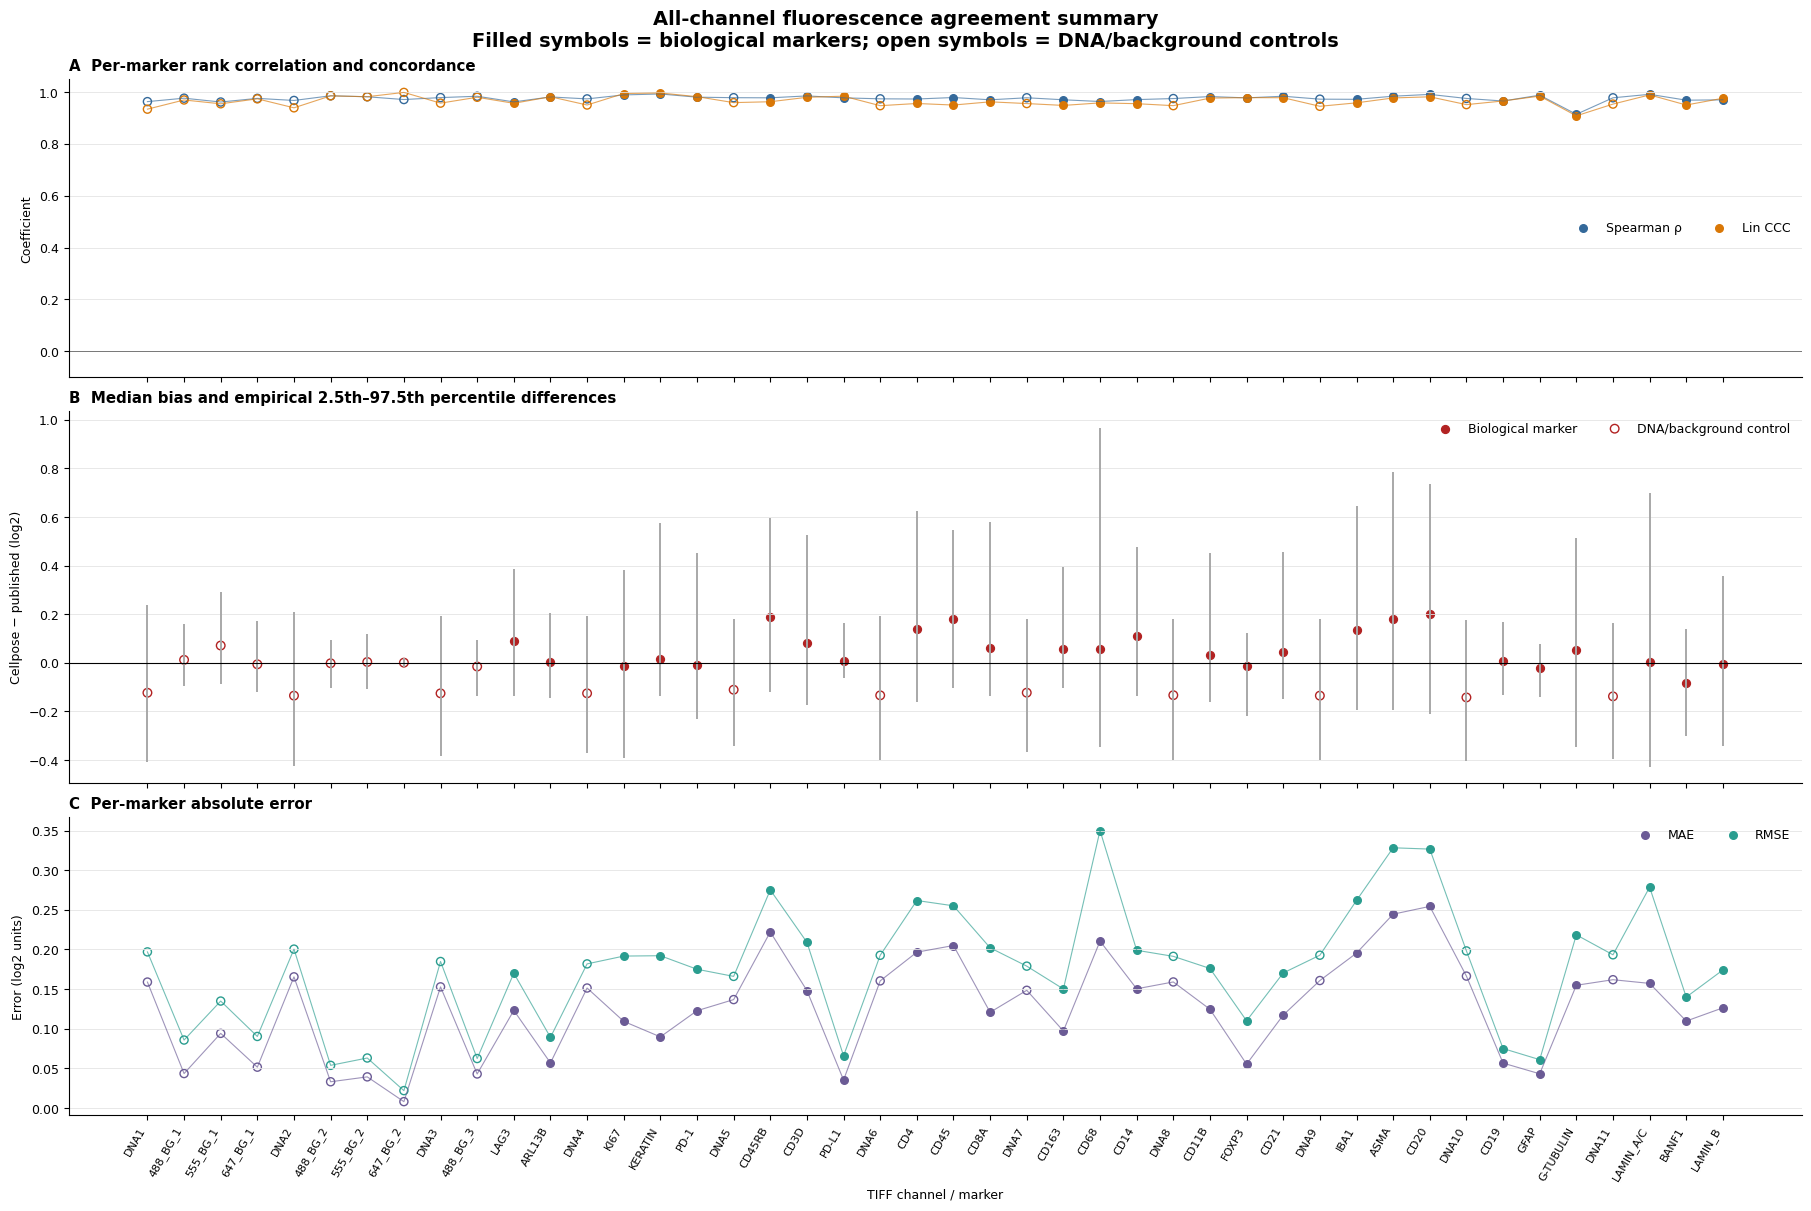

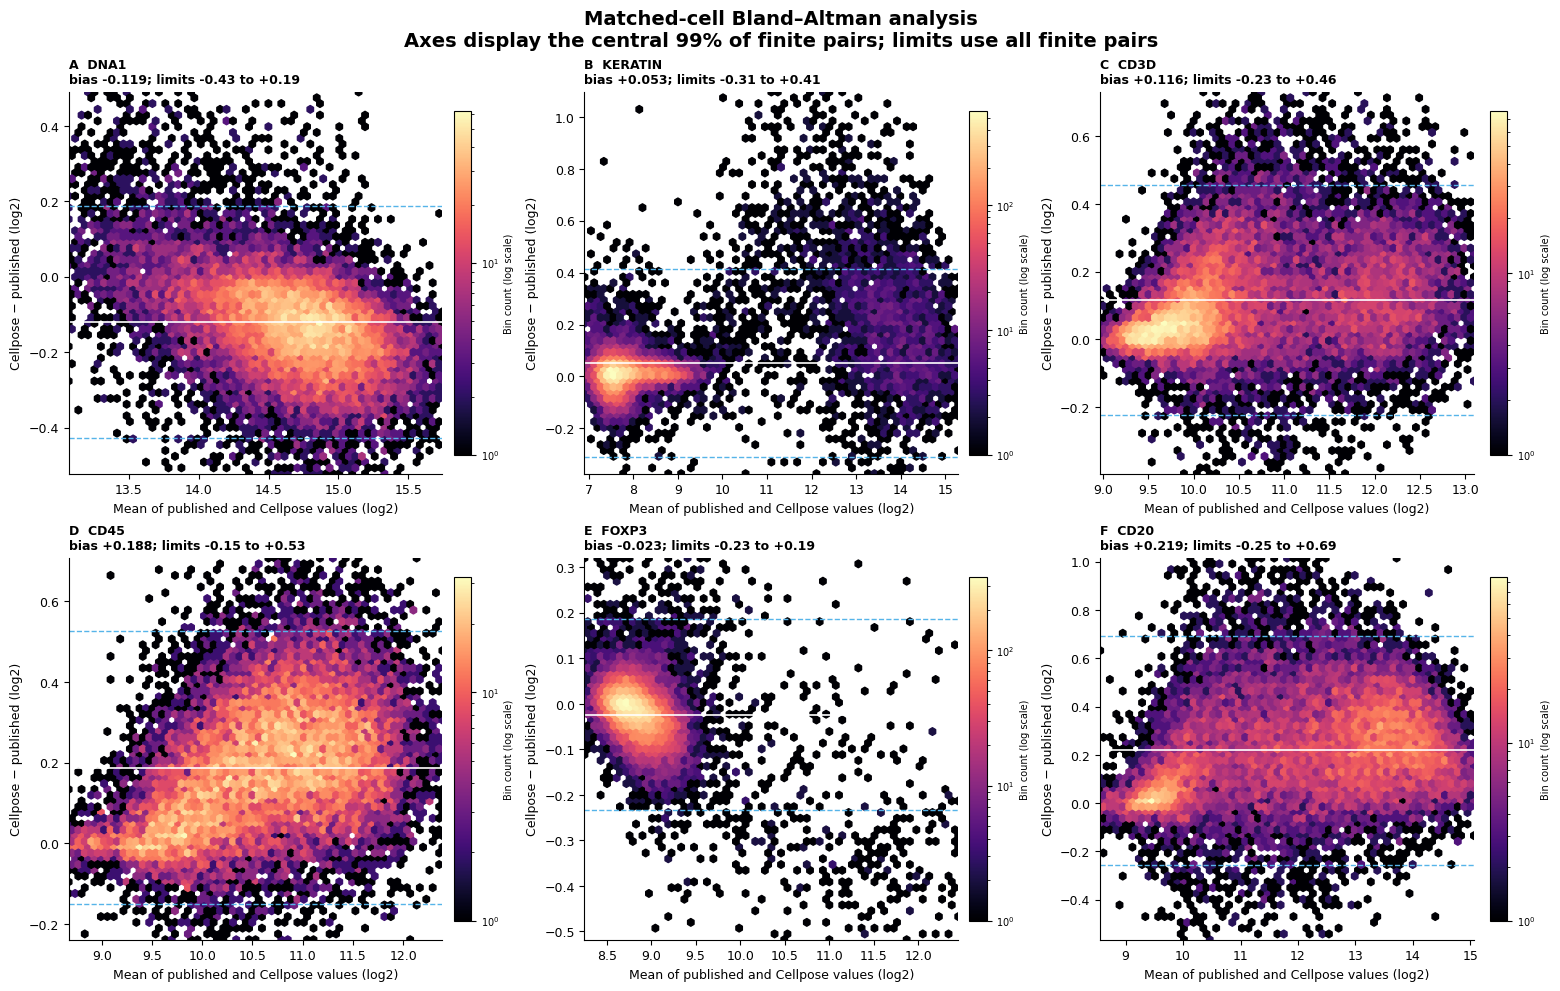


CELL 4 COMPLETED SUCCESSFULLY
Published scale         : natural_log
Primary matched pairs   : 17,614
Markers evaluated       : 44
Elapsed time            : 0.43 min

Paired values CSV  : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell4_matched_fluorescence_pairs.csv
Marker metrics CSV : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell4_marker_concordance_metrics.csv
Manifest          : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell4_fluorescence_concordance_manifest.json
Scatter figure    : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell4_selected_marker_scatter.png
Summary figure    : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell4_marker_concordance_summary.png
Bland–Altman figure: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellp

In [ ]:
# ============================================================
# CELL 4 — Cellpose vs published fluorescence concordance
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import hashlib
import json
import re
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ROOT = Path(
    "/content/drive/MyDrive/CyCIF_validation/"
    "TONSIL-1_40X_Field_01_01"
)
RUN_DIR = ROOT / "cellpose_vs_published_v1"

PUBLISHED_CSV = ROOT / "TONSIL-1_40X_Field_01_01.csv"
CELLPOSE_FEATURES = (
    RUN_DIR / "TONSIL-1_40X_Field_01_01_cellpose_44ch_raw_features.csv"
)
CELL3_MATCHES = RUN_DIR / "cell3_spatial_matches.csv"
CELL3_SCALE_CHANNELS = RUN_DIR / "cell3_scale_diagnostics_by_channel.csv"
CELL3_SCALE_CANDIDATES = RUN_DIR / "cell3_scale_candidate_summary.csv"
CELL3_MANIFEST = RUN_DIR / "cell3_matching_scale_manifest.json"

PAIRED_OUT = RUN_DIR / "cell4_matched_fluorescence_pairs.csv"
METRICS_OUT = RUN_DIR / "cell4_marker_concordance_metrics.csv"
MANIFEST_OUT = RUN_DIR / "cell4_fluorescence_concordance_manifest.json"

SCATTER_PNG = RUN_DIR / "cell4_selected_marker_scatter.png"
SCATTER_PDF = RUN_DIR / "cell4_selected_marker_scatter.pdf"
SUMMARY_PNG = RUN_DIR / "cell4_marker_concordance_summary.png"
SUMMARY_PDF = RUN_DIR / "cell4_marker_concordance_summary.pdf"
BLAND_ALTMAN_PNG = RUN_DIR / "cell4_selected_marker_bland_altman.png"
BLAND_ALTMAN_PDF = RUN_DIR / "cell4_selected_marker_bland_altman.pdf"

required_files = [
    PUBLISHED_CSV,
    CELLPOSE_FEATURES,
    CELL3_MATCHES,
    CELL3_SCALE_CHANNELS,
    CELL3_SCALE_CANDIDATES,
    CELL3_MANIFEST,
]
for required in required_files:
    if not required.exists():
        raise FileNotFoundError(
            f"Missing required input: {required}\n"
            "Run the revised CELL 3 successfully before CELL 4."
        )


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def sha256_file(path, block_bytes=16 * 1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            block = handle.read(block_bytes)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def as_boolean(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)
    normalized = series.astype(str).str.strip().str.lower()
    allowed = {"true", "false", "1", "0", "yes", "no"}
    unexpected = sorted(set(normalized.dropna()) - allowed)
    if unexpected:
        raise ValueError(
            f"Cannot interpret boolean values in {series.name}: {unexpected}"
        )
    return normalized.isin({"true", "1", "yes"})


def safe_marker_name(channel_number, marker):
    safe = re.sub(r"[^A-Za-z0-9]+", "_", str(marker)).strip("_")
    return f"C{int(channel_number):02d}_{safe}"


def lin_concordance_correlation(x, y):
    """Lin's CCC, calculated with population moments."""
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    var_x = np.mean((x - mean_x) ** 2)
    var_y = np.mean((y - mean_y) ** 2)
    covariance = np.mean((x - mean_x) * (y - mean_y))
    denominator = var_x + var_y + (mean_x - mean_y) ** 2
    if denominator == 0:
        return np.nan
    return float(2.0 * covariance / denominator)


def correlation_or_nan(x, y, method):
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    if method == "pearson":
        return float(np.corrcoef(x, y)[0, 1])
    if method == "spearman":
        return float(spearmanr(x, y).statistic)
    raise ValueError(method)


start = time.time()


# ------------------------------------------------------------
# Gate on the independently resolved CELL 3 result.
# ------------------------------------------------------------
print("=" * 78)
print("CELL 4 — VERIFY CELL 3")
print("=" * 78)

with open(CELL3_MANIFEST, "r", encoding="utf-8") as handle:
    cell3_manifest = json.load(handle)

selected_scale = str(
    cell3_manifest.get("selected_published_scale", "UNDETERMINED")
)
scale_resolved = bool(cell3_manifest.get("scale_resolved", False))

if not scale_resolved or selected_scale == "UNDETERMINED":
    raise RuntimeError(
        "CELL 3 did not resolve the published logarithm scale. "
        "Do not compute fluorescence concordance yet. Send the CELL 3 "
        "scale output and QC figure for review."
    )

scale_candidates = pd.read_csv(CELL3_SCALE_CANDIDATES)
selected_candidate = scale_candidates.loc[
    scale_candidates["CandidateScale"].astype(str) == selected_scale
]
if len(selected_candidate) != 1:
    raise ValueError(
        f"Could not find exactly one candidate row for scale '{selected_scale}'."
    )

published_log_base = float(selected_candidate.iloc[0]["Base"])
published_to_log2_factor = float(np.log2(published_log_base))

print("CELL 3 coordinate convention :", cell3_manifest["coordinate_convention"])
print("CELL 3 published scale       :", selected_scale)
print("Published logarithm base     :", f"{published_log_base:.8f}")
print("Published-to-log2 multiplier :", f"{published_to_log2_factor:.8f}")


# ------------------------------------------------------------
# Load the explicit one-to-one match table.
# Primary analysis: high-confidence pairs, excluding border objects.
# ------------------------------------------------------------
matches = pd.read_csv(CELL3_MATCHES, low_memory=False)

required_match_columns = {
    "CellposeID", "PublishedCellId", "CentroidDistance_px",
    "CellposeArea_px", "PublishedArea_px",
    "CellposeToPublishedAreaRatio", "HighConfidence",
    "CellposeTouchesBorder",
}
if not required_match_columns.issubset(matches.columns):
    missing = sorted(required_match_columns.difference(matches.columns))
    raise ValueError(f"CELL 3 match table is missing columns: {missing}")

matches["HighConfidence"] = as_boolean(matches["HighConfidence"])
matches["CellposeTouchesBorder"] = as_boolean(
    matches["CellposeTouchesBorder"]
)

for column in [
    "CellposeID", "PublishedCellId", "CentroidDistance_px",
    "CellposeArea_px", "PublishedArea_px",
    "CellposeToPublishedAreaRatio",
]:
    matches[column] = pd.to_numeric(matches[column], errors="raise")

if matches["CellposeID"].duplicated().any():
    raise ValueError("Mutual match table contains duplicated Cellpose IDs.")
if matches["PublishedCellId"].duplicated().any():
    raise ValueError("Mutual match table contains duplicated published IDs.")

high_confidence_all = matches.loc[matches["HighConfidence"]].copy()
border_excluded_count = int(
    high_confidence_all["CellposeTouchesBorder"].sum()
)
primary_matches = high_confidence_all.loc[
    ~high_confidence_all["CellposeTouchesBorder"]
].copy()
primary_matches = primary_matches.sort_values("CellposeID").reset_index(drop=True)

if len(primary_matches) < 1_000:
    raise RuntimeError(
        f"Only {len(primary_matches):,} primary pairs remain. "
        "Stop and review CELL 3 matching."
    )

manifest_high_confidence = int(
    cell3_manifest.get("high_confidence_pair_count", -1)
)
if manifest_high_confidence != len(high_confidence_all):
    raise ValueError(
        "High-confidence pair count disagrees with CELL 3 manifest: "
        f"{len(high_confidence_all):,} versus {manifest_high_confidence:,}."
    )

print("\nHigh-confidence pairs        :", f"{len(high_confidence_all):,}")
print("Border pairs excluded        :", f"{border_excluded_count:,}")
print("Primary analysis pairs       :", f"{len(primary_matches):,}")
print(
    "Median centroid distance    :",
    f"{primary_matches['CentroidDistance_px'].median():.3f} px",
)
print(
    "Median area ratio CP/pub    :",
    f"{primary_matches['CellposeToPublishedAreaRatio'].median():.3f}",
)


# ------------------------------------------------------------
# Load only required fluorescence columns from the two raw tables.
# ------------------------------------------------------------
scale_map = pd.read_csv(CELL3_SCALE_CHANNELS)
required_scale_columns = {
    "ChannelNumber_1based", "Marker", "CellposeFeatureColumn",
    "PublishedFeatureColumn",
}
if not required_scale_columns.issubset(scale_map.columns):
    missing = sorted(required_scale_columns.difference(scale_map.columns))
    raise ValueError(f"CELL 3 scale table is missing columns: {missing}")

scale_map = scale_map.sort_values("ChannelNumber_1based").reset_index(drop=True)
if len(scale_map) != 44:
    raise ValueError(f"Expected 44 channel rows; found {len(scale_map)}")
if scale_map["ChannelNumber_1based"].tolist() != list(range(1, 45)):
    raise ValueError("Channel numbers are not the expected sequence 1...44.")

cp_feature_columns = scale_map["CellposeFeatureColumn"].astype(str).tolist()
pub_feature_columns = scale_map["PublishedFeatureColumn"].astype(str).tolist()

cellpose = pd.read_csv(
    CELLPOSE_FEATURES,
    usecols=["CellposeID"] + cp_feature_columns,
    low_memory=False,
)
published = pd.read_csv(
    PUBLISHED_CSV,
    usecols=["CellId"] + pub_feature_columns,
    low_memory=False,
)

cellpose["CellposeID"] = pd.to_numeric(
    cellpose["CellposeID"], errors="raise"
).astype(np.int64)
published["CellId"] = pd.to_numeric(
    published["CellId"], errors="raise"
).astype(np.int64)

if cellpose["CellposeID"].duplicated().any():
    raise ValueError("Cellpose feature table has duplicate CellposeID values.")
if published["CellId"].duplicated().any():
    raise ValueError("Published table has duplicate CellId values.")

cellpose_by_id = cellpose.set_index("CellposeID", verify_integrity=True)
published_by_id = published.set_index("CellId", verify_integrity=True)

cp_ids = primary_matches["CellposeID"].to_numpy(np.int64)
pub_ids = primary_matches["PublishedCellId"].to_numpy(np.int64)

missing_cp_ids = np.setdiff1d(cp_ids, cellpose_by_id.index.to_numpy())
missing_pub_ids = np.setdiff1d(pub_ids, published_by_id.index.to_numpy())
if len(missing_cp_ids) or len(missing_pub_ids):
    raise ValueError(
        f"Missing matched IDs: Cellpose={len(missing_cp_ids)}, "
        f"published={len(missing_pub_ids)}"
    )

cp_rows = cellpose_by_id.loc[cp_ids]
pub_rows = published_by_id.loc[pub_ids]


# ------------------------------------------------------------
# Calculate paired values and marker-level metrics.
# No thresholding or marker-specific tuning is performed.
# ------------------------------------------------------------
paired_data = {
    "AnalysisPairID": np.arange(1, len(primary_matches) + 1, dtype=np.int64),
    "CellposeID": cp_ids,
    "PublishedCellId": pub_ids,
    "CentroidDistance_px": primary_matches["CentroidDistance_px"].to_numpy(np.float64),
    "CellposeArea_px": primary_matches["CellposeArea_px"].to_numpy(np.float64),
    "PublishedArea_px": primary_matches["PublishedArea_px"].to_numpy(np.float64),
    "CellposeToPublishedAreaRatio": primary_matches[
        "CellposeToPublishedAreaRatio"
    ].to_numpy(np.float64),
}

metric_rows = []

print("\n" + "=" * 78)
print("44-CHANNEL FLUORESCENCE CONCORDANCE")
print("=" * 78)

for _, mapping in scale_map.iterrows():
    channel_number = int(mapping["ChannelNumber_1based"])
    marker = str(mapping["Marker"])
    cp_column = str(mapping["CellposeFeatureColumn"])
    pub_column = str(mapping["PublishedFeatureColumn"])
    prefix = safe_marker_name(channel_number, marker)

    cp_raw = pd.to_numeric(cp_rows[cp_column], errors="coerce").to_numpy(np.float64)
    pub_native = pd.to_numeric(pub_rows[pub_column], errors="coerce").to_numpy(np.float64)

    with np.errstate(divide="ignore", invalid="ignore"):
        cp_log2 = np.log2(cp_raw)
        pub_log2 = pub_native * published_to_log2_factor

    paired_data[f"CellposeRawMean__{prefix}"] = cp_raw
    paired_data[f"PublishedNative__{prefix}"] = pub_native
    paired_data[f"CellposeLog2__{prefix}"] = cp_log2
    paired_data[f"PublishedLog2__{prefix}"] = pub_log2

    finite = np.isfinite(cp_log2) & np.isfinite(pub_log2)
    x = pub_log2[finite]
    y = cp_log2[finite]

    pearson_r = correlation_or_nan(x, y, "pearson")
    spearman_r = correlation_or_nan(x, y, "spearman")
    ccc = lin_concordance_correlation(x, y) if len(x) >= 3 else np.nan

    if len(x) >= 3 and np.std(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
    else:
        slope, intercept = np.nan, np.nan

    if len(x):
        difference = y - x
        mean_bias = float(np.mean(difference))
        median_bias = float(np.median(difference))
        difference_sd = float(np.std(difference, ddof=1)) if len(x) > 1 else np.nan
        loa_lower = mean_bias - 1.96 * difference_sd
        loa_upper = mean_bias + 1.96 * difference_sd
        difference_p025, difference_p975 = np.percentile(difference, [2.5, 97.5])
        mae = float(np.mean(np.abs(difference)))
        rmse = float(np.sqrt(np.mean(difference ** 2)))
        within_0p25 = float(100 * np.mean(np.abs(difference) <= 0.25))
        within_0p50 = float(100 * np.mean(np.abs(difference) <= 0.50))
        within_1p00 = float(100 * np.mean(np.abs(difference) <= 1.00))
        median_published = float(np.median(x))
        median_cellpose = float(np.median(y))
    else:
        mean_bias = median_bias = difference_sd = np.nan
        loa_lower = loa_upper = np.nan
        difference_p025 = difference_p975 = np.nan
        mae = rmse = np.nan
        within_0p25 = within_0p50 = within_1p00 = np.nan
        median_published = median_cellpose = np.nan

    valid_zero_status = (
        (~np.isnan(pub_native))
        & np.isfinite(cp_raw)
        & (cp_raw >= 0)
    )
    if valid_zero_status.any():
        published_zero = np.isneginf(pub_native[valid_zero_status])
        cellpose_zero = cp_raw[valid_zero_status] == 0
        zero_status_agreement = float(
            100 * np.mean(published_zero == cellpose_zero)
        )
    else:
        zero_status_agreement = np.nan

    marker_upper = marker.upper()
    is_control = bool(
        marker_upper.startswith("DNA") or "_BG_" in marker_upper
    )

    metric_rows.append({
        "ChannelNumber_1based": channel_number,
        "Marker": marker,
        "BiologicalMarker": not is_control,
        "CellposeFeatureColumn": cp_column,
        "PublishedFeatureColumn": pub_column,
        "PrimaryMatchedPairs": int(len(primary_matches)),
        "FiniteLog2Pairs": int(len(x)),
        "PearsonR": pearson_r,
        "SpearmanRho": spearman_r,
        "LinCCC": ccc,
        "OLSSlope_CellposeOnPublished": float(slope),
        "OLSIntercept_log2": float(intercept),
        "PublishedMedian_log2": median_published,
        "CellposeMedian_log2": median_cellpose,
        "MeanBias_CellposeMinusPublished_log2": mean_bias,
        "MedianBias_CellposeMinusPublished_log2": median_bias,
        "DifferenceSD_log2": difference_sd,
        "BlandAltmanLower95_log2": loa_lower,
        "BlandAltmanUpper95_log2": loa_upper,
        "DifferenceP025_log2": float(difference_p025),
        "DifferenceP975_log2": float(difference_p975),
        "MAE_log2": mae,
        "RMSE_log2": rmse,
        "Within0p25log2_pct": within_0p25,
        "Within0p50log2_pct": within_0p50,
        "Within1p00log2_pct": within_1p00,
        "ZeroStatusAgreement_pct": zero_status_agreement,
    })

    print(
        f"[{channel_number:02d}/44] {marker:<12} "
        f"n={len(x):>6,}  rho={spearman_r:7.3f}  "
        f"CCC={ccc:7.3f}  bias={median_bias:+7.3f}  MAE={mae:7.3f}"
    )


paired = pd.DataFrame(paired_data)
metrics = pd.DataFrame(metric_rows)

paired.to_csv(PAIRED_OUT, index=False, float_format="%.10g")
metrics.to_csv(METRICS_OUT, index=False, float_format="%.10g")


# ------------------------------------------------------------
# Compact save verification.
# ------------------------------------------------------------
saved_pair_ids = pd.read_csv(PAIRED_OUT, usecols=["AnalysisPairID"])
saved_metrics = pd.read_csv(METRICS_OUT)

if len(saved_pair_ids) != len(primary_matches):
    raise ValueError("Saved paired table row count is incorrect.")
if len(saved_metrics) != 44:
    raise ValueError("Saved marker metrics table does not have 44 rows.")
if saved_metrics["Marker"].astype(str).tolist() != scale_map["Marker"].astype(str).tolist():
    raise ValueError("Saved marker order does not match the channel map.")


# ------------------------------------------------------------
# Summary statistics. These describe agreement; they are not
# automatically converted into a pass/fail validation claim.
# ------------------------------------------------------------
biological = metrics.loc[
    metrics["BiologicalMarker"] & (metrics["FiniteLog2Pairs"] >= 100)
].copy()

if biological.empty:
    raise RuntimeError("No biological marker has at least 100 finite pairs.")

print("\n" + "=" * 78)
print("CELLPOSE-vs-PUBLISHED SUMMARY")
print("=" * 78)
print("Published scale             :", selected_scale)
print("Primary matched pairs       :", f"{len(primary_matches):,}")
print("Biological markers assessed :", f"{len(biological):,}")
print("Median biological Spearman  :", f"{biological['SpearmanRho'].median():.4f}")
print("Median biological Lin CCC   :", f"{biological['LinCCC'].median():.4f}")
print("Median biological bias      :", f"{biological['MedianBias_CellposeMinusPublished_log2'].median():+.4f} log2")
print("Median biological MAE       :", f"{biological['MAE_log2'].median():.4f} log2")
print("Median within 0.5 log2      :", f"{biological['Within0p50log2_pct'].median():.2f}%")
print("Median within 1.0 log2      :", f"{biological['Within1p00log2_pct'].median():.2f}%")

lowest_ccc = biological.sort_values("LinCCC").head(10)
print("\nTEN BIOLOGICAL MARKERS WITH LOWEST LIN CCC")
print("-------------------------------------------")
print(
    lowest_ccc[
        [
            "ChannelNumber_1based", "Marker", "FiniteLog2Pairs",
            "SpearmanRho", "LinCCC",
            "MedianBias_CellposeMinusPublished_log2", "MAE_log2",
        ]
    ].round(4).to_string(index=False)
)


# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

selected_markers = ["DNA1", "KERATIN", "CD3D", "CD45", "FOXP3", "CD20"]
if not set(selected_markers).issubset(set(metrics["Marker"])):
    missing = sorted(set(selected_markers) - set(metrics["Marker"]))
    raise ValueError(f"Selected figure markers are missing: {missing}")


# ------------------------------------------------------------
# Figure 4A: matched-cell fluorescence scatter plots
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15.5, 10.2), constrained_layout=True)

for ax, marker in zip(axes.flat, selected_markers):
    metric = metrics.loc[metrics["Marker"] == marker].iloc[0]
    channel_number = int(metric["ChannelNumber_1based"])
    prefix = safe_marker_name(channel_number, marker)

    x_all = paired[f"PublishedLog2__{prefix}"].to_numpy(np.float64)
    y_all = paired[f"CellposeLog2__{prefix}"].to_numpy(np.float64)
    finite = np.isfinite(x_all) & np.isfinite(y_all)
    x = x_all[finite]
    y = y_all[finite]

    combined = np.concatenate([x, y])
    lower, upper = np.percentile(combined, [0.5, 99.5])
    if upper <= lower:
        lower, upper = float(combined.min()), float(combined.max() + 1)
    padding = 0.04 * (upper - lower)
    plot_lower, plot_upper = lower - padding, upper + padding

    hb = ax.hexbin(
        x, y,
        gridsize=58,
        mincnt=1,
        bins="log",
        cmap="viridis",
        extent=(plot_lower, plot_upper, plot_lower, plot_upper),
    )
    ax.plot(
        [plot_lower, plot_upper], [plot_lower, plot_upper],
        color="#B22222", linewidth=1.2, label="Identity",
    )

    slope = float(metric["OLSSlope_CellposeOnPublished"])
    intercept = float(metric["OLSIntercept_log2"])
    if np.isfinite(slope) and np.isfinite(intercept):
        line_x = np.array([plot_lower, plot_upper])
        ax.plot(
            line_x, intercept + slope * line_x,
            color="white", linewidth=1.2, linestyle="--", label="OLS",
        )

    ax.set_xlim(plot_lower, plot_upper)
    ax.set_ylim(plot_lower, plot_upper)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Published fluorescence (log2)")
    ax.set_ylabel("Cellpose-mask fluorescence (log2)")
    ax.set_title(
        f"{chr(65 + selected_markers.index(marker))}  {marker}",
        loc="left", fontweight="bold",
    )
    ax.text(
        0.04, 0.96,
        f"n = {int(metric['FiniteLog2Pairs']):,}\n"
        f"Spearman ρ = {metric['SpearmanRho']:.3f}\n"
        f"Lin CCC = {metric['LinCCC']:.3f}\n"
        f"median Δ = {metric['MedianBias_CellposeMinusPublished_log2']:+.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=8,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.86, "edgecolor": "none"},
    )
    colorbar = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.03)
    colorbar.set_label("Bin count (log scale)", fontsize=7)
    colorbar.ax.tick_params(labelsize=7)

fig.suptitle(
    "Matched-cell fluorescence: Cellpose nuclear masks versus published values\n"
    f"{len(primary_matches):,} high-confidence one-to-one pairs; "
    "axes display the central 99% of finite values",
    fontsize=14,
    fontweight="bold",
)
fig.savefig(SCATTER_PNG, dpi=240, bbox_inches="tight")
fig.savefig(SCATTER_PDF, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 4B: all-marker concordance and bias summary
# ------------------------------------------------------------
x_position = metrics["ChannelNumber_1based"].to_numpy(np.int64)
marker_labels = metrics["Marker"].astype(str).tolist()
bio_flag = metrics["BiologicalMarker"].to_numpy(bool)

fig, axes = plt.subplots(
    3, 1, figsize=(18, 12), sharex=True,
    gridspec_kw={"height_ratios": [1.0, 1.25, 1.0]},
    constrained_layout=True,
)

# A: rank and concordance
ax = axes[0]
ax.plot(x_position, metrics["SpearmanRho"], color="#34699A", linewidth=0.8, alpha=0.65)
ax.plot(x_position, metrics["LinCCC"], color="#D97706", linewidth=0.8, alpha=0.65)
ax.scatter(x_position[bio_flag], metrics.loc[bio_flag, "SpearmanRho"], s=30, color="#34699A", label="Spearman ρ")
ax.scatter(x_position[bio_flag], metrics.loc[bio_flag, "LinCCC"], s=30, color="#D97706", label="Lin CCC")
ax.scatter(x_position[~bio_flag], metrics.loc[~bio_flag, "SpearmanRho"], s=34, facecolors="none", edgecolors="#34699A")
ax.scatter(x_position[~bio_flag], metrics.loc[~bio_flag, "LinCCC"], s=34, facecolors="none", edgecolors="#D97706")
ax.axhline(0, color="#777777", linewidth=0.7)
ax.set_ylabel("Coefficient")
ax.set_ylim(-0.10, 1.05)
ax.set_title("A  Per-marker rank correlation and concordance", loc="left", fontweight="bold")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", color="#E4E4E4", linewidth=0.6)

# B: bias and empirical central 95% differences
ax = axes[1]
lower = metrics["DifferenceP025_log2"].to_numpy(np.float64)
upper = metrics["DifferenceP975_log2"].to_numpy(np.float64)
median_bias = metrics["MedianBias_CellposeMinusPublished_log2"].to_numpy(np.float64)
ax.vlines(x_position, lower, upper, color="#A8A8A8", linewidth=1.4)
ax.scatter(x_position[bio_flag], median_bias[bio_flag], s=32, color="#B22222", label="Biological marker")
ax.scatter(x_position[~bio_flag], median_bias[~bio_flag], s=38, facecolors="none", edgecolors="#B22222", label="DNA/background control")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cellpose − published (log2)")
ax.set_title("B  Median bias and empirical 2.5th–97.5th percentile differences", loc="left", fontweight="bold")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", color="#E4E4E4", linewidth=0.6)

# C: absolute error
ax = axes[2]
ax.plot(x_position, metrics["MAE_log2"], color="#6B5B95", linewidth=0.8, alpha=0.65)
ax.plot(x_position, metrics["RMSE_log2"], color="#2A9D8F", linewidth=0.8, alpha=0.65)
ax.scatter(x_position[bio_flag], metrics.loc[bio_flag, "MAE_log2"], s=30, color="#6B5B95", label="MAE")
ax.scatter(x_position[bio_flag], metrics.loc[bio_flag, "RMSE_log2"], s=30, color="#2A9D8F", label="RMSE")
ax.scatter(x_position[~bio_flag], metrics.loc[~bio_flag, "MAE_log2"], s=34, facecolors="none", edgecolors="#6B5B95")
ax.scatter(x_position[~bio_flag], metrics.loc[~bio_flag, "RMSE_log2"], s=34, facecolors="none", edgecolors="#2A9D8F")
ax.set_ylabel("Error (log2 units)")
ax.set_title("C  Per-marker absolute error", loc="left", fontweight="bold")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", color="#E4E4E4", linewidth=0.6)

axes[-1].set_xticks(x_position)
axes[-1].set_xticklabels(marker_labels, rotation=60, ha="right", fontsize=8)
axes[-1].set_xlabel("TIFF channel / marker")

fig.suptitle(
    "All-channel fluorescence agreement summary\n"
    "Filled symbols = biological markers; open symbols = DNA/background controls",
    fontsize=14,
    fontweight="bold",
)
fig.savefig(SUMMARY_PNG, dpi=240, bbox_inches="tight")
fig.savefig(SUMMARY_PDF, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Figure 4C: selected-marker Bland–Altman plots
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.8), constrained_layout=True)

for ax, marker in zip(axes.flat, selected_markers):
    metric = metrics.loc[metrics["Marker"] == marker].iloc[0]
    channel_number = int(metric["ChannelNumber_1based"])
    prefix = safe_marker_name(channel_number, marker)

    x_all = paired[f"PublishedLog2__{prefix}"].to_numpy(np.float64)
    y_all = paired[f"CellposeLog2__{prefix}"].to_numpy(np.float64)
    finite = np.isfinite(x_all) & np.isfinite(y_all)
    x = x_all[finite]
    y = y_all[finite]

    pair_mean = (x + y) / 2.0
    difference = y - x

    mean_low, mean_high = np.percentile(pair_mean, [0.5, 99.5])
    diff_low, diff_high = np.percentile(difference, [0.5, 99.5])
    if mean_high <= mean_low:
        mean_high = mean_low + 1
    if diff_high <= diff_low:
        diff_high = diff_low + 1

    hb = ax.hexbin(
        pair_mean, difference,
        gridsize=58,
        mincnt=1,
        bins="log",
        cmap="magma",
        extent=(mean_low, mean_high, diff_low, diff_high),
    )
    ax.axhline(
        metric["MeanBias_CellposeMinusPublished_log2"],
        color="white", linewidth=1.2, label="Mean bias",
    )
    ax.axhline(
        metric["BlandAltmanLower95_log2"],
        color="#56B4E9", linewidth=1.0, linestyle="--", label="Mean ± 1.96 SD",
    )
    ax.axhline(
        metric["BlandAltmanUpper95_log2"],
        color="#56B4E9", linewidth=1.0, linestyle="--",
    )
    ax.set_xlim(mean_low, mean_high)
    ax.set_ylim(diff_low, diff_high)
    ax.set_xlabel("Mean of published and Cellpose values (log2)")
    ax.set_ylabel("Cellpose − published (log2)")
    ax.set_title(
        f"{chr(65 + selected_markers.index(marker))}  {marker}\n"
        f"bias {metric['MeanBias_CellposeMinusPublished_log2']:+.3f}; "
        f"limits {metric['BlandAltmanLower95_log2']:+.2f} to "
        f"{metric['BlandAltmanUpper95_log2']:+.2f}",
        loc="left", fontweight="bold", fontsize=9,
    )
    colorbar = fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.03)
    colorbar.set_label("Bin count (log scale)", fontsize=7)
    colorbar.ax.tick_params(labelsize=7)

fig.suptitle(
    "Matched-cell Bland–Altman analysis\n"
    "Axes display the central 99% of finite pairs; limits use all finite pairs",
    fontsize=14,
    fontweight="bold",
)
fig.savefig(BLAND_ALTMAN_PNG, dpi=240, bbox_inches="tight")
fig.savefig(BLAND_ALTMAN_PDF, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Manifest
# ------------------------------------------------------------
manifest = {
    "stage": "CELL 4 — matched-cell fluorescence concordance",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_cell3_manifest": str(CELL3_MANIFEST),
    "source_cell3_manifest_sha256": sha256_file(CELL3_MANIFEST),
    "source_cellpose_features": str(CELLPOSE_FEATURES),
    "source_published_csv": str(PUBLISHED_CSV),
    "published_scale": selected_scale,
    "published_log_base": published_log_base,
    "published_to_log2_factor": published_to_log2_factor,
    "pair_selection": {
        "required": "CELL 3 HighConfidence == True",
        "excluded": "Cellpose objects touching the image border",
        "high_confidence_before_border_exclusion": int(len(high_confidence_all)),
        "border_pairs_excluded": border_excluded_count,
        "primary_pair_count": int(len(primary_matches)),
    },
    "metric_definitions": {
        "x": "published intensity converted to log2",
        "y": "log2 of raw mean fluorescence inside Cellpose mask",
        "difference": "Cellpose minus published, in log2 units",
        "concordance": "Lin CCC using population moments",
        "limits_of_agreement": "mean difference plus/minus 1.96 sample SD",
    },
    "automatic_pass_fail_applied": False,
    "biological_marker_summary": {
        "marker_count": int(len(biological)),
        "median_spearman": float(biological["SpearmanRho"].median()),
        "median_lin_ccc": float(biological["LinCCC"].median()),
        "median_bias_log2": float(
            biological["MedianBias_CellposeMinusPublished_log2"].median()
        ),
        "median_mae_log2": float(biological["MAE_log2"].median()),
        "median_within_0p5_log2_pct": float(
            biological["Within0p50log2_pct"].median()
        ),
        "median_within_1p0_log2_pct": float(
            biological["Within1p00log2_pct"].median()
        ),
    },
    "outputs": {
        "paired_values": str(PAIRED_OUT),
        "marker_metrics": str(METRICS_OUT),
        "scatter_png": str(SCATTER_PNG),
        "scatter_pdf": str(SCATTER_PDF),
        "summary_png": str(SUMMARY_PNG),
        "summary_pdf": str(SUMMARY_PDF),
        "bland_altman_png": str(BLAND_ALTMAN_PNG),
        "bland_altman_pdf": str(BLAND_ALTMAN_PDF),
    },
}

with open(MANIFEST_OUT, "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

elapsed_minutes = (time.time() - start) / 60.0

print("\n" + "=" * 78)
print("CELL 4 COMPLETED SUCCESSFULLY")
print("=" * 78)
print("Published scale         :", selected_scale)
print("Primary matched pairs   :", f"{len(primary_matches):,}")
print("Markers evaluated       :", len(metrics))
print("Elapsed time            :", f"{elapsed_minutes:.2f} min")
print("\nPaired values CSV  :", PAIRED_OUT)
print("Marker metrics CSV :", METRICS_OUT)
print("Manifest          :", MANIFEST_OUT)
print("Scatter figure    :", SCATTER_PNG)
print("Summary figure    :", SUMMARY_PNG)
print("Bland–Altman figure:", BLAND_ALTMAN_PNG)
print("\nSend the summary, lowest-CCC table, and all three figures for review.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 4 - VERIFY CELL 3
  Published scale : natural_log (base 2.71828)
  High-confidence pairs : 17,626
  Border cells excluded : 12
  Primary pairs         : 17,614

44-CHANNEL CONCORDANCE
[01/44] DNA1         rho=0.9628  ccc=0.9337  bias=-0.119
[02/44] 488_BG_1     rho=0.9760  ccc=0.9691  bias=+0.016
[03/44] 555_BG_1     rho=0.9612  ccc=0.9544  bias=+0.078
[04/44] 647_BG_1     rho=0.9753  ccc=0.9735  bias=+0.002
[05/44] DNA2         rho=0.9672  ccc=0.9388  bias=-0.133
[06/44] 488_BG_2     rho=0.9854  ccc=0.9849  bias=-0.004
[07/44] 555_BG_2     rho=0.9815  ccc=0.9817  bias=+0.003
[08/44] 647_BG_2     rho=0.9708  ccc=0.9983  bias=+0.001
[09/44] DNA3         rho=0.9783  ccc=0.9569  bias=-0.122
[10/44] 488_BG_3     rho=0.9835  ccc=0.9796  bias=-0.018
[11/44] LAG3         rho=0.9617  ccc=0.9563  bias=+0.096
[12/44] ARL13B       rho=0.9808  ccc=0.9815  bias=+0.00

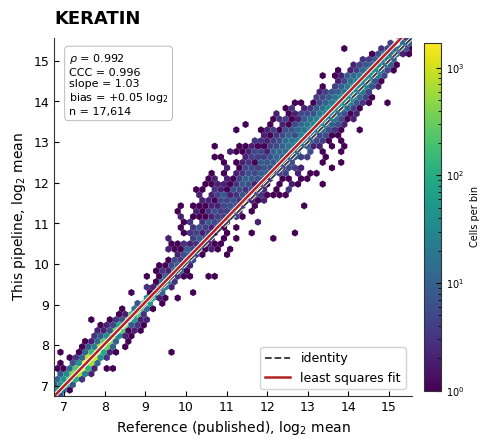

  g01_concordance_CD3D  [svg, tiff 600dpi, png 600dpi, pdf]


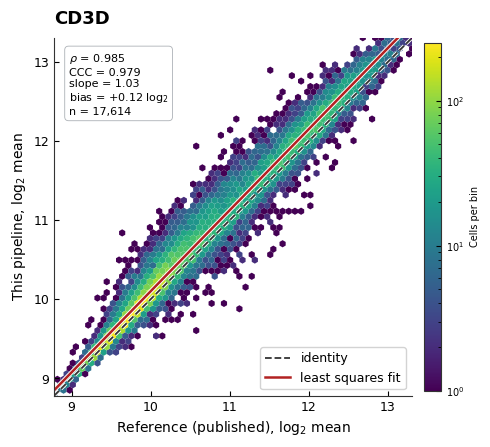

  g01_concordance_CD45  [svg, tiff 600dpi, png 600dpi, pdf]


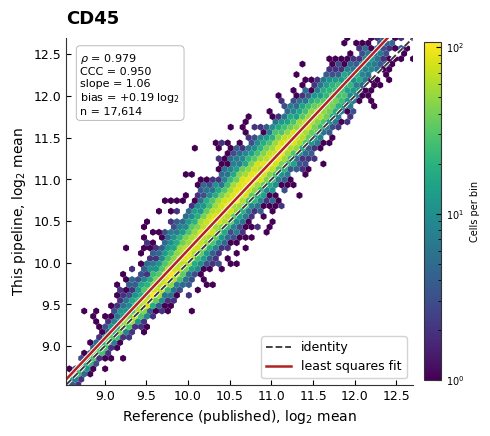

  g01_concordance_FOXP3  [svg, tiff 600dpi, png 600dpi, pdf]


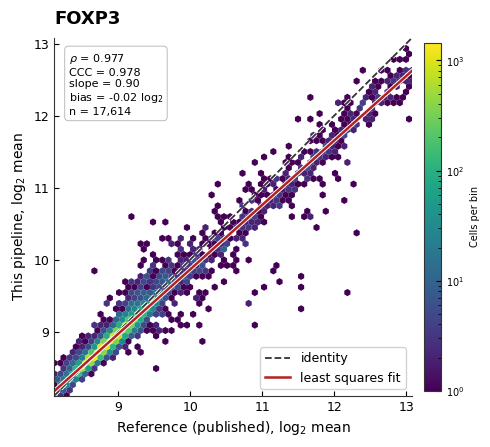

  g01_concordance_CD20  [svg, tiff 600dpi, png 600dpi, pdf]


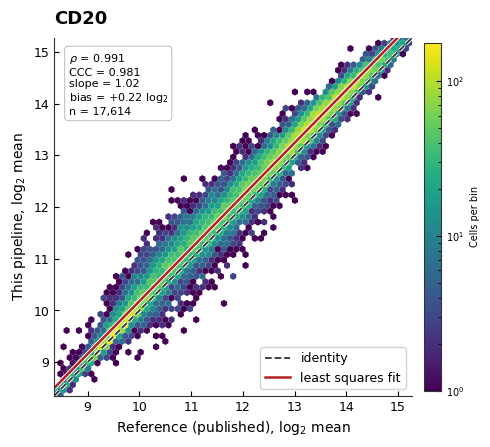

  g02_spearman_all_channels  [svg, tiff 600dpi, png 600dpi, pdf]


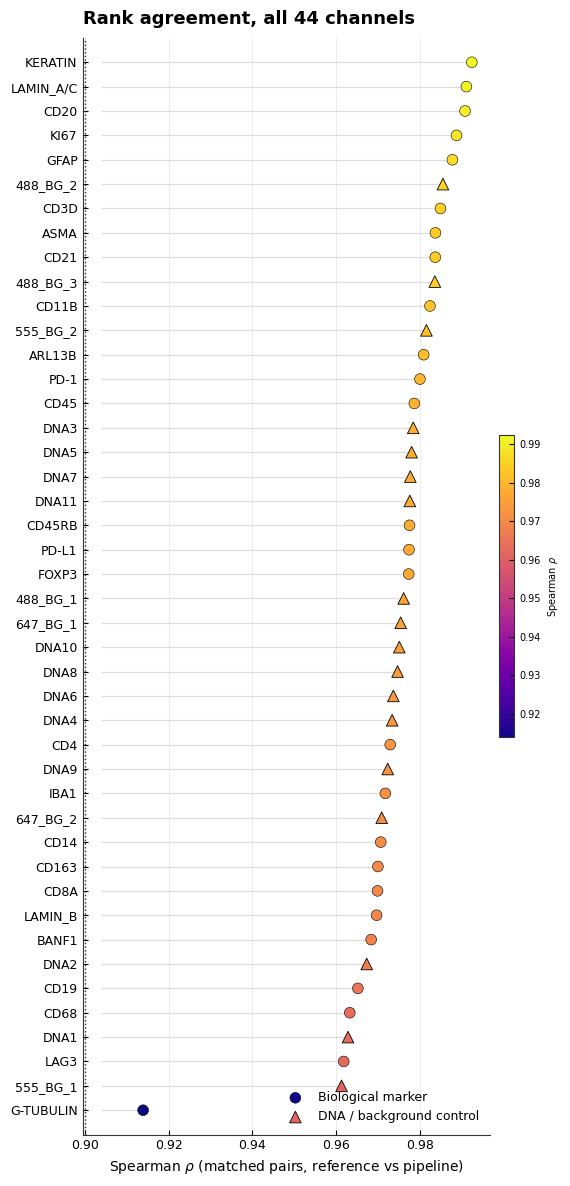

  g03_bias_ranked  [svg, tiff 600dpi, png 600dpi, pdf]


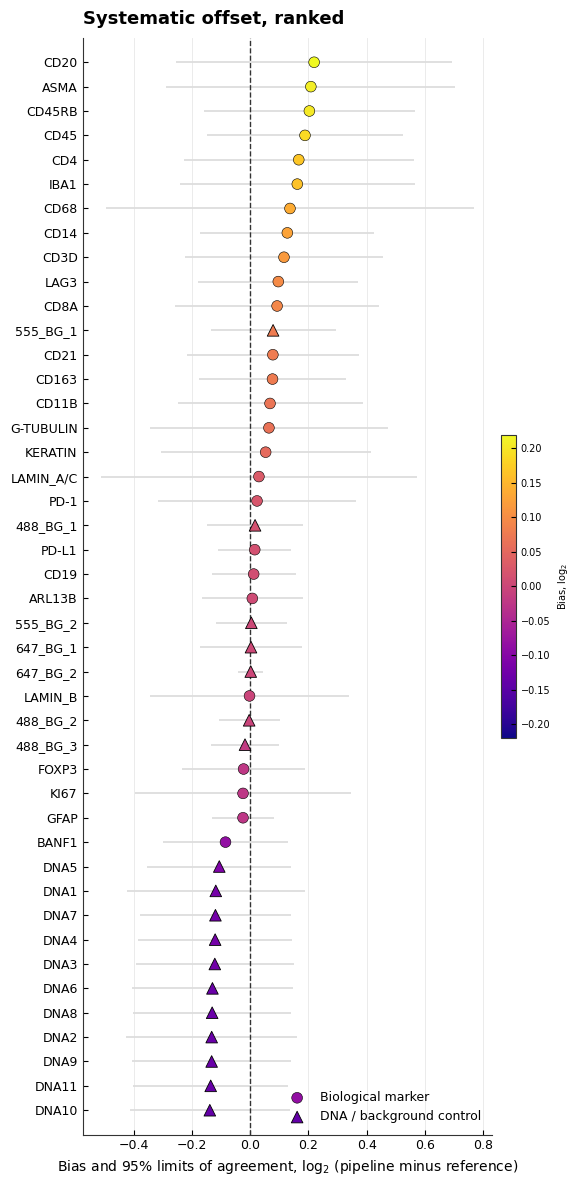

  g04_bland_altman_CD45  [svg, tiff 600dpi, png 600dpi, pdf]


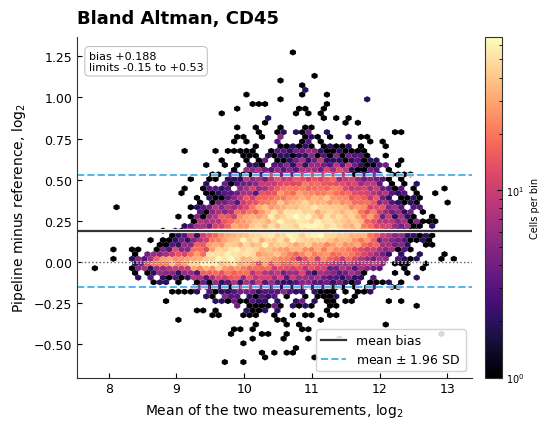

  g04_bland_altman_FOXP3  [svg, tiff 600dpi, png 600dpi, pdf]


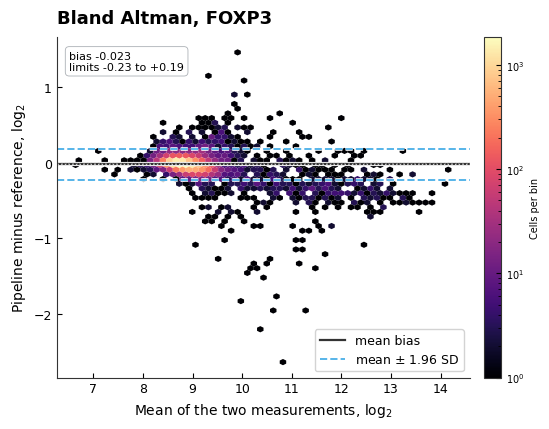

  g05_mae_ranked  [svg, tiff 600dpi, png 600dpi, pdf]


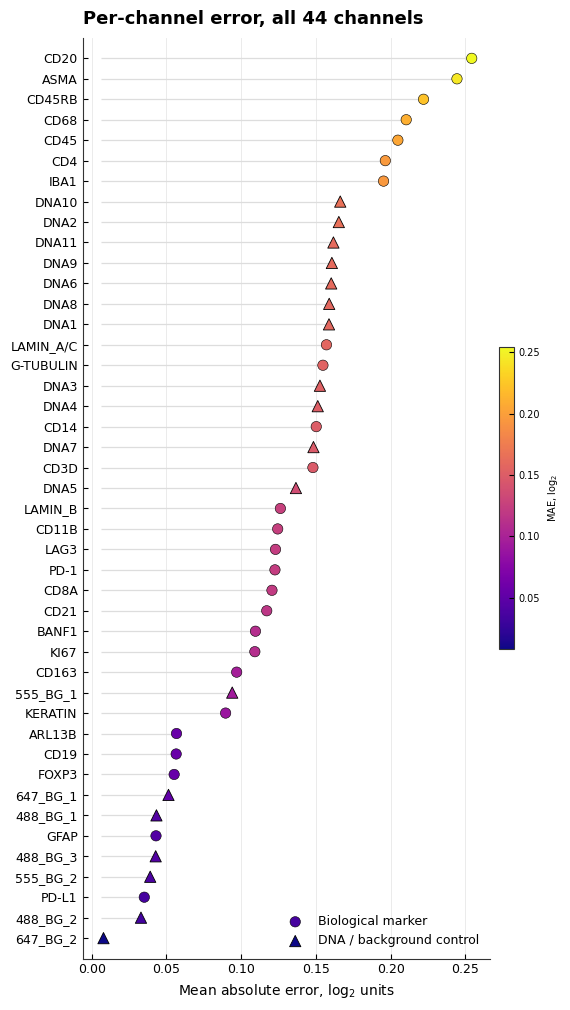


  CELL 4 COMPLETE  |  40 files  |  0.7 min
  Figures: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell4_figures_single_panel


In [ ]:
# ============================================================
# CELL 4 - Cellpose vs published fluorescence concordance
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import json
import re
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import spearmanr

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ROOT = Path("/content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01")
RUN_DIR = ROOT / "cellpose_vs_published_v1"
FIGDIR = RUN_DIR / "cell4_figures_single_panel"
FIGDIR.mkdir(parents=True, exist_ok=True)

PUBLISHED_CSV = ROOT / "TONSIL-1_40X_Field_01_01.csv"
CELLPOSE_FEATURES = RUN_DIR / "TONSIL-1_40X_Field_01_01_cellpose_44ch_raw_features.csv"
CELL3_MATCHES = RUN_DIR / "cell3_spatial_matches.csv"
CELL3_SCALE_CHANNELS = RUN_DIR / "cell3_scale_diagnostics_by_channel.csv"
CELL3_SCALE_CANDIDATES = RUN_DIR / "cell3_scale_candidate_summary.csv"
CELL3_MANIFEST = RUN_DIR / "cell3_matching_scale_manifest.json"

PAIRED_OUT = RUN_DIR / "cell4_matched_fluorescence_pairs.csv"
METRICS_OUT = RUN_DIR / "cell4_marker_concordance_metrics.csv"
MANIFEST_OUT = RUN_DIR / "cell4_fluorescence_concordance_manifest.json"

for required in (PUBLISHED_CSV, CELLPOSE_FEATURES, CELL3_MATCHES,
                 CELL3_SCALE_CHANNELS, CELL3_SCALE_CANDIDATES, CELL3_MANIFEST):
    if not required.exists():
        raise FileNotFoundError(
            f"Missing required input: {required}\nRun Cell 3 first.")


SCATTER_CMAP = "viridis"
BLAND_ALTMAN_CMAP = "magma"
RANK_CMAP = "plasma"

# Named palette, identical hex values to the HER2 / fluorescence scripts.
BLUE = "#34699A"
ORANGE = "#D97706"
BRICK_RED = "#B22222"
PURPLE = "#6B5B95"
TEAL = "#2A9D8F"
GREY = "#9AA0A6"
LIGHT_BLUE = "#56B4E9"
GRID_GREY = "#DDDDDD"
DARK_TEXT = "#222222"

IDENTITY_COLOR = "#333333"      # matches the whisker/cap grey used throughout
FIT_LINE_COLOR = BRICK_RED

DPI = 600
FS_TICK, FS_LABEL, FS_TITLE, FS_ANNOT, FS_LEGEND = 9, 10, 13, 8, 9
FS_COLORBAR = 7

matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": FS_LABEL,
    "axes.titlesize": FS_TITLE,
    "axes.titleweight": "bold",
    "axes.labelsize": FS_LABEL,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

_WRITTEN = []


def finish(fig, stem, show=True):
    """Write one standalone figure as svg, tiff (600 dpi), png (600 dpi), pdf."""
    stem = re.sub(r"[^A-Za-z0-9_-]+", "_", stem)
    for fmt, kw in (("svg", {}), ("pdf", {}),
                    ("tiff", dict(dpi=DPI, pil_kwargs={"compression": "tiff_lzw"})),
                    ("png", dict(dpi=DPI))):
        path = FIGDIR / f"{stem}.{fmt}"
        fig.savefig(path, format=fmt, **kw)
        _WRITTEN.append(path)
    print(f"  {stem}  [svg, tiff 600dpi, png 600dpi, pdf]")
    if show:
        plt.show()
    plt.close(fig)


def rank_height(n_rows, per_row=0.24, base=1.4):
    return base + per_row * n_rows


def declutter(ax, xs, ys, labels, gap_frac=0.040):
    """Side-column labels with hairline leaders, for dense diagonal scatters."""
    ylo, yhi = ax.get_ylim()
    xlo, xhi = ax.get_xlim()
    gap = gap_frac * (yhi - ylo)
    x_text = xhi + 0.03 * (xhi - xlo)
    order = np.argsort(ys)
    placed, last = {}, -np.inf
    for i in order:
        y = max(ys[i], last + gap)
        placed[i] = y
        last = y
    excess = last - yhi
    if excess > 0:
        for i in placed:
            placed[i] -= excess
    for i, y in placed.items():
        ax.annotate(labels[i], xy=(xs[i], ys[i]), xytext=(x_text, y),
                    textcoords="data", fontsize=FS_ANNOT, va="center", ha="left",
                    annotation_clip=False,
                    arrowprops=dict(arrowstyle="-", color=GRID_GREY,
                                    linewidth=0.5, shrinkA=0, shrinkB=2))
    ax.set_xlim(xlo, xhi)


def lin_ccc(x, y):
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.mean((x - mx) ** 2), np.mean((y - my) ** 2)
    cov = np.mean((x - mx) * (y - my))
    denom = vx + vy + (mx - my) ** 2
    return float(2 * cov / denom) if denom else np.nan


def safe_marker_name(channel_number, marker):
    safe = re.sub(r"[^A-Za-z0-9]+", "_", str(marker)).strip("_")
    return f"C{int(channel_number):02d}_{safe}"


start = time.time()

# ------------------------------------------------------------
# Gate on Cell 3's resolved scale
# ------------------------------------------------------------
print("=" * 72)
print("CELL 4 - VERIFY CELL 3")
print("=" * 72)

with open(CELL3_MANIFEST, "r", encoding="utf-8") as fh:
    cell3_manifest = json.load(fh)

selected_scale = str(cell3_manifest.get("selected_published_scale", "UNDETERMINED"))
if not cell3_manifest.get("scale_resolved", False) or selected_scale == "UNDETERMINED":
    raise RuntimeError(
        "Cell 3 did not resolve the published log scale. Fix that before "
        "computing concordance figures.")

scale_candidates = pd.read_csv(CELL3_SCALE_CANDIDATES)
row0 = scale_candidates.loc[scale_candidates["CandidateScale"] == selected_scale].iloc[0]
published_log_base = float(row0["Base"])
to_log2 = float(np.log2(published_log_base))
print(f"  Published scale : {selected_scale} (base {published_log_base:.5f})")

# ------------------------------------------------------------
# Primary matched pairs: high confidence, border cells excluded
# ------------------------------------------------------------
matches = pd.read_csv(CELL3_MATCHES, low_memory=False)


def as_bool(s):
    if pd.api.types.is_bool_dtype(s):
        return s.astype(bool)
    return s.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


matches["HighConfidence"] = as_bool(matches["HighConfidence"])
matches["CellposeTouchesBorder"] = as_bool(matches["CellposeTouchesBorder"])
high_conf = matches.loc[matches["HighConfidence"]]
primary = high_conf.loc[~high_conf["CellposeTouchesBorder"]].reset_index(drop=True)

if len(primary) < 1000:
    raise RuntimeError(f"Only {len(primary):,} primary pairs. Review Cell 3.")

print(f"  High-confidence pairs : {len(high_conf):,}")
print(f"  Border cells excluded : {int(high_conf['CellposeTouchesBorder'].sum()):,}")
print(f"  Primary pairs         : {len(primary):,}")

# ------------------------------------------------------------
# Load only the needed intensity columns
# ------------------------------------------------------------
scale_map = pd.read_csv(CELL3_SCALE_CHANNELS).sort_values("ChannelNumber_1based")
scale_map = scale_map.reset_index(drop=True)
cp_cols = scale_map["CellposeFeatureColumn"].astype(str).tolist()
pub_cols = scale_map["PublishedFeatureColumn"].astype(str).tolist()

cellpose = pd.read_csv(CELLPOSE_FEATURES, usecols=["CellposeID"] + cp_cols)
published = pd.read_csv(PUBLISHED_CSV, usecols=["CellId"] + pub_cols)
cellpose = cellpose.set_index("CellposeID")
published = published.set_index("CellId")

cp_ids = primary["CellposeID"].to_numpy(np.int64)
pub_ids = primary["PublishedCellId"].to_numpy(np.int64)
cp_rows = cellpose.loc[cp_ids]
pub_rows = published.loc[pub_ids]

# ------------------------------------------------------------
# Per-channel metrics (same numerics as the original Cell 4)
# ------------------------------------------------------------
paired_data = {"CellposeID": cp_ids, "PublishedCellId": pub_ids}
metric_rows = []

print("\n" + "=" * 72)
print("44-CHANNEL CONCORDANCE")
print("=" * 72)

for _, m in scale_map.iterrows():
    ch, marker = int(m["ChannelNumber_1based"]), str(m["Marker"])
    prefix = safe_marker_name(ch, marker)
    cp_raw = pd.to_numeric(cp_rows[m["CellposeFeatureColumn"]], errors="coerce").to_numpy(float)
    pub_native = pd.to_numeric(pub_rows[m["PublishedFeatureColumn"]], errors="coerce").to_numpy(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        cp_log2 = np.log2(cp_raw)
        pub_log2 = pub_native * to_log2
    paired_data[f"ref_{prefix}"] = pub_log2
    paired_data[f"pipe_{prefix}"] = cp_log2

    ok = np.isfinite(cp_log2) & np.isfinite(pub_log2)
    x, y = pub_log2[ok], cp_log2[ok]
    if len(x) < 3 or np.std(x) == 0:
        continue
    rho = float(spearmanr(x, y).statistic)
    ccc = lin_ccc(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    diff = y - x
    bias = float(np.mean(diff))
    sd = float(np.std(diff, ddof=1))

    is_control = marker.upper().startswith("DNA") or "_BG_" in marker.upper()
    metric_rows.append(dict(
        channel=ch, marker=marker, biological=not is_control, prefix=prefix,
        n=int(len(x)), spearman_rho=rho, lin_ccc=ccc,
        ols_slope=float(slope), ols_intercept=float(intercept),
        bias_log2=bias, loa_lower_log2=bias - 1.96 * sd, loa_upper_log2=bias + 1.96 * sd,
        mae_log2=float(np.mean(np.abs(diff))),
    ))
    print(f"[{ch:02d}/44] {marker:<12} rho={rho:.4f}  ccc={ccc:.4f}  bias={bias:+.3f}")

paired = pd.DataFrame(paired_data)
metrics = pd.DataFrame(metric_rows)
paired.to_csv(PAIRED_OUT, index=False)
metrics.to_csv(METRICS_OUT, index=False)

biological = metrics[metrics["biological"] & (metrics["n"] >= 100)]
print(f"\n  Median rho : {biological['spearman_rho'].median():.4f}")
print(f"  Median ccc : {biological['lin_ccc'].median():.4f}")
print(f"  Median bias: {biological['bias_log2'].median():+.4f} log2")

# ==============================================================
# FIGURES - one file per graph
# ==============================================================
CONCORDANCE_MARKERS = ["KERATIN", "CD3D", "CD45", "FOXP3", "CD20"]
BLAND_ALTMAN_MARKERS = ["CD45", "FOXP3"]


def get_pair(marker):
    row = metrics.loc[metrics["marker"] == marker].iloc[0]
    x = paired[f"ref_{row['prefix']}"].to_numpy(float)
    y = paired[f"pipe_{row['prefix']}"].to_numpy(float)
    ok = np.isfinite(x) & np.isfinite(y)
    return x[ok], y[ok], row


print("\nWRITING FIGURES")

# -- g01 per-marker scatter, reference on x, pipeline on y -------------------
for marker in CONCORDANCE_MARKERS:
    x, y, row = get_pair(marker)
    lo = float(min(np.percentile(x, 0.2), np.percentile(y, 0.2)))
    hi = float(max(np.percentile(x, 99.8), np.percentile(y, 99.8)))

    fig, ax = plt.subplots(figsize=(5.0, 4.9))
    hb = ax.hexbin(x, y, gridsize=58, cmap=SCATTER_CMAP, bins="log",
                   linewidths=0, mincnt=1, extent=(lo, hi, lo, hi))
    identity_line, = ax.plot(
        [lo, hi], [lo, hi], color=IDENTITY_COLOR, linestyle="--", linewidth=1.3,
        label="identity",
        path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
    fit_line, = ax.plot(
        [lo, hi], np.polyval([row["ols_slope"], row["ols_intercept"]], [lo, hi]),
        color=FIT_LINE_COLOR, linewidth=1.8, label="least squares fit",
        path_effects=[pe.withStroke(linewidth=3.2, foreground="white")])
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel("Reference (published), log$_2$ mean")
    ax.set_ylabel("This pipeline, log$_2$ mean")
    ax.set_title(marker, loc="left", pad=10)
    ax.annotate(f"$\\rho$ = {row['spearman_rho']:.3f}\n"
                f"CCC = {row['lin_ccc']:.3f}\n"
                f"slope = {row['ols_slope']:.2f}\n"
                f"bias = {row['bias_log2']:+.2f} log$_2$\n"
                f"n = {int(row['n']):,}",
                xy=(0.04, 0.96), xycoords="axes fraction", fontsize=FS_ANNOT, va="top",
                color="black",
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.82,
                         edgecolor=GREY, linewidth=0.6))
    ax.legend(loc="lower right", facecolor="white", framealpha=0.85, frameon=True)
    cb = fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label("Cells per bin", fontsize=FS_COLORBAR)
    cb.ax.tick_params(labelsize=FS_COLORBAR)
    fig.tight_layout()
    finish(fig, f"g01_concordance_{marker}")

# -- g02 Spearman rank agreement, all channels, filled=biological -----------
order = metrics.sort_values("spearman_rho").reset_index(drop=True)
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(5.8, rank_height(len(order))))
ax.hlines(y, order["spearman_rho"].min() - 0.01, order["spearman_rho"],
          color=GRID_GREY, linewidth=0.9, zorder=1)
bio_mask = order["biological"].to_numpy()
sc = ax.scatter(order.loc[bio_mask, "spearman_rho"], y[bio_mask], s=60,
                c=order.loc[bio_mask, "spearman_rho"], cmap=RANK_CMAP,
                vmin=order["spearman_rho"].min(), vmax=order["spearman_rho"].max(),
                marker="o", edgecolor="black", linewidth=0.4, zorder=3,
                label="Biological marker")
ax.scatter(order.loc[~bio_mask, "spearman_rho"], y[~bio_mask], s=70,
          c=order.loc[~bio_mask, "spearman_rho"], cmap=RANK_CMAP,
          vmin=order["spearman_rho"].min(), vmax=order["spearman_rho"].max(),
          marker="^", edgecolor="black", linewidth=0.6, zorder=3,
          label="DNA / background control")
ax.axvline(0.90, color=IDENTITY_COLOR, linestyle=":", linewidth=1.0)
ax.set_yticks(y)
ax.set_yticklabels(order["marker"], fontsize=FS_TICK)
ax.set_ylim(-1, len(order))
ax.set_xlabel("Spearman $\\rho$ (matched pairs, reference vs pipeline)")
ax.set_title("Rank agreement, all 44 channels", loc="left", pad=10)
ax.legend(loc="lower right")
ax.grid(axis="x", color=GRID_GREY, linewidth=0.6, alpha=0.7, zorder=0)
cb = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Spearman $\\rho$", fontsize=FS_COLORBAR)
cb.ax.tick_params(labelsize=FS_COLORBAR)
fig.tight_layout()
finish(fig, "g02_spearman_all_channels")

# -- g03 bias and limits of agreement, ranked --------------------------------
order_b = metrics.sort_values("bias_log2").reset_index(drop=True)
y = np.arange(len(order_b))
fig, ax = plt.subplots(figsize=(5.9, rank_height(len(order_b))))
ax.hlines(y, order_b["loa_lower_log2"], order_b["loa_upper_log2"],
          color=GRID_GREY, linewidth=1.3, zorder=1)
bio_mask = order_b["biological"].to_numpy()
lim = float(np.max(np.abs(order_b["bias_log2"])))
sc = ax.scatter(order_b.loc[bio_mask, "bias_log2"], y[bio_mask], s=60,
                c=order_b.loc[bio_mask, "bias_log2"], cmap=RANK_CMAP,
                vmin=-lim, vmax=lim, marker="o", edgecolor="black",
                linewidth=0.4, zorder=3, label="Biological marker")
ax.scatter(order_b.loc[~bio_mask, "bias_log2"], y[~bio_mask], s=70,
          c=order_b.loc[~bio_mask, "bias_log2"], cmap=RANK_CMAP,
          vmin=-lim, vmax=lim, marker="^", edgecolor="black", linewidth=0.6,
          zorder=3, label="DNA / background control")
ax.axvline(0, color=IDENTITY_COLOR, linestyle="--", linewidth=1.0)
ax.set_yticks(y)
ax.set_yticklabels(order_b["marker"], fontsize=FS_TICK)
ax.set_ylim(-1, len(order_b))
ax.set_xlabel("Bias and 95% limits of agreement, log$_2$ (pipeline minus reference)")
ax.set_title("Systematic offset, ranked", loc="left", pad=10)
ax.legend(loc="lower right")
ax.grid(axis="x", color=GRID_GREY, linewidth=0.6, alpha=0.7, zorder=0)
cb = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Bias, log$_2$", fontsize=FS_COLORBAR)
cb.ax.tick_params(labelsize=FS_COLORBAR)
fig.tight_layout()
finish(fig, "g03_bias_ranked")

# -- g04 Bland-Altman, selected markers --------------------------------------
for marker in BLAND_ALTMAN_MARKERS:
    x, y_, row = get_pair(marker)
    mean_v, diff_v = (x + y_) / 2, y_ - x
    fig, ax = plt.subplots(figsize=(5.6, 4.4))
    hb = ax.hexbin(mean_v, diff_v, gridsize=58, cmap=BLAND_ALTMAN_CMAP, bins="log",
                   linewidths=0, mincnt=1)
    ax.axhline(row["bias_log2"], color=IDENTITY_COLOR, linewidth=1.6, label="mean bias",
              path_effects=[pe.withStroke(linewidth=3.0, foreground="white")])
    ax.axhline(row["loa_lower_log2"], color=LIGHT_BLUE, linestyle="--", linewidth=1.4,
              label="mean $\\pm$ 1.96 SD",
              path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
    ax.axhline(row["loa_upper_log2"], color=LIGHT_BLUE, linestyle="--", linewidth=1.4,
              path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
    ax.axhline(0, color=IDENTITY_COLOR, linestyle=":", linewidth=1.0, alpha=0.8,
              path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
    ax.set_xlabel("Mean of the two measurements, log$_2$")
    ax.set_ylabel("Pipeline minus reference, log$_2$")
    ax.set_title(f"Bland Altman, {marker}", loc="left", pad=10)
    ax.annotate(f"bias {row['bias_log2']:+.3f}\n"
                f"limits {row['loa_lower_log2']:+.2f} to {row['loa_upper_log2']:+.2f}",
                xy=(0.03, 0.96), xycoords="axes fraction", fontsize=FS_ANNOT, va="top",
                color="black",
                bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.82,
                         edgecolor=GREY, linewidth=0.6))
    ax.legend(loc="lower right", facecolor="white", framealpha=0.85, frameon=True)
    cb = fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label("Cells per bin", fontsize=FS_COLORBAR)
    cb.ax.tick_params(labelsize=FS_COLORBAR)
    fig.tight_layout()
    finish(fig, f"g04_bland_altman_{marker}")

# -- g05 mean absolute error, ranked ------------------------------------------
order_e = metrics.sort_values("mae_log2").reset_index(drop=True)
y = np.arange(len(order_e))
fig, ax = plt.subplots(figsize=(5.8, rank_height(len(order_e), per_row=0.20)))
ax.hlines(y, order_e["mae_log2"].min() * 0.8, order_e["mae_log2"],
          color=GRID_GREY, linewidth=0.9, zorder=1)
bio_mask = order_e["biological"].to_numpy()
sc = ax.scatter(order_e.loc[bio_mask, "mae_log2"], y[bio_mask], s=56,
                c=order_e.loc[bio_mask, "mae_log2"], cmap=RANK_CMAP,
                vmin=order_e["mae_log2"].min(), vmax=order_e["mae_log2"].max(),
                marker="o", edgecolor="black", linewidth=0.4, zorder=3,
                label="Biological marker")
ax.scatter(order_e.loc[~bio_mask, "mae_log2"], y[~bio_mask], s=66,
          c=order_e.loc[~bio_mask, "mae_log2"], cmap=RANK_CMAP,
          vmin=order_e["mae_log2"].min(), vmax=order_e["mae_log2"].max(),
          marker="^", edgecolor="black", linewidth=0.6, zorder=3,
          label="DNA / background control")
ax.set_yticks(y)
ax.set_yticklabels(order_e["marker"], fontsize=FS_TICK)
ax.set_ylim(-1, len(order_e))
ax.set_xlabel("Mean absolute error, log$_2$ units")
ax.set_title("Per-channel error, all 44 channels", loc="left", pad=10)
ax.legend(loc="lower right")
ax.grid(axis="x", color=GRID_GREY, linewidth=0.6, alpha=0.7, zorder=0)
cb = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("MAE, log$_2$", fontsize=FS_COLORBAR)
cb.ax.tick_params(labelsize=FS_COLORBAR)
fig.tight_layout()
finish(fig, "g05_mae_ranked")

# ------------------------------------------------------------
# Manifest
# ------------------------------------------------------------
manifest = dict(
    stage="CELL 4 - matched-cell fluorescence concordance, separated figures",
    created_utc=datetime.now(timezone.utc).isoformat(),
    published_scale=selected_scale,
    published_log_base=published_log_base,
    primary_pair_count=int(len(primary)),
    figure_formats=["svg", "tiff_600dpi", "png_600dpi", "pdf"],
    figure_style=dict(font_family="DejaVu Sans", spines="top/right removed",
                      scatter_cmap=SCATTER_CMAP, bland_altman_cmap=BLAND_ALTMAN_CMAP,
                      rank_cmap=RANK_CMAP, marker_shape="circle=biological, triangle=control",
                      palette="matches HER2-IHC-40x / fluorescence validation scripts"),
    biological_marker_summary=dict(
        n_markers=int(len(biological)),
        median_spearman=float(biological["spearman_rho"].median()),
        median_lin_ccc=float(biological["lin_ccc"].median()),
        median_bias_log2=float(biological["bias_log2"].median()),
        median_mae_log2=float(biological["mae_log2"].median()),
    ),
    outputs=dict(paired=str(PAIRED_OUT), metrics=str(METRICS_OUT),
                figures_dir=str(FIGDIR), figure_count=len(_WRITTEN)),
)
with open(MANIFEST_OUT, "w") as fh:
    json.dump(manifest, fh, indent=2)

print(f"\n{'='*72}")
print(f"  CELL 4 COMPLETE  |  {len(_WRITTEN)} files  |  {(time.time()-start)/60:.1f} min")
print(f"  Figures: {FIGDIR}")
print(f"{'='*72}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 5 — MICROSCOPY LUT COMPOSITE
Source TIFF  : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/TONSIL-1_40X_Field_01_01.tif
TIFF shape   : (44, 6000, 6000)
TIFF axes    : CYX
TIFF dtype   : uint16
Blend mode   : clipped_additive
Gamma        : 0.95
LUT channels :
  page 01  DNA1       -> blue (#4169B1)
  page 23  CD45       -> yellow (#2A9D8F)
  page 31  FOXP3      -> magenta (#B23A75)
Rendered DNA1        raw LUT limits 0.0 to 64215.0
Rendered CD45        raw LUT limits 183.0 to 10404.0
Rendered FOXP3       raw LUT limits 83.0 to 6627.0

Full-resolution composite TIFF: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell5_LUT_composite_full_resolution.tif
Full-resolution composite PNG : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell5_LUT_composite_ful

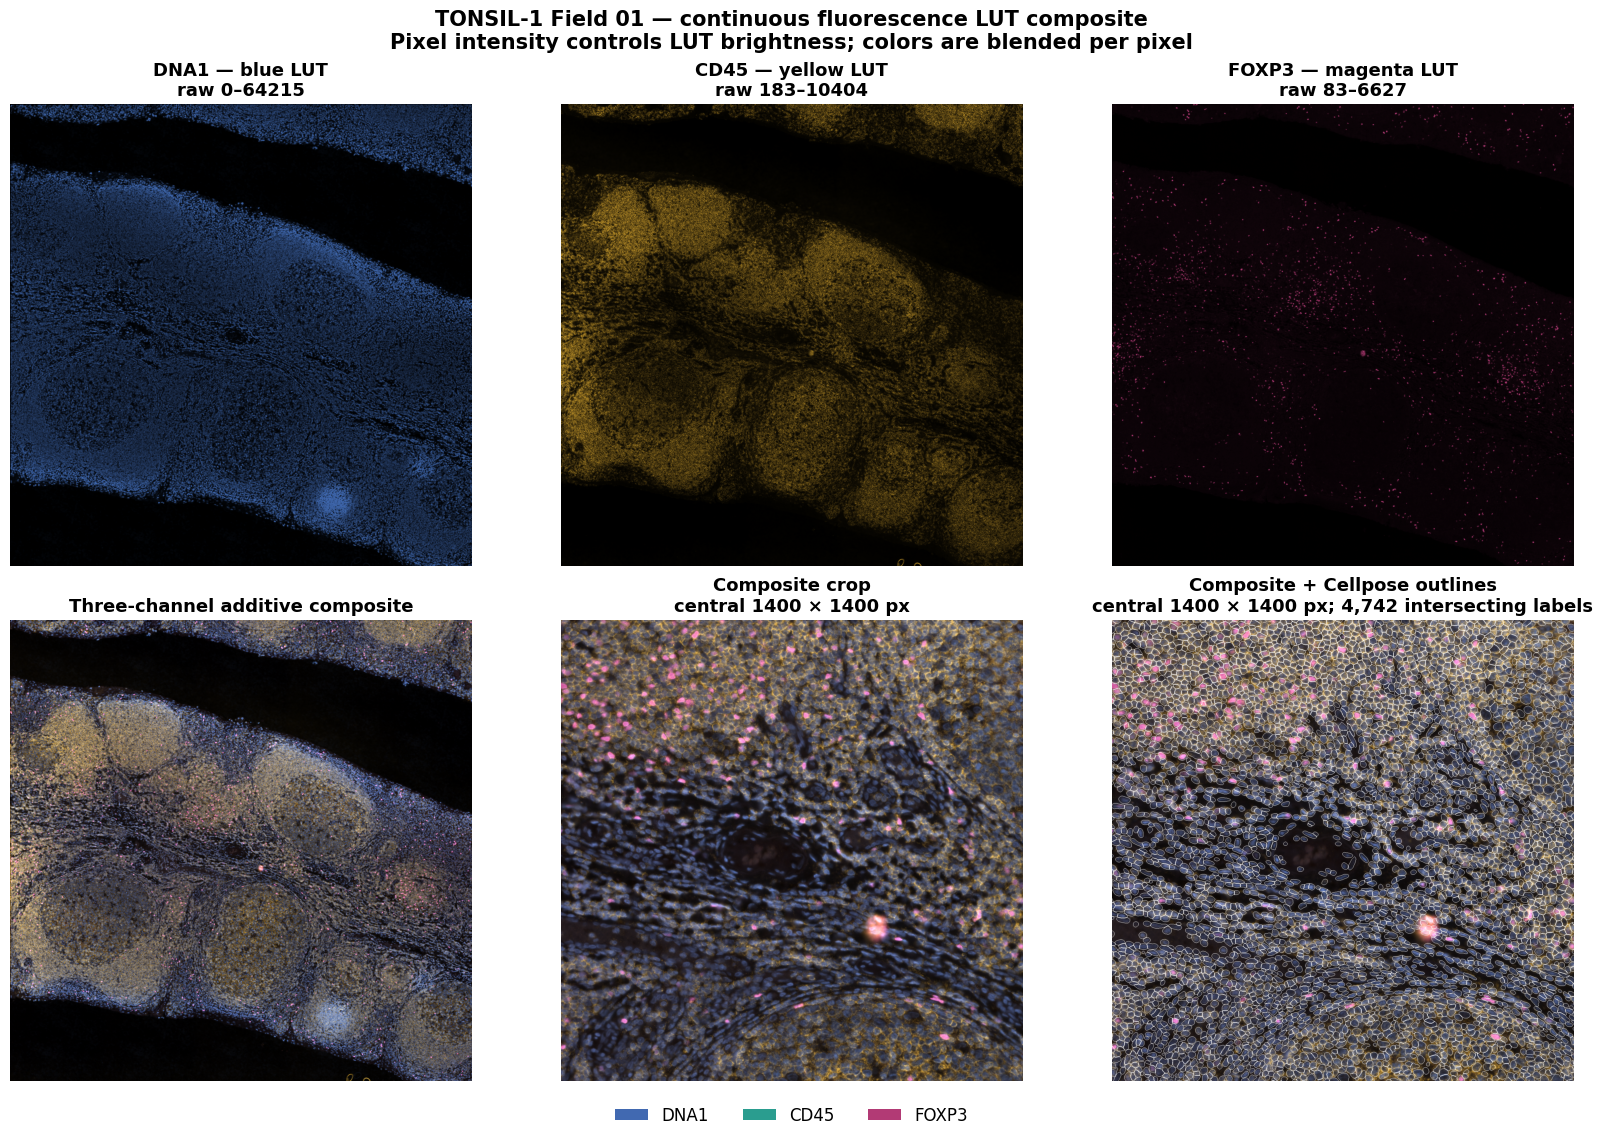


CELL 5 COMPLETED SUCCESSFULLY
Display is pixel-level LUT coloring, not mask-region coloring.
Full composite contains no segmentation boundaries.
Elapsed time : 0.42 min
Composite TIF: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell5_LUT_composite_full_resolution.tif
Composite PNG: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell5_LUT_composite_full_resolution.png
QC PNG       : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell5_LUT_composite_QC.png
QC PDF       : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell5_LUT_composite_QC.pdf
Manifest     : /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell5_LUT_composite_manifest.json

Send the QC image here before changing the LUT limits or gamma.


In [ ]:
# ============================================================
# CELL 5 — Microscopy LUT composite (pixel-level pseudocolor)
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import gc
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from PIL import Image
from matplotlib.patches import Patch
from skimage.segmentation import find_boundaries


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ROOT = Path(
    "/content/drive/MyDrive/CyCIF_validation/"
    "TONSIL-1_40X_Field_01_01"
)
RUN_DIR = ROOT / "cellpose_vs_published_v1"
RUN_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_PATH = ROOT / "TONSIL-1_40X_Field_01_01.tif"
MARKERS_PATH = ROOT / "markers.csv"
MASK_PATH = (
    RUN_DIR /
    "TONSIL-1_40X_Field_01_01_cpsam_v2_DNA1_masks.npy"
)

COMPOSITE_TIF = RUN_DIR / "cell5_LUT_composite_full_resolution.tif"
COMPOSITE_PNG = RUN_DIR / "cell5_LUT_composite_full_resolution.png"
QC_PNG = RUN_DIR / "cell5_LUT_composite_QC.png"
QC_PDF = RUN_DIR / "cell5_LUT_composite_QC.pdf"
MANIFEST_PATH = RUN_DIR / "cell5_LUT_composite_manifest.json"

for required in [IMAGE_PATH, MARKERS_PATH]:
    if not required.exists():
        raise FileNotFoundError(required)


# ------------------------------------------------------------
# Display configuration
#
# These are continuous per-pixel LUTs, not categorical mask colors.
# Edit this list to display other markers. Keep 3–5 channels in one
# composite so that biological structures remain interpretable.
# RGB values must be between 0 and 1.
# ------------------------------------------------------------
LUT_CHANNELS = [
    {
        "marker": "DNA1",
        "color": (0.25, 0.41, 0.69),
        "color_name": "blue",
        "hex": "#4169B1",
    },
    {
        "marker": "CD45",
        "color": (0.78, 0.60, 0.17),
        "color_name": "yellow",
        "hex": "#2A9D8F",
    },
    {
        "marker": "FOXP3",
        "color": (0.70, 0.23, 0.46),
        "color_name": "magenta",
        "hex": "#B23A75",
    },
]

# Display transform only. It does not change Cell 2 or Cell 4 values.
LOW_PERCENTILE = 5.0
HIGH_PERCENTILE = 99.8
DISPLAY_GAMMA = 0.95       # >1 suppresses dim background/noise for display
PERCENTILE_SAMPLE_STEP = 4

# Fiji/ImageJ-style clipped-additive microscopy composite.
# Each LUT contribution is summed and the final RGB result is clipped to 1.
BLEND_MODE = "clipped_additive"
if BLEND_MODE != "clipped_additive":
    raise ValueError(
        "This cell currently implements BLEND_MODE='clipped_additive' only."
    )

# White Cellpose boundaries are shown only in the QC crop.
# They are not burned into the saved full-resolution composite.
SHOW_CELLPOSE_BOUNDARIES_IN_QC = True
QC_CROP_SIZE = 1400


# ------------------------------------------------------------
# Marker mapping and TIFF validation
# ------------------------------------------------------------
markers = pd.read_csv(MARKERS_PATH)
required_marker_columns = {"channel_number", "marker_name"}
if not required_marker_columns.issubset(markers.columns):
    raise ValueError(
        f"markers.csv must contain {sorted(required_marker_columns)}; "
        f"found {markers.columns.tolist()}"
    )

markers = markers.copy()
markers["channel_number"] = pd.to_numeric(
    markers["channel_number"], errors="raise"
).astype(int)
markers["marker_name"] = markers["marker_name"].astype(str).str.strip()

if len(markers) != 44:
    raise ValueError(f"Expected 44 marker rows; found {len(markers)}")
if markers["marker_name"].duplicated().any():
    raise ValueError("Marker names are not unique.")
if markers["channel_number"].tolist() != list(range(1, 45)):
    raise ValueError("channel_number must be the ordered sequence 1...44.")

marker_to_page = {
    row.marker_name: int(row.channel_number) - 1
    for row in markers.itertuples(index=False)
}

requested_markers = [entry["marker"] for entry in LUT_CHANNELS]
if len(requested_markers) != len(set(requested_markers)):
    raise ValueError("LUT_CHANNELS contains a duplicated marker.")

missing_markers = [m for m in requested_markers if m not in marker_to_page]
if missing_markers:
    raise ValueError(
        f"Requested markers are absent from markers.csv: {missing_markers}"
    )

for entry in LUT_CHANNELS:
    color = np.asarray(entry["color"], dtype=np.float32)
    if color.shape != (3,) or np.any(color < 0) or np.any(color > 1):
        raise ValueError(
            f"Invalid RGB color for {entry['marker']}: {entry['color']}"
        )

with tifffile.TiffFile(IMAGE_PATH) as tif:
    image_shape = tuple(tif.series[0].shape)
    image_axes = str(tif.series[0].axes)
    image_dtype = str(tif.series[0].dtype)
    page_count = len(tif.pages)

if image_axes != "CYX" or image_shape[0] != 44 or page_count != 44:
    raise ValueError(
        "Expected a 44-channel CYX TIFF with 44 pages; got "
        f"shape={image_shape}, axes={image_axes}, pages={page_count}"
    )

height, width = image_shape[1:]

print("=" * 78)
print("CELL 5 — MICROSCOPY LUT COMPOSITE")
print("=" * 78)
print("Source TIFF  :", IMAGE_PATH)
print("TIFF shape   :", image_shape)
print("TIFF axes    :", image_axes)
print("TIFF dtype   :", image_dtype)
print("Blend mode   :", BLEND_MODE)
print("Gamma        :", DISPLAY_GAMMA)
print("LUT channels :")
for entry in LUT_CHANNELS:
    print(
        f"  page {marker_to_page[entry['marker']] + 1:02d}  "
        f"{entry['marker']:<10} -> {entry['color_name']} ({entry['hex']})"
    )


# ------------------------------------------------------------
# Build a full-resolution composite without retaining four raw
# 6000 x 6000 channels simultaneously.
# ------------------------------------------------------------
start = time.time()
composite_accumulator = np.zeros((height, width, 3), dtype=np.float32)
channel_qc_images = {}
display_records = []

overview_step = max(1, int(np.ceil(max(height, width) / 1600)))

with tifffile.TiffFile(IMAGE_PATH) as tif:
    for entry in LUT_CHANNELS:
        marker = entry["marker"]
        page_index = marker_to_page[marker]
        color = np.asarray(entry["color"], dtype=np.float32)

        raw = tif.pages[page_index].asarray()
        if raw.shape != (height, width):
            raise ValueError(
                f"Page {page_index + 1} ({marker}) has shape {raw.shape}; "
                f"expected {(height, width)}"
            )

        percentile_sample = raw[
            ::PERCENTILE_SAMPLE_STEP,
            ::PERCENTILE_SAMPLE_STEP,
        ].reshape(-1)
        low, high = np.percentile(
            percentile_sample, [LOW_PERCENTILE, HIGH_PERCENTILE]
        )
        low = float(low)
        high = float(high)

        if not np.isfinite(low) or not np.isfinite(high) or high <= low:
            raise ValueError(
                f"Invalid display limits for {marker}: {low}, {high}"
            )

        normalized = raw.astype(np.float32)
        normalized -= low
        normalized /= high - low
        np.clip(normalized, 0.0, 1.0, out=normalized)
        np.power(normalized, DISPLAY_GAMMA, out=normalized)

        # Continuous LUT contribution and clipped-additive blending.
        for rgb_index in range(3):
            if color[rgb_index] > 0:
                composite_accumulator[..., rgb_index] += (
                    normalized * color[rgb_index]
                )

        small = normalized[::overview_step, ::overview_step]
        channel_qc_images[marker] = np.clip(
            small[..., None] * color[None, None, :] * 255.0,
            0,
            255,
        ).astype(np.uint8)

        display_records.append({
            "marker": marker,
            "channel_number_1based": page_index + 1,
            "color_name": entry["color_name"],
            "hex": entry["hex"],
            "rgb_0_to_1": [float(value) for value in color],
            "raw_low": low,
            "raw_high": high,
            "low_percentile": LOW_PERCENTILE,
            "high_percentile": HIGH_PERCENTILE,
            "gamma": DISPLAY_GAMMA,
        })

        print(
            f"Rendered {marker:<10}  raw LUT limits "
            f"{low:.1f} to {high:.1f}"
        )

        del raw, percentile_sample, normalized, small
        gc.collect()

np.clip(composite_accumulator, 0.0, 1.0, out=composite_accumulator)
np.multiply(composite_accumulator, 255.0, out=composite_accumulator)
composite = composite_accumulator.astype(np.uint8)
del composite_accumulator
gc.collect()

if composite.shape != (height, width, 3):
    raise ValueError(f"Unexpected composite shape: {composite.shape}")


# ------------------------------------------------------------
# Save the true full-resolution pixel-level composite.
# The TIFF and PNG contain no segmentation fill or outline.
# ------------------------------------------------------------
tifffile.imwrite(
    COMPOSITE_TIF,
    composite,
    photometric="rgb",
    planarconfig="contig",
    # Uncompressed uint8 RGB is broadly readable and avoids optional
    # TIFF compression-codec dependencies. The expected size is ~108 MB.
    compression=None,
    metadata={"axes": "YXS"},
)

Image.fromarray(composite).save(
    COMPOSITE_PNG,
    format="PNG",
    compress_level=4,
)

print("\nFull-resolution composite TIFF:", COMPOSITE_TIF)
print("Full-resolution composite PNG :", COMPOSITE_PNG)


# ------------------------------------------------------------
# Publication-style QC figure:
# three individual LUT channels, full composite, and two native-
# resolution central crops (without and with optional white outlines).
# ------------------------------------------------------------
composite_overview = composite[::overview_step, ::overview_step]

crop_size = min(QC_CROP_SIZE, height, width)
y0 = max(0, height // 2 - crop_size // 2)
x0 = max(0, width // 2 - crop_size // 2)
y1 = y0 + crop_size
x1 = x0 + crop_size

composite_crop_plain = composite[y0:y1, x0:x1].copy()
composite_crop_outlined = composite_crop_plain.copy()
boundary_count = None

if SHOW_CELLPOSE_BOUNDARIES_IN_QC and MASK_PATH.exists():
    mask = np.load(MASK_PATH, mmap_mode="r")
    if mask.shape != (height, width):
        raise ValueError(
            f"Cellpose mask has shape {mask.shape}; expected {(height, width)}"
        )
    mask_crop = np.asarray(mask[y0:y1, x0:x1])
    boundaries = find_boundaries(mask_crop, mode="outer")
    composite_crop_outlined[boundaries] = (255, 255, 255)
    boundary_count = int(np.unique(mask_crop[mask_crop > 0]).size)
    del mask, mask_crop, boundaries
    outlined_crop_title = (
        f"Composite + Cellpose outlines\n"
        f"central {crop_size} × {crop_size} px; "
        f"{boundary_count:,} intersecting labels"
    )
else:
    outlined_crop_title = (
        f"Composite crop — outlines unavailable\n"
        f"central {crop_size} × {crop_size} px"
    )

plain_crop_title = f"Composite crop\ncentral {crop_size} × {crop_size} px"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

fig, axes = plt.subplots(2, 3, figsize=(16.5, 10.8), constrained_layout=True)

for ax, entry in zip(axes[0, :], LUT_CHANNELS):
    marker = entry["marker"]
    record = next(row for row in display_records if row["marker"] == marker)
    ax.imshow(channel_qc_images[marker])
    ax.set_title(
        f"{marker} — {entry['color_name']} LUT\n"
        f"raw {record['raw_low']:.0f}–{record['raw_high']:.0f}",
        fontweight="bold",
    )
    ax.axis("off")

axes[1, 0].imshow(composite_overview)
axes[1, 0].set_title("Three-channel additive composite", fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(composite_crop_plain)
axes[1, 1].set_title(plain_crop_title, fontweight="bold")
axes[1, 1].axis("off")

axes[1, 2].imshow(composite_crop_outlined)
axes[1, 2].set_title(outlined_crop_title, fontweight="bold")
axes[1, 2].axis("off")

legend_handles = [
    Patch(facecolor=entry["hex"], edgecolor="none", label=entry["marker"])
    for entry in LUT_CHANNELS
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle(
    "TONSIL-1 Field 01 — continuous fluorescence LUT composite\n"
    "Pixel intensity controls LUT brightness; colors are blended per pixel",
    fontsize=15,
    fontweight="bold",
)

fig.savefig(QC_PNG, dpi=240, bbox_inches="tight")
fig.savefig(QC_PDF, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Reproducibility manifest
# ------------------------------------------------------------
manifest = {
    "stage": "CELL 5 — microscopy LUT composite",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_tiff": str(IMAGE_PATH),
    "source_shape": list(image_shape),
    "source_axes": image_axes,
    "source_dtype": image_dtype,
    "display_only": True,
    "quantitative_values_modified": False,
    "lut_definition": (
        "Each grayscale pixel is normalized, gamma-adjusted, multiplied "
        "by its channel RGB color, summed, and clipped to the RGB range."
    ),
    "normalization": {
        "method": "per-channel percentile normalization",
        "low_percentile": LOW_PERCENTILE,
        "high_percentile": HIGH_PERCENTILE,
        "percentile_sample_step": PERCENTILE_SAMPLE_STEP,
        "gamma": DISPLAY_GAMMA,
    },
    "blend_mode": BLEND_MODE,
    "channels": display_records,
    "full_resolution_composite_contains_boundaries": False,
    "qc_boundary_overlay": {
        "requested": SHOW_CELLPOSE_BOUNDARIES_IN_QC,
        "mask_found": MASK_PATH.exists(),
        "color": "white",
        "crop_xyxy": [x0, y0, x1, y1],
        "intersecting_cellpose_labels": boundary_count,
    },
    "outputs": {
        "full_resolution_tiff": str(COMPOSITE_TIF),
        "full_resolution_png": str(COMPOSITE_PNG),
        "qc_png": str(QC_PNG),
        "qc_pdf": str(QC_PDF),
    },
}

with open(MANIFEST_PATH, "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)

elapsed_minutes = (time.time() - start) / 60.0

print("\n" + "=" * 78)
print("CELL 5 COMPLETED SUCCESSFULLY")
print("=" * 78)
print("Display is pixel-level LUT coloring, not mask-region coloring.")
print("Full composite contains no segmentation boundaries.")
print("Elapsed time :", f"{elapsed_minutes:.2f} min")
print("Composite TIF:", COMPOSITE_TIF)
print("Composite PNG:", COMPOSITE_PNG)
print("QC PNG       :", QC_PNG)
print("QC PDF       :", QC_PDF)
print("Manifest     :", MANIFEST_PATH)
print("\nSend the QC image here before changing the LUT limits or gamma.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CELL 4 - VERIFY CELL 3
  Published scale : natural_log (base 2.71828)
  High-confidence pairs : 17,626
  Border cells excluded : 12
  Primary pairs         : 17,614
  Included marker channels : 27
  Excluded BG/DNA channels : 488_BG_1, 555_BG_1, 647_BG_1, DNA2, 488_BG_2, 555_BG_2, 647_BG_2, DNA3, 488_BG_3, DNA4, DNA5, DNA6, DNA7, DNA8, DNA9, DNA10, DNA11

PER-MARKER CONCORDANCE AND CALL AGREEMENT
[01/44] DNA1         rho=0.9628  over= 2.82%  under= 3.36%  kappa=0.861
[11/44] LAG3         rho=0.9617  over= 1.53%  under= 4.82%  kappa=0.837
[12/44] ARL13B       rho=0.9808  over= 1.67%  under= 3.63%  kappa=0.891
[14/44] KI67         rho=0.9886  over= 0.93%  under= 0.46%  kappa=0.958
[15/44] KERATIN      rho=0.9923  over= 0.41%  under= 0.06%  kappa=0.983
[16/44] PD-1         rho=0.9799  over= 2.94%  under= 0.52%  kappa=0.881
[18/44] CD45RB       rho=0.9774  over= 

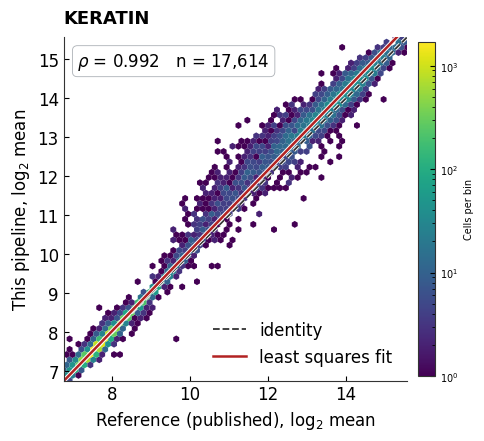

  g01_scatter_CD45  [svg, tiff 600dpi, png 600dpi, pdf]


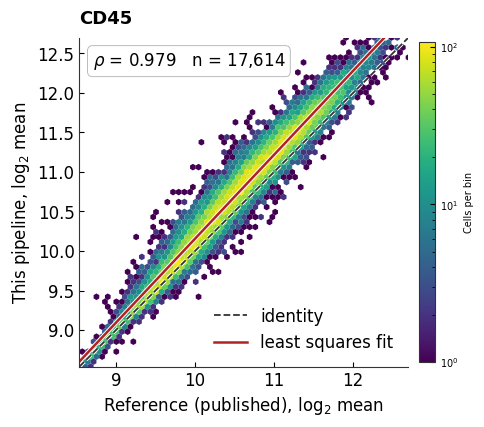

  g02_overcall_undercall  [svg, tiff 600dpi, png 600dpi, pdf]


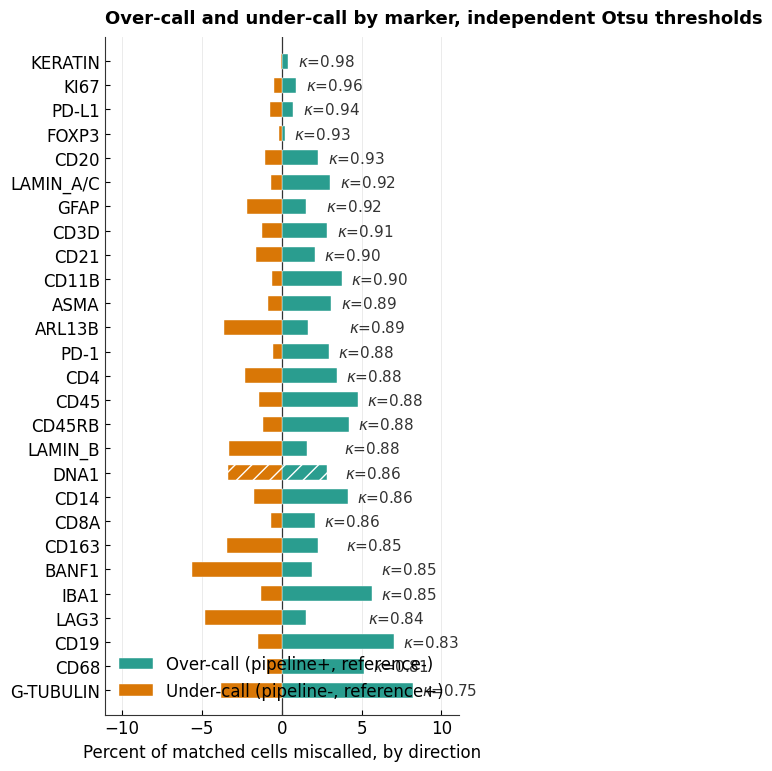


  CELL 4 COMPLETE  |  2 figures, 12 files  |  0.2 min
  Figures: /content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01/cellpose_vs_published_v1/cell4_figures_single_panel


In [ ]:
# ============================================================
# CELL 4 - Cellpose vs published fluorescence concordance
# Two figures, not five. The question that matters is the one your HER2
# validation asked: does the pipeline call the same cells positive, and
# when it disagrees, which direction is the error in? Continuous-value
# agreement (rho, CCC, Bland-Altman) is supporting evidence, not the
# headline, so it stays as numbers in the CSV rather than four separate
# figures repeating the same signed error.
#
# Style matches the house style already established in the HER2-IHC-40x
# scripts: DejaVu Sans, open top/right spines, bold left-aligned titles,
# 7 pt colorbars, the same named colour palette. Figures saved as
# SVG + TIFF 600 dpi + PNG + PDF, one file per figure.
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import json
import re
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import spearmanr
from skimage.filters import threshold_otsu
from sklearn.metrics import cohen_kappa_score

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
ROOT = Path("/content/drive/MyDrive/CyCIF_validation/TONSIL-1_40X_Field_01_01")
RUN_DIR = ROOT / "cellpose_vs_published_v1"
FIGDIR = RUN_DIR / "cell4_figures_single_panel"
FIGDIR.mkdir(parents=True, exist_ok=True)

PUBLISHED_CSV = ROOT / "TONSIL-1_40X_Field_01_01.csv"
CELLPOSE_FEATURES = RUN_DIR / "TONSIL-1_40X_Field_01_01_cellpose_44ch_raw_features.csv"
CELL3_MATCHES = RUN_DIR / "cell3_spatial_matches.csv"
CELL3_SCALE_CHANNELS = RUN_DIR / "cell3_scale_diagnostics_by_channel.csv"
CELL3_SCALE_CANDIDATES = RUN_DIR / "cell3_scale_candidate_summary.csv"
CELL3_MANIFEST = RUN_DIR / "cell3_matching_scale_manifest.json"

PAIRED_OUT = RUN_DIR / "cell4_matched_fluorescence_pairs.csv"
METRICS_OUT = RUN_DIR / "cell4_marker_concordance_metrics.csv"
CALLS_OUT = RUN_DIR / "cell4_overcall_undercall_by_marker.csv"
MANIFEST_OUT = RUN_DIR / "cell4_fluorescence_concordance_manifest.json"

for required in (PUBLISHED_CSV, CELLPOSE_FEATURES, CELL3_MATCHES,
                 CELL3_SCALE_CHANNELS, CELL3_SCALE_CANDIDATES, CELL3_MANIFEST):
    if not required.exists():
        raise FileNotFoundError(
            f"Missing required input: {required}\nRun Cell 3 first.")

# ------------------------------------------------------------
# House style, matching the HER2-IHC-40x scripts exactly.
# ------------------------------------------------------------
SCATTER_CMAP = "viridis"

BLUE = "#34699A"
ORANGE = "#D97706"
BRICK_RED = "#B22222"
TEAL = "#2A9D8F"
GREY = "#9AA0A6"
GRID_GREY = "#DDDDDD"
IDENTITY_COLOR = "#333333"
FIT_LINE_COLOR = BRICK_RED

DPI = 600
FS_TICK, FS_LABEL, FS_TITLE, FS_ANNOT, FS_LEGEND = 12, 12, 13, 12, 12
FS_COLORBAR = 7

matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": FS_LABEL,
    "axes.titlesize": FS_TITLE,
    "axes.titleweight": "bold",
    "axes.labelsize": FS_LABEL,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#333333",
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "legend.frameon": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "svg.fonttype": "none",
})

_WRITTEN = []


def finish(fig, stem, show=True):
    stem = re.sub(r"[^A-Za-z0-9_-]+", "_", stem)
    for fmt, kw in (("svg", {}), ("pdf", {}),
                    ("tiff", dict(dpi=DPI, pil_kwargs={"compression": "tiff_lzw"})),
                    ("png", dict(dpi=DPI))):
        path = FIGDIR / f"{stem}.{fmt}"
        fig.savefig(path, format=fmt, **kw)
        _WRITTEN.append(path)
    print(f"  {stem}  [svg, tiff 600dpi, png 600dpi, pdf]")
    if show:
        plt.show()
    plt.close(fig)


def rank_height(n_rows, per_row=0.24, base=1.4):
    return base + per_row * n_rows


def lin_ccc(x, y):
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.mean((x - mx) ** 2), np.mean((y - my) ** 2)
    cov = np.mean((x - mx) * (y - my))
    denom = vx + vy + (mx - my) ** 2
    return float(2 * cov / denom) if denom else np.nan


def safe_marker_name(channel_number, marker):
    safe = re.sub(r"[^A-Za-z0-9]+", "_", str(marker)).strip("_")
    return f"C{int(channel_number):02d}_{safe}"


start = time.time()

# ------------------------------------------------------------
# Gate on Cell 3's resolved scale
# ------------------------------------------------------------
print("=" * 72)
print("CELL 4 - VERIFY CELL 3")
print("=" * 72)

with open(CELL3_MANIFEST, "r", encoding="utf-8") as fh:
    cell3_manifest = json.load(fh)

selected_scale = str(cell3_manifest.get("selected_published_scale", "UNDETERMINED"))
if not cell3_manifest.get("scale_resolved", False) or selected_scale == "UNDETERMINED":
    raise RuntimeError(
        "Cell 3 did not resolve the published log scale. Fix that before "
        "computing concordance figures.")

scale_candidates = pd.read_csv(CELL3_SCALE_CANDIDATES)
row0 = scale_candidates.loc[scale_candidates["CandidateScale"] == selected_scale].iloc[0]
published_log_base = float(row0["Base"])
to_log2 = float(np.log2(published_log_base))
print(f"  Published scale : {selected_scale} (base {published_log_base:.5f})")

# ------------------------------------------------------------
# Primary matched pairs: high confidence, border cells excluded
# ------------------------------------------------------------
matches = pd.read_csv(CELL3_MATCHES, low_memory=False)


def as_bool(s):
    if pd.api.types.is_bool_dtype(s):
        return s.astype(bool)
    return s.astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


matches["HighConfidence"] = as_bool(matches["HighConfidence"])
matches["CellposeTouchesBorder"] = as_bool(matches["CellposeTouchesBorder"])
high_conf = matches.loc[matches["HighConfidence"]]
primary = high_conf.loc[~high_conf["CellposeTouchesBorder"]].reset_index(drop=True)

if len(primary) < 1000:
    raise RuntimeError(f"Only {len(primary):,} primary pairs. Review Cell 3.")

print(f"  High-confidence pairs : {len(high_conf):,}")
print(f"  Border cells excluded : {int(high_conf['CellposeTouchesBorder'].sum()):,}")
print(f"  Primary pairs         : {len(primary):,}")

# ------------------------------------------------------------
# Load only the needed intensity columns
# ------------------------------------------------------------
scale_map = pd.read_csv(CELL3_SCALE_CHANNELS).sort_values("ChannelNumber_1based")
scale_map = scale_map.reset_index(drop=True)

# Keep DNA1 plus all biological/immune-marker channels.
# Exclude every background channel and DNA2-DNA11 from all downstream
# metrics, summaries, CSV outputs, and over-call/under-call figures.
marker_upper = scale_map["Marker"].astype(str).str.strip().str.upper()
keep_marker = (
    marker_upper.eq("DNA1")
    | (
        ~marker_upper.str.startswith("DNA")
        & ~marker_upper.str.contains("_BG_", regex=False)
    )
)
excluded_markers = scale_map.loc[~keep_marker, "Marker"].astype(str).tolist()
scale_map = scale_map.loc[keep_marker].reset_index(drop=True)

print(f"  Included marker channels : {len(scale_map)}")
print(f"  Excluded BG/DNA channels : {', '.join(excluded_markers)}")

cp_cols = scale_map["CellposeFeatureColumn"].astype(str).tolist()
pub_cols = scale_map["PublishedFeatureColumn"].astype(str).tolist()

cellpose = pd.read_csv(CELLPOSE_FEATURES, usecols=["CellposeID"] + cp_cols)
published = pd.read_csv(PUBLISHED_CSV, usecols=["CellId"] + pub_cols)
cellpose = cellpose.set_index("CellposeID")
published = published.set_index("CellId")

cp_ids = primary["CellposeID"].to_numpy(np.int64)
pub_ids = primary["PublishedCellId"].to_numpy(np.int64)
cp_rows = cellpose.loc[cp_ids]
pub_rows = published.loc[pub_ids]

# ==============================================================
# PER-MARKER METRICS
# Continuous agreement (rho, CCC, bias) is kept in the CSV for anyone
# who wants it, but only rho appears on a figure, as an annotation on
# the scatter. It is not built out into its own set of plots.
# ==============================================================
paired_data = {"CellposeID": cp_ids, "PublishedCellId": pub_ids}
metric_rows = []
call_rows = []

print("\n" + "=" * 72)
print("PER-MARKER CONCORDANCE AND CALL AGREEMENT")
print("=" * 72)

for _, m in scale_map.iterrows():
    ch, marker = int(m["ChannelNumber_1based"]), str(m["Marker"])
    prefix = safe_marker_name(ch, marker)
    cp_raw = pd.to_numeric(cp_rows[m["CellposeFeatureColumn"]], errors="coerce").to_numpy(float)
    pub_native = pd.to_numeric(pub_rows[m["PublishedFeatureColumn"]], errors="coerce").to_numpy(float)
    with np.errstate(divide="ignore", invalid="ignore"):
        cp_log2 = np.log2(cp_raw)
        pub_log2 = pub_native * to_log2
    paired_data[f"ref_{prefix}"] = pub_log2
    paired_data[f"pipe_{prefix}"] = cp_log2

    ok = np.isfinite(cp_log2) & np.isfinite(pub_log2)
    x, y = pub_log2[ok], cp_log2[ok]
    is_control = marker.upper().startswith("DNA") or "_BG_" in marker.upper()

    if len(x) < 100 or np.std(x) == 0:
        continue

    # Continuous agreement, recorded but not separately plotted.
    rho = float(spearmanr(x, y).statistic)
    ccc = lin_ccc(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    bias = float(np.mean(y - x))
    metric_rows.append(dict(
        channel=ch, marker=marker, biological=not is_control, prefix=prefix,
        n=int(len(x)), spearman_rho=rho, lin_ccc=ccc,
        ols_slope=float(slope), ols_intercept=float(intercept), bias_log2=bias,
    ))

    # Over-call / under-call, the analogue of the HER2 grade confusion
    # analysis: threshold each method independently on its own
    # distribution (exactly as Step 6 does in practice), then ask which
    # direction any disagreement runs in.
    t_ref = threshold_otsu(x)
    t_pipe = threshold_otsu(y)
    pos_ref = x > t_ref
    pos_pipe = y > t_pipe

    over_call = 100 * np.mean(pos_pipe & ~pos_ref)     # pipeline+, reference-
    under_call = 100 * np.mean(~pos_pipe & pos_ref)    # pipeline-, reference+
    agree = 100 * np.mean(pos_pipe == pos_ref)
    kappa = float(cohen_kappa_score(pos_ref, pos_pipe))

    call_rows.append(dict(
        channel=ch, marker=marker, biological=not is_control, n=int(len(x)),
        threshold_reference_log2=float(t_ref), threshold_pipeline_log2=float(t_pipe),
        pct_positive_reference=float(100 * pos_ref.mean()),
        pct_positive_pipeline=float(100 * pos_pipe.mean()),
        pct_over_call=float(over_call), pct_under_call=float(under_call),
        pct_agree=float(agree), cohen_kappa=kappa,
    ))

    print(f"[{ch:02d}/44] {marker:<12} rho={rho:.4f}  over={over_call:5.2f}%  "
          f"under={under_call:5.2f}%  kappa={kappa:.3f}")

paired = pd.DataFrame(paired_data)
metrics = pd.DataFrame(metric_rows)
calls = pd.DataFrame(call_rows)
paired.to_csv(PAIRED_OUT, index=False)
metrics.to_csv(METRICS_OUT, index=False)
calls.to_csv(CALLS_OUT, index=False)

biological = calls[calls["biological"] & (calls["n"] >= 100)]
print(f"\n  Median over-call  : {biological['pct_over_call'].median():.2f}%")
print(f"  Median under-call : {biological['pct_under_call'].median():.2f}%")
print(f"  Median kappa      : {biological['cohen_kappa'].median():.3f}")
print(f"  Median rho        : {metrics.loc[metrics['biological'], 'spearman_rho'].median():.4f}")

# ==============================================================
# FIGURE 1 - scatter, sanity check only, two markers
# ==============================================================
SCATTER_MARKERS = ["KERATIN", "CD45"]


def get_pair(marker):
    row = metrics.loc[metrics["marker"] == marker].iloc[0]
    x = paired[f"ref_{row['prefix']}"].to_numpy(float)
    y = paired[f"pipe_{row['prefix']}"].to_numpy(float)
    ok = np.isfinite(x) & np.isfinite(y)
    return x[ok], y[ok], row


print("\nWRITING FIGURES")

for marker in SCATTER_MARKERS:
    x, y, row = get_pair(marker)
    lo = float(min(np.percentile(x, 0.2), np.percentile(y, 0.2)))
    hi = float(max(np.percentile(x, 99.8), np.percentile(y, 99.8)))

    fig, ax = plt.subplots(figsize=(5.0, 4.9))
    hb = ax.hexbin(x, y, gridsize=58, cmap=SCATTER_CMAP, bins="log",
                   linewidths=0, mincnt=1, extent=(lo, hi, lo, hi))
    ax.plot([lo, hi], [lo, hi], color=IDENTITY_COLOR, linestyle="--", linewidth=1.3,
            label="identity",
            path_effects=[pe.withStroke(linewidth=2.6, foreground="white")])
    ax.plot([lo, hi], np.polyval([row["ols_slope"], row["ols_intercept"]], [lo, hi]),
            color=FIT_LINE_COLOR, linewidth=1.8, label="least squares fit",
            path_effects=[pe.withStroke(linewidth=3.2, foreground="white")])
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel("Reference (published), log$_2$ mean")
    ax.set_ylabel("This pipeline, log$_2$ mean")
    ax.set_title(marker, loc="left", pad=10)
    ax.annotate(f"$\\rho$ = {row['spearman_rho']:.3f}   n = {int(row['n']):,}",
                xy=(0.04, 0.96), xycoords="axes fraction", fontsize=FS_ANNOT, va="top",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.82,
                         edgecolor=GREY, linewidth=0.6))
    ax.legend(loc="lower right")
    cb = fig.colorbar(hb, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label("Cells per bin", fontsize=FS_COLORBAR)
    cb.ax.tick_params(labelsize=FS_COLORBAR)
    fig.tight_layout()
    finish(fig, f"g01_scatter_{marker}")

# ==============================================================
# FIGURE 2 - over-call / under-call, the headline figure
# Diverging bars: over-call to the right in teal, under-call to the left
# in orange, ranked by kappa so the best-agreeing markers sit at the top.
# This is the direct analogue of the HER2 grade over/under-call analysis.
# ==============================================================
order = calls.sort_values("cohen_kappa", ascending=True).reset_index(drop=True)
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(5, rank_height(len(order), per_row=0.24)))
ax.axvline(0, color=IDENTITY_COLOR, linewidth=0.9)
ax.grid(axis="x", color=GRID_GREY, linewidth=0.6, alpha=0.7, zorder=0)

is_bio = order["biological"].to_numpy()
bars_over = ax.barh(y, order["pct_over_call"], color=TEAL, edgecolor="white",
                    linewidth=0.3, height=0.62,
                    label="Over-call (pipeline+, reference-)", zorder=2)
bars_under = ax.barh(y, -order["pct_under_call"], color=ORANGE, edgecolor="white",
                     linewidth=0.3, height=0.62,
                     label="Under-call (pipeline-, reference+)", zorder=2)

# Control channels get a hatch so they are distinguishable without a
# second colour, since colour here already carries call direction.
for i in np.flatnonzero(~is_bio):
    bars_over[i].set_hatch("//")
    bars_under[i].set_hatch("//")

for i, row in order.iterrows():
    edge = max(row["pct_over_call"], row["pct_under_call"])
    ax.annotate(f"$\\kappa$={row['cohen_kappa']:.2f}", xy=(edge + 0.6, i),
                fontsize=FS_ANNOT - 1, va="center", color=IDENTITY_COLOR)

ax.set_yticks(y)
ax.set_yticklabels(order["marker"], fontsize=FS_TICK)
ax.set_ylim(-1, len(order))
xmax = float(max(order["pct_over_call"].max(), order["pct_under_call"].max())) * 1.35
ax.set_xlim(-xmax, xmax)
ax.set_xlabel("Percent of matched cells miscalled, by direction")
ax.set_title("Over-call and under-call by marker, independent Otsu thresholds",
            loc="left", pad=10)
ax.legend(loc="lower right")
fig.tight_layout()
finish(fig, "g02_overcall_undercall")

# ------------------------------------------------------------
# Manifest
# ------------------------------------------------------------
manifest = dict(
    stage="CELL 4 - fluorescence concordance, over-call/under-call framing",
    created_utc=datetime.now(timezone.utc).isoformat(),
    published_scale=selected_scale,
    published_log_base=published_log_base,
    primary_pair_count=int(len(primary)),
    figure_count=2,
    figure_formats=["svg", "tiff_600dpi", "png_600dpi", "pdf"],
    figure_style=dict(font_family="DejaVu Sans", spines="top/right removed",
                      scatter_cmap=SCATTER_CMAP,
                      palette="matches HER2-IHC-40x validation scripts"),
    design_note=(
        "Continuous agreement metrics (Spearman rho, Lin CCC, bias, slope) "
        "are computed and saved to METRICS_OUT for every marker but are not "
        "each given a separate figure. The headline figure is over-call / "
        "under-call under independent per-method thresholding, matching "
        "the HER2 grade-concordance framing rather than a "
        "continuous-measurement equivalence framing."
    ),
    biological_marker_summary=dict(
        n_markers=int(len(biological)),
        median_over_call_pct=float(biological["pct_over_call"].median()),
        median_under_call_pct=float(biological["pct_under_call"].median()),
        median_kappa=float(biological["cohen_kappa"].median()),
        median_spearman=float(metrics.loc[metrics["biological"], "spearman_rho"].median()),
    ),
    outputs=dict(paired=str(PAIRED_OUT), metrics=str(METRICS_OUT), calls=str(CALLS_OUT),
                figures_dir=str(FIGDIR), figure_files=len(_WRITTEN)),
)
with open(MANIFEST_OUT, "w") as fh:
    json.dump(manifest, fh, indent=2)

print(f"\n{'='*72}")
print(f"  CELL 4 COMPLETE  |  2 figures, {len(_WRITTEN)} files  |  {(time.time()-start)/60:.1f} min")
print(f"  Figures: {FIGDIR}")
print(f"{'='*72}")
